In [1]:
%load_ext autoreload
%autoreload 2
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers
import speed_plotting_helpers

import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

# Exploring speed fits
1. Exponential (here)
2. Hill
3. Time first active

## Loading in activities

In [2]:
active_tile_activities_count_filtered = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


## Trying exponential fit

In [3]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm

def rising_exponential(t, A, k, C):
    """Rising exponential: A*(1-exp(-k*t)) + C"""
    return A * (1 - np.exp(-k * t)) + C

def fit_rising_exponentials(df, time_col="time", activity_col="activity", error_col="error",
                            min_points=4, subtract_baseline=True, verbose=True):
    """
    Fit a rising exponential to each ADseq in the DataFrame and return fit metrics including R².
    """
    results = []
    grouped = df.groupby("ADseq")
    iterator = grouped.items() if not verbose else tqdm(grouped, desc="Fitting")
    
    for adseq, grp in iterator:
        grp = grp.sort_values(time_col)
        
        t = grp[time_col].values
        y = grp[activity_col].values
        sigma = grp[error_col].values if error_col in grp else None

        # subtract baseline if requested
        if subtract_baseline:
            baseline = y[0]
            y = y - baseline
            y = np.clip(y, 0, None)
        
        if len(t) < min_points:
            results.append({
                "ADseq": adseq,
                "A": np.nan, "k": np.nan, "C": np.nan,
                "t_half": np.nan, "t_half_obsmax": np.nan,
                "r_squared": np.nan,
                "flag": "too_few_points"
            })
            continue

        # initial guesses
        C0 = 0 if subtract_baseline else y[0]
        A0 = y[-1] - C0
        k0 = 1 / (t[-1] / 2 if t[-1] != 0 else 1)

        try:
            popt, pcov = curve_fit(
                rising_exponential, t, y,
                p0=[A0, k0, C0],
                sigma=sigma,
                absolute_sigma=True if sigma is not None else False,
                bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                maxfev=10000
            )
            perr = np.sqrt(np.diag(pcov))

            A, k, C = popt
            A_err, k_err, C_err = perr

            # half-life
            t_half = np.log(2) / k
            t_half_err = np.log(2) / (k ** 2) * k_err

            # --- model-interpolated half-life (50% of observed max) ---
            t_grid = np.linspace(t.min(), t.max(), 500)
            y_model = rising_exponential(t_grid, A, k, C)
            
            obs_max = np.max(y_model)  # <-- was np.max(y)
            threshold = 0.5 * obs_max
            
            idx = np.argmin(np.abs(y_model - threshold))
            t_half_model_empirical = t_grid[idx]
            
            # dense time grid for smooth inversion
            t_grid = np.linspace(t.min(), t.max(), 500)
            
            y_model = rising_exponential(t_grid, A, k, C)
            

            # compute R²
            y_fit = rising_exponential(t, A, k, C)
            ss_res = np.sum((y - y_fit) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

            results.append({
                "ADseq": adseq,
                "A": A, "A_err": A_err,
                "k": k, "k_err": k_err,
                "C": C, "C_err": C_err,
                "t_half": t_half,
                "t_half_err": t_half_err,
                "obs_max": obs_max,
                "t_half_model_empirical": t_half_model_empirical,
                "r_squared": r_squared,
                "flag": "ok"
            })

        except Exception as e:
            results.append({
                "ADseq": adseq,
                "A": np.nan, "k": np.nan, "C": np.nan,
                "t_half": np.nan, "t_half_obsmax": np.nan,
                "r_squared": np.nan,
                "flag": f"fit_error: {e}"
            })

    return pd.DataFrame(results)

In [4]:
fit_results = fit_rising_exponentials(
    active_tile_activities_count_filtered,
    time_col="time",
    activity_col="activity",
    error_col="error",
    min_points=5,
    subtract_baseline=False,
    verbose=True
)

print(fit_results['flag'].value_counts())

Fitting: 100%|██████████| 1709/1709 [00:14<00:00, 120.03it/s]

ok                1701
too_few_points       8
Name: flag, dtype: int64


In [5]:
fit_results

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,5.536385e-01,7.462021e-02,6.293211e-02,0.601177,0.059638,9.289001e+00,7.834024e+00,1.838727,3.486974,0.960851,ok,NaN
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,8.574766e-02,1.466103e-01,1.699489e-02,-0.066138,0.040876,4.727820e+00,5.480432e-01,2.102846,4.869739,0.985961,ok,NaN
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,1.236938e-01,1.594599e-01,1.938072e-02,-0.286056,0.118027,4.346844e+00,5.283144e-01,1.690053,5.230461,0.995732,ok,NaN
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,1.864414e-01,1.555655e-01,2.408857e-02,1.109990,0.154746,4.455660e+00,6.899374e-01,3.607231,2.044088,0.998874,ok,NaN
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,55047.252939,5.640412e-12,5.331843e-07,4.206800e-07,-0.145534,0.294459,1.300014e+06,1.025705e+06,0.734969,17.494990,0.985431,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,1.915160,2.745834e-01,5.927488e-02,2.057200e-02,0.253506,0.140851,1.169378e+01,4.058454e+00,1.845130,7.274549,0.966389,ok,NaN
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,2.829459,2.094465e+00,2.324079e-02,2.440913e-02,-0.325088,0.121292,2.982459e+01,3.132391e+01,1.095397,15.871743,0.858346,ok,NaN
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,4.156516,2.513513e-01,1.855459e-01,2.800798e-02,1.007863,0.206244,3.735719e+00,5.639035e-01,5.148483,2.525050,0.986325,ok,NaN
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,2.711766,1.296278e-01,1.607654e-01,1.578710e-02,0.344089,0.101114,4.311544e+00,4.233918e-01,3.034044,3.547094,0.984259,ok,NaN


## Filtering to reasonable fits and plotting

In [6]:
fit_results["A+C"] = fit_results["A"] + fit_results["C"]
fit_results["A*k"] = fit_results["A"] * fit_results["k"]
fit_results["1/k"] = 1 / fit_results["k"]
fit_results

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,5.536385e-01,7.462021e-02,6.293211e-02,0.601177,0.059638,9.289001e+00,7.834024e+00,1.838727,3.486974,0.960851,ok,NaN,1.986402,0.103366,1.340120e+01
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,8.574766e-02,1.466103e-01,1.699489e-02,-0.066138,0.040876,4.727820e+00,5.480432e-01,2.102846,4.869739,0.985961,ok,NaN,2.129853,0.321955,6.820803e+00
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,1.236938e-01,1.594599e-01,1.938072e-02,-0.286056,0.118027,4.346844e+00,5.283144e-01,1.690053,5.230461,0.995732,ok,NaN,1.706721,0.317768,6.271170e+00
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,1.864414e-01,1.555655e-01,2.408857e-02,1.109990,0.154746,4.455660e+00,6.899374e-01,3.607231,2.044088,0.998874,ok,NaN,3.630930,0.392171,6.428159e+00
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,55047.252939,5.640412e-12,5.331843e-07,4.206800e-07,-0.145534,0.294459,1.300014e+06,1.025705e+06,0.734969,17.494990,0.985431,ok,NaN,55047.107405,0.029350,1.875524e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,1.915160,2.745834e-01,5.927488e-02,2.057200e-02,0.253506,0.140851,1.169378e+01,4.058454e+00,1.845130,7.274549,0.966389,ok,NaN,2.168666,0.113521,1.687055e+01
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,2.829459,2.094465e+00,2.324079e-02,2.440913e-02,-0.325088,0.121292,2.982459e+01,3.132391e+01,1.095397,15.871743,0.858346,ok,NaN,2.504371,0.065759,4.302779e+01
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,4.156516,2.513513e-01,1.855459e-01,2.800798e-02,1.007863,0.206244,3.735719e+00,5.639035e-01,5.148483,2.525050,0.986325,ok,NaN,5.164379,0.771224,5.389503e+00
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,2.711766,1.296278e-01,1.607654e-01,1.578710e-02,0.344089,0.101114,4.311544e+00,4.233918e-01,3.034044,3.547094,0.984259,ok,NaN,3.055855,0.435958,6.220243e+00


In [12]:
total = len(fit_results)

conditions = {
    "flag == 'ok'":         fit_results['flag'] == 'ok',
    "A_err < A":            fit_results["A_err"] < fit_results["A"],
    "k_err < k":            fit_results["k_err"].astype(float) < fit_results["k"],
    "r_squared > 0.7":      fit_results['r_squared'] > 0.7,
    "A+C < 2*obs_max":      fit_results["A+C"] < 2 * fit_results["obs_max"],
}

for name, mask in conditions.items():
    n = mask.sum()
    print(f"{name:25s}  {n:>6} / {total}  ({100*n/total:.1f}%)")

flag == 'ok'                 1701 / 1709  (99.5%)
A_err < A                    1656 / 1709  (96.9%)
k_err < k                    1582 / 1709  (92.6%)
r_squared > 0.7              1685 / 1709  (98.6%)
A+C < 2*obs_max              1662 / 1709  (97.2%)


In [13]:
#max_time = activities['time'].max()

ok = fit_results[
    (fit_results['flag'] == 'ok') &
    (fit_results["A_err"] < fit_results["A"]) &
    (fit_results["k_err"].astype(float) < fit_results["k"]) &
    (fit_results['r_squared'] > 0.7) & 
    (fit_results["A+C"] < 2 * fit_results["obs_max"])
].copy()

print(f"Keeping {len(ok)} / {len(fit_results)} sequences ({100*len(ok)/len(fit_results):.1f}%)")

Keeping 1557 / 1709 sequences (91.1%)


In [14]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/exponential_fit.csv")

In [15]:
not_ok = fit_results[~fit_results["ADseq"].isin(ok["ADseq"])]
not_ok

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,55047.252939,5.640412e-12,5.331843e-07,4.206800e-07,-0.145534,0.294459,1.300014e+06,1.025705e+06,0.734969,17.494990,0.985431,ok,NaN,55047.107405,0.029350,1.875524e+06
7,AALPADSKSEVSHKSSDEGEPPPPYTEGFSPLHSFSYMMA,1.148108,1.673629e+00,5.325362e-02,1.591986e-01,1.107606,0.458530,1.301596e+01,3.891045e+01,2.023360,0.000000,0.981055,ok,NaN,2.255714,0.061141,1.877806e+01
13,AATMDRMFIMSDKPLVFEAVDKETGEIIRTNFFMSNISFQ,2.655438,3.176798e+00,2.334744e-02,4.253036e-02,0.618548,0.220059,2.968836e+01,5.408114e+01,1.955893,6.252505,0.943187,ok,NaN,3.273986,0.061998,4.283125e+01
30,AFESFGLHGCGHSMIGATPAEQHEALQHGRVSGSASSVSS,69139.957344,1.056026e-12,4.690162e-07,1.980996e-07,-0.249209,0.156379,1.477875e+06,6.242138e+05,0.723617,18.817635,0.894774,ok,NaN,69139.708135,0.032428,2.132122e+06
44,AHDTWFPLFAQDTSVAAGPVAGGVSASPASRPVDDIEESE,1.407806,1.065410e+00,5.401423e-02,9.184208e-02,0.356492,0.441713,1.283268e+01,2.181980e+01,1.485814,5.951904,0.913159,ok,NaN,1.764298,0.076042,1.851364e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1673,YAQLSSPSSPAAVNQQTRFARPPVPLFSQGIGSQRAPAKM,1.659798,1.586841e+00,3.385508e-02,4.765076e-02,-0.417148,0.101897,2.047395e+01,2.881692e+01,0.641527,17.374749,0.956218,ok,NaN,1.242650,0.056193,2.953767e+01
1677,YDPHMNLSSSSSTNMGTVSPQDLLRDPFPSAPNSTAFTNL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,too_few_points,NaN,NaN,NaN,NaN
1683,YDVSPNFGGNDFEAGAHDTWFPLFAQDTSVAAGPVAGGVS,4.647804,7.764334e+00,1.980817e-02,4.402520e-02,1.635885,0.161268,3.499299e+01,7.777464e+01,3.718198,2.464930,0.969089,ok,NaN,6.283689,0.092064,5.048422e+01
1692,YKNPEEYVIESDASSATYPLAVAAITGTSCTVPNIGSSSL,0.664778,3.432904e-01,3.270573e-01,5.309098e-01,-0.153059,0.281608,2.119345e+00,3.440318e+00,0.511682,2.945892,0.900898,ok,NaN,0.511719,0.217420,3.057568e+00


In [16]:
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


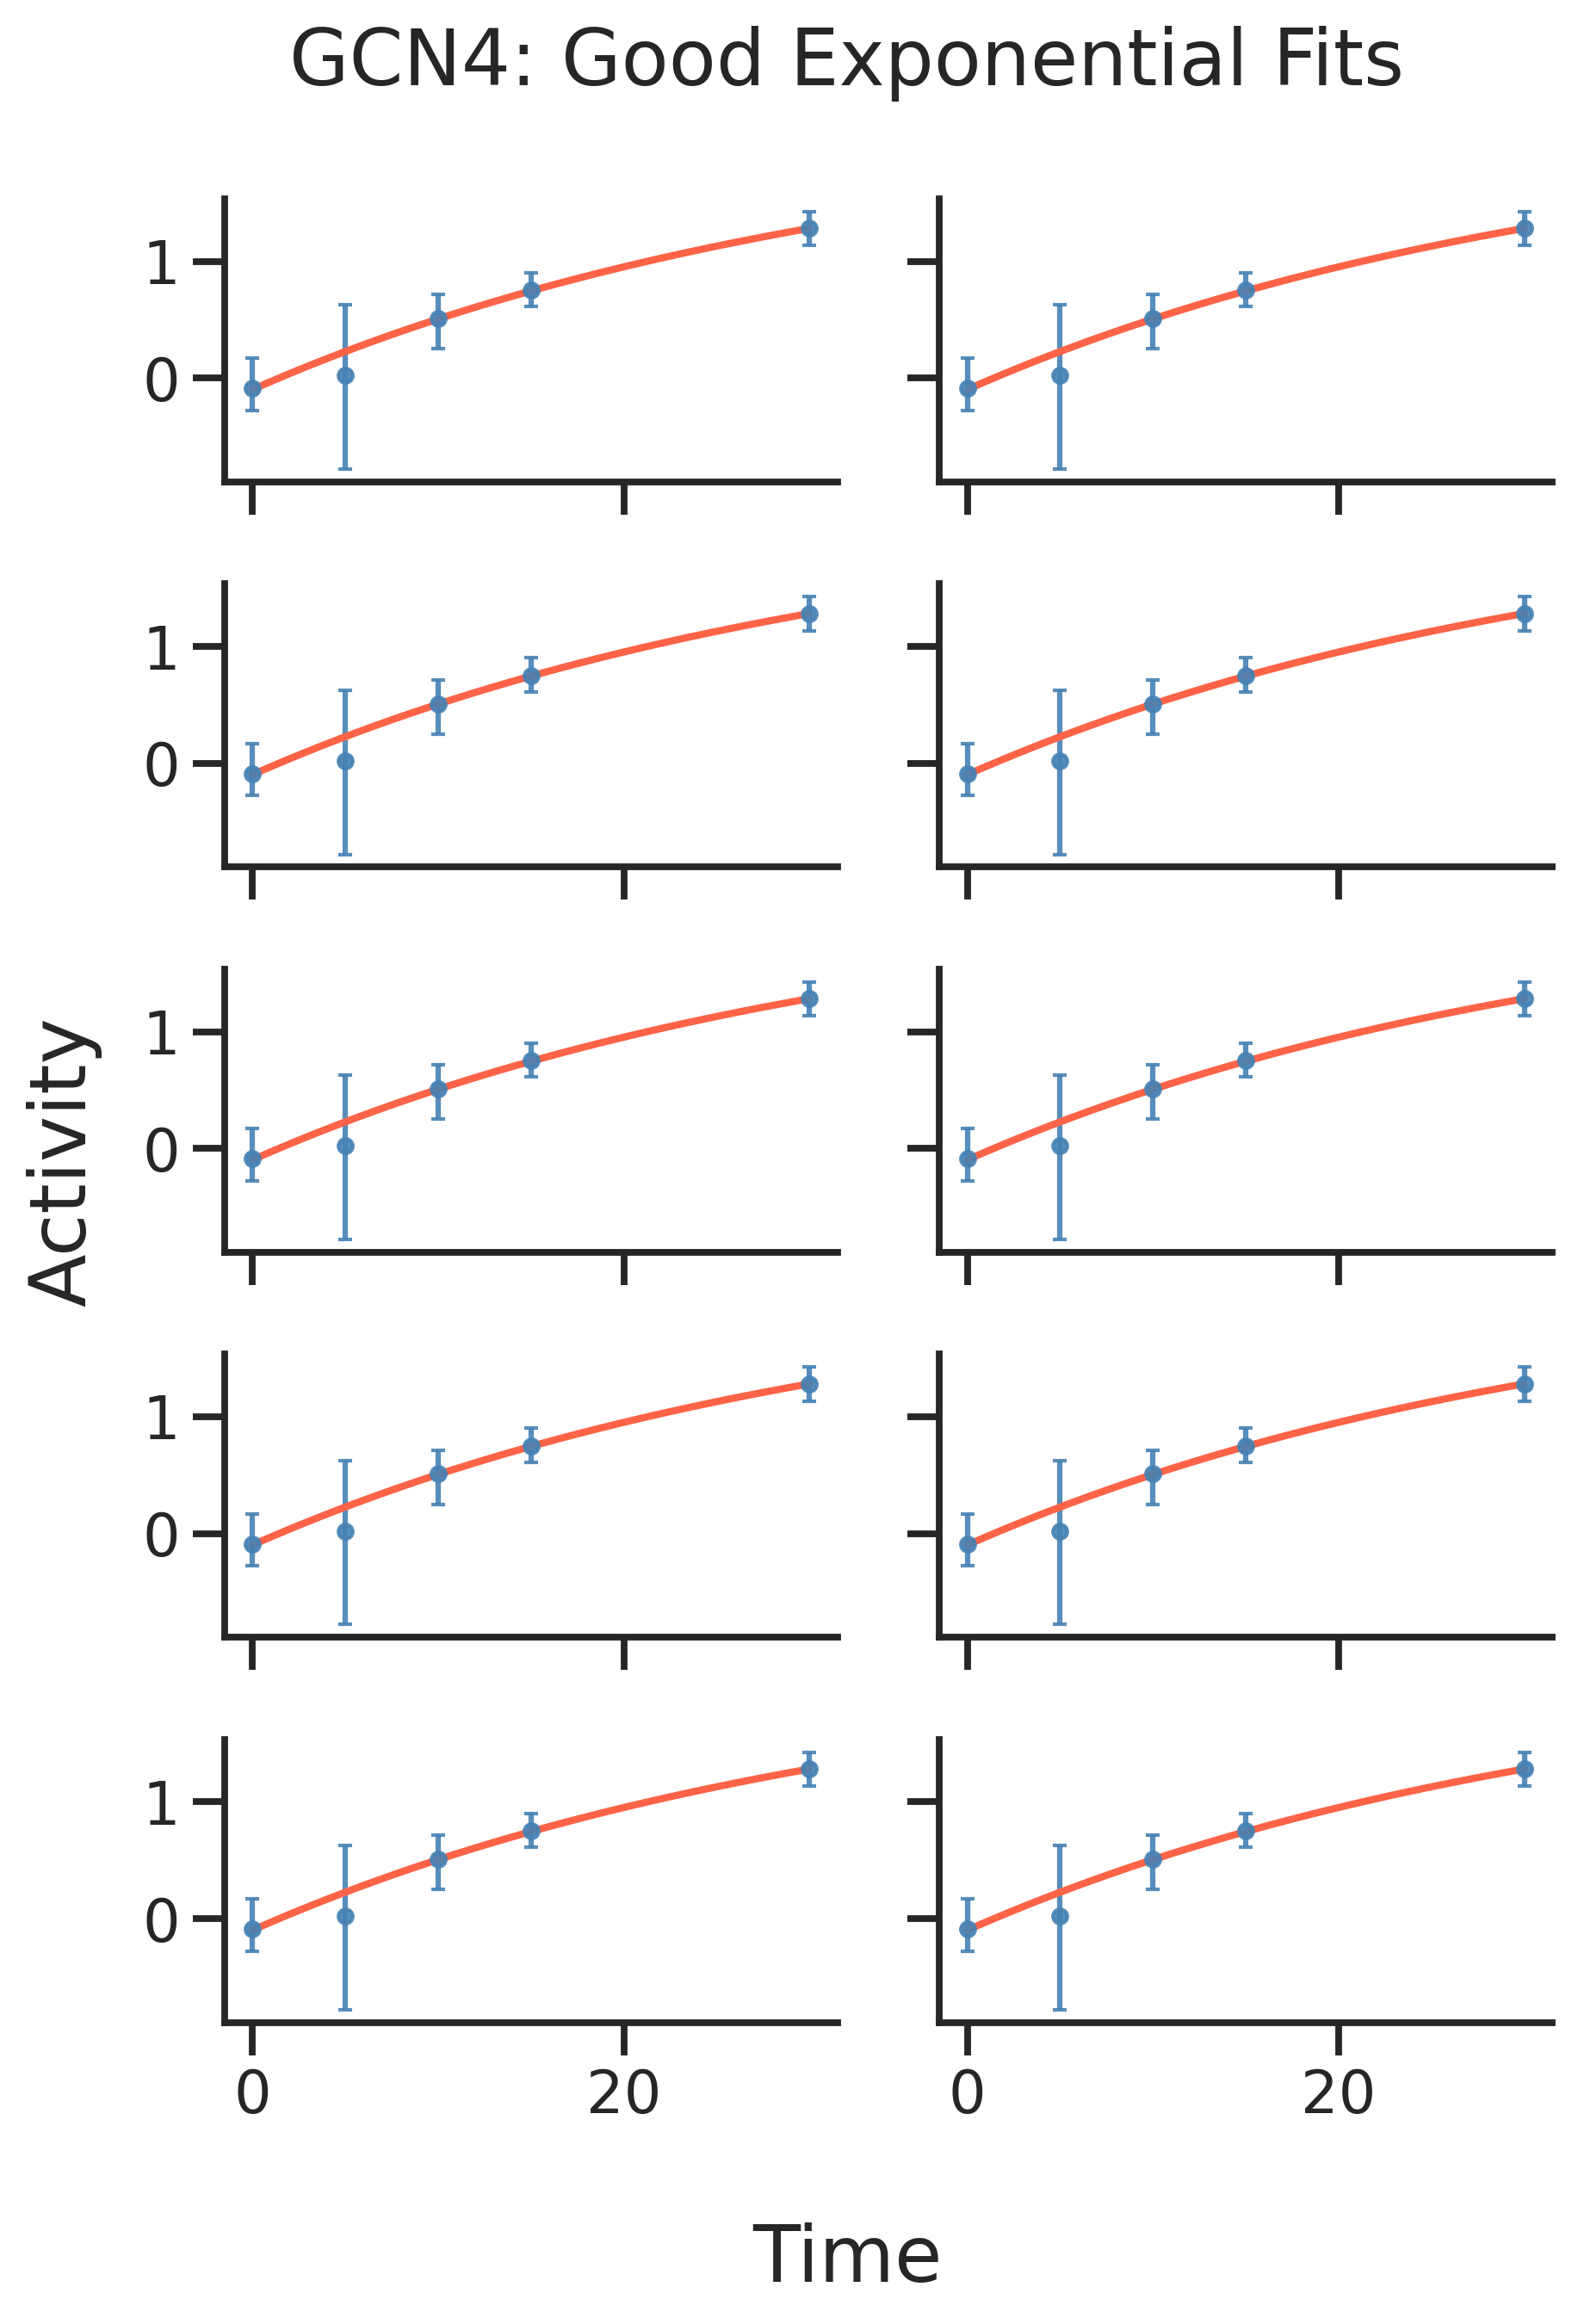

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

sample_adseqs = ["DLGGDITAFVQPSSLYGDEDSCAMDRTFSSTSMASSTPSC"] * 16
#ok.sample(16, random_state=42)["ADseq"].values

speed_plotting_helpers.plot_model_fits(
    activities=active_tile_activities_count_filtered,
    fit_results=fit_results,
    sample_adseqs=sample_adseqs,
    model_fn=rising_exponential,
    model_params=["A", "k", "C"],
    y_col="activity",
    title="GCN4: Good Exponential Fits",
)

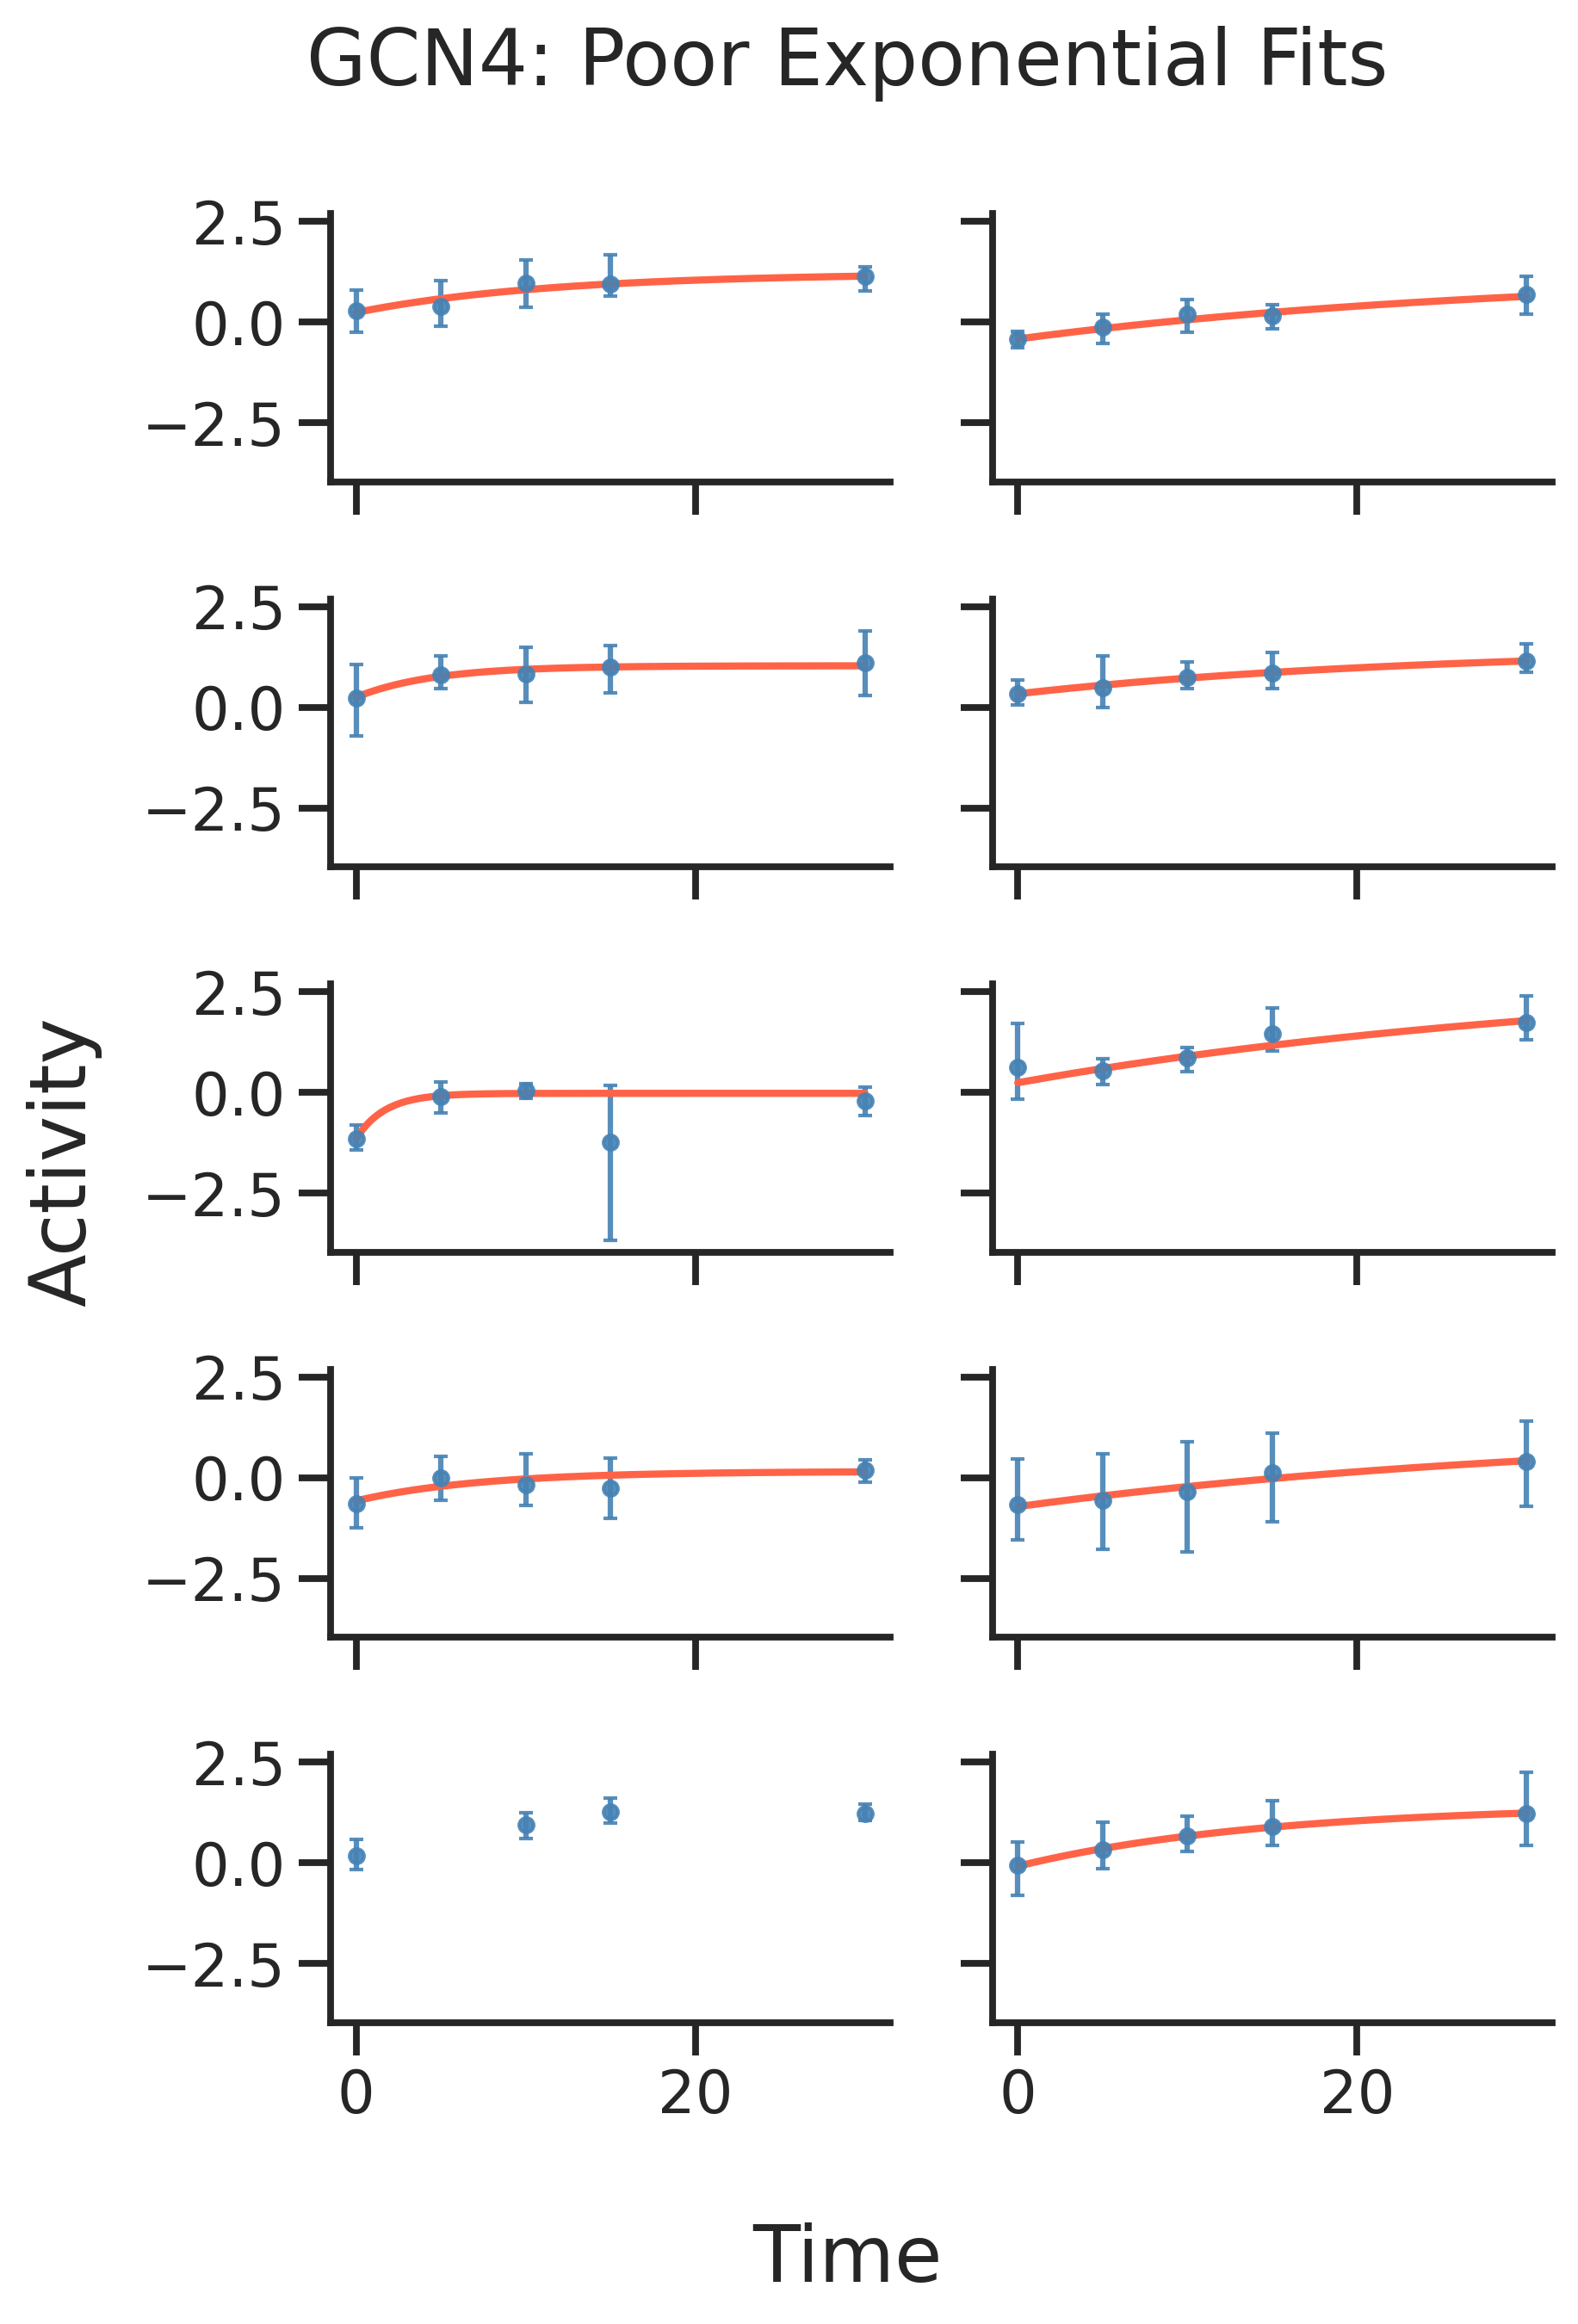

In [18]:
sample_adseqs = not_ok.sample(16, random_state=42)["ADseq"].values

speed_plotting_helpers.plot_model_fits(
    activities=active_tile_activities_count_filtered,
    fit_results=fit_results,
    sample_adseqs=sample_adseqs,
    model_fn=rising_exponential,
    model_params=["A", "k", "C"],
    y_col="activity",
    title="GCN4: Poor Exponential Fits",
)

In [19]:
import numpy as np
import pandas as pd

# --- filter the valid range first ---
filtered = ok[
    (ok['k'] >= 0) & (ok['k'] <= 0.2) &
    (ok['obs_max'] >= 0) & (ok['obs_max'] <= 5)
].copy()

# --- 1. Similar A, different k ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.2  # ±0.3 SD around median

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) & (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('k')

# Pick two sequences with widely separated k
seq_simA_diffk = similar_A_sorted.iloc[[0, -1]]  # first and last k

# --- 2. Similar k, different A ---
k_target = filtered['k'].median()
k_tol = filtered['k'].std() * 0.2  # ±0.3 SD around median

similar_k = filtered[(filtered['k'] >= k_target - k_tol) & (filtered['k'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

# Pick two sequences with widely separated A
seq_simk_diffA = similar_k_sorted.iloc[[0, -1]]  # lowest and highest A

# --- Combine for inspection ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA])
to_plot

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
649,KCPLLLHCGETITIGEPSDLNLFDALVLGAKRIGHGYALA,2.812996,1.452758,0.025054,0.017188,0.816917,0.054427,27.666017,18.979570,2.303302,5.050100,0.978497,ok,NaN,3.629913,0.070477,39.913625
266,DVSPGFGSNDFDTGSNQWFSLFPDQSTTPDAPAPQPSPVQ,2.566662,0.401980,0.191755,0.050144,0.101330,0.384202,3.614754,0.945264,2.659844,3.426854,0.965341,ok,NaN,2.667992,0.492170,5.214988
1609,VFNSFVSNMNTDFISASNPATTATASDTVVTNPSIIPDSV,1.084658,0.252971,0.118635,0.066186,-0.938439,0.188315,5.842705,3.259633,0.115343,21.102204,0.992654,ok,NaN,0.146219,0.128678,8.429241
352,FACSLLTASFALDNLFDLPLDFGADDVTKDVSLFESVGYS,4.103922,0.125850,0.123904,0.007937,0.487573,0.080637,5.594214,0.358330,4.491755,4.509018,0.993928,ok,NaN,4.591495,0.508494,8.070744


In [20]:
ok["A_prop"] = ok["A+C"] / ok["obs_max"]
ok.sort_values(by = "A_prop")

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k,A_prop
1076,PSDLFMDASAPPSASFTDLSTPSFDSPGYFSQDTSPMFGT,2.481764,0.242051,0.336329,0.093943,0.270450,0.234703,2.060917,0.575650,2.752111,1.743487,0.923316,ok,NaN,2.752214,0.834690,2.973275,1.000037
1474,TDLSTPPFDSPGYFSHDPSPMLSDDFGSEQWDSLFPANDP,3.078616,0.222978,0.285403,0.038036,1.180899,0.212366,2.428660,0.323669,4.258926,1.262525,0.988489,ok,NaN,4.259515,0.878647,3.503816,1.000138
458,FTNLTSPDINDSPFNDSFDCSPMFQNEPTMANSDWFSLFP,3.747762,0.071137,0.282075,0.010569,1.452177,0.064253,2.457318,0.092070,5.199147,1.322645,0.992910,ok,NaN,5.199939,1.057149,3.545161,1.000152
1517,TNLDGKDALLDHTPMFDELDFIMDGAKVNSKEDWVALFGG,4.010624,0.087698,0.281834,0.010580,0.780614,0.085012,2.459419,0.092326,4.790385,1.803607,0.992554,ok,NaN,4.791239,1.130329,3.548192,1.000178
1572,TTHLTSPLSFFDSPNDSYDTSPLFAPDDITQDGAWYSLFP,3.968838,0.073090,0.272386,0.013074,1.395933,0.060428,2.544725,0.122144,5.363650,1.442886,0.989770,ok,NaN,5.364771,1.081056,3.671262,1.000209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1498,THSCFSCPADQARARANWLNEWQDFVQWLLQEYDAENPET,2.597954,0.959508,0.033472,0.021677,0.113120,0.121357,20.708110,13.411037,1.759315,10.460922,0.979566,ok,NaN,2.711074,0.086959,29.875488,1.540983
938,NKQISARPPVPPFPHSTGSVPQIPNKMVLEDLQGLSDFAA,1.518492,0.834196,0.030258,0.025995,0.206959,0.102889,22.908088,19.681134,1.112834,8.657315,0.951734,ok,NaN,1.725452,0.045946,33.049385,1.550502
1166,RDFLAQFPADRIGKSAMDWLAHKLIFTPEESYDISQTSKG,1.718827,0.907109,0.046863,0.045703,-0.542965,0.248699,14.790984,14.425060,0.754491,16.352705,0.986006,ok,NaN,1.175862,0.080549,21.338880,1.558483
649,KCPLLLHCGETITIGEPSDLNLFDALVLGAKRIGHGYALA,2.812996,1.452758,0.025054,0.017188,0.816917,0.054427,27.666017,18.979570,2.303302,5.050100,0.978497,ok,NaN,3.629913,0.070477,39.913625,1.575960


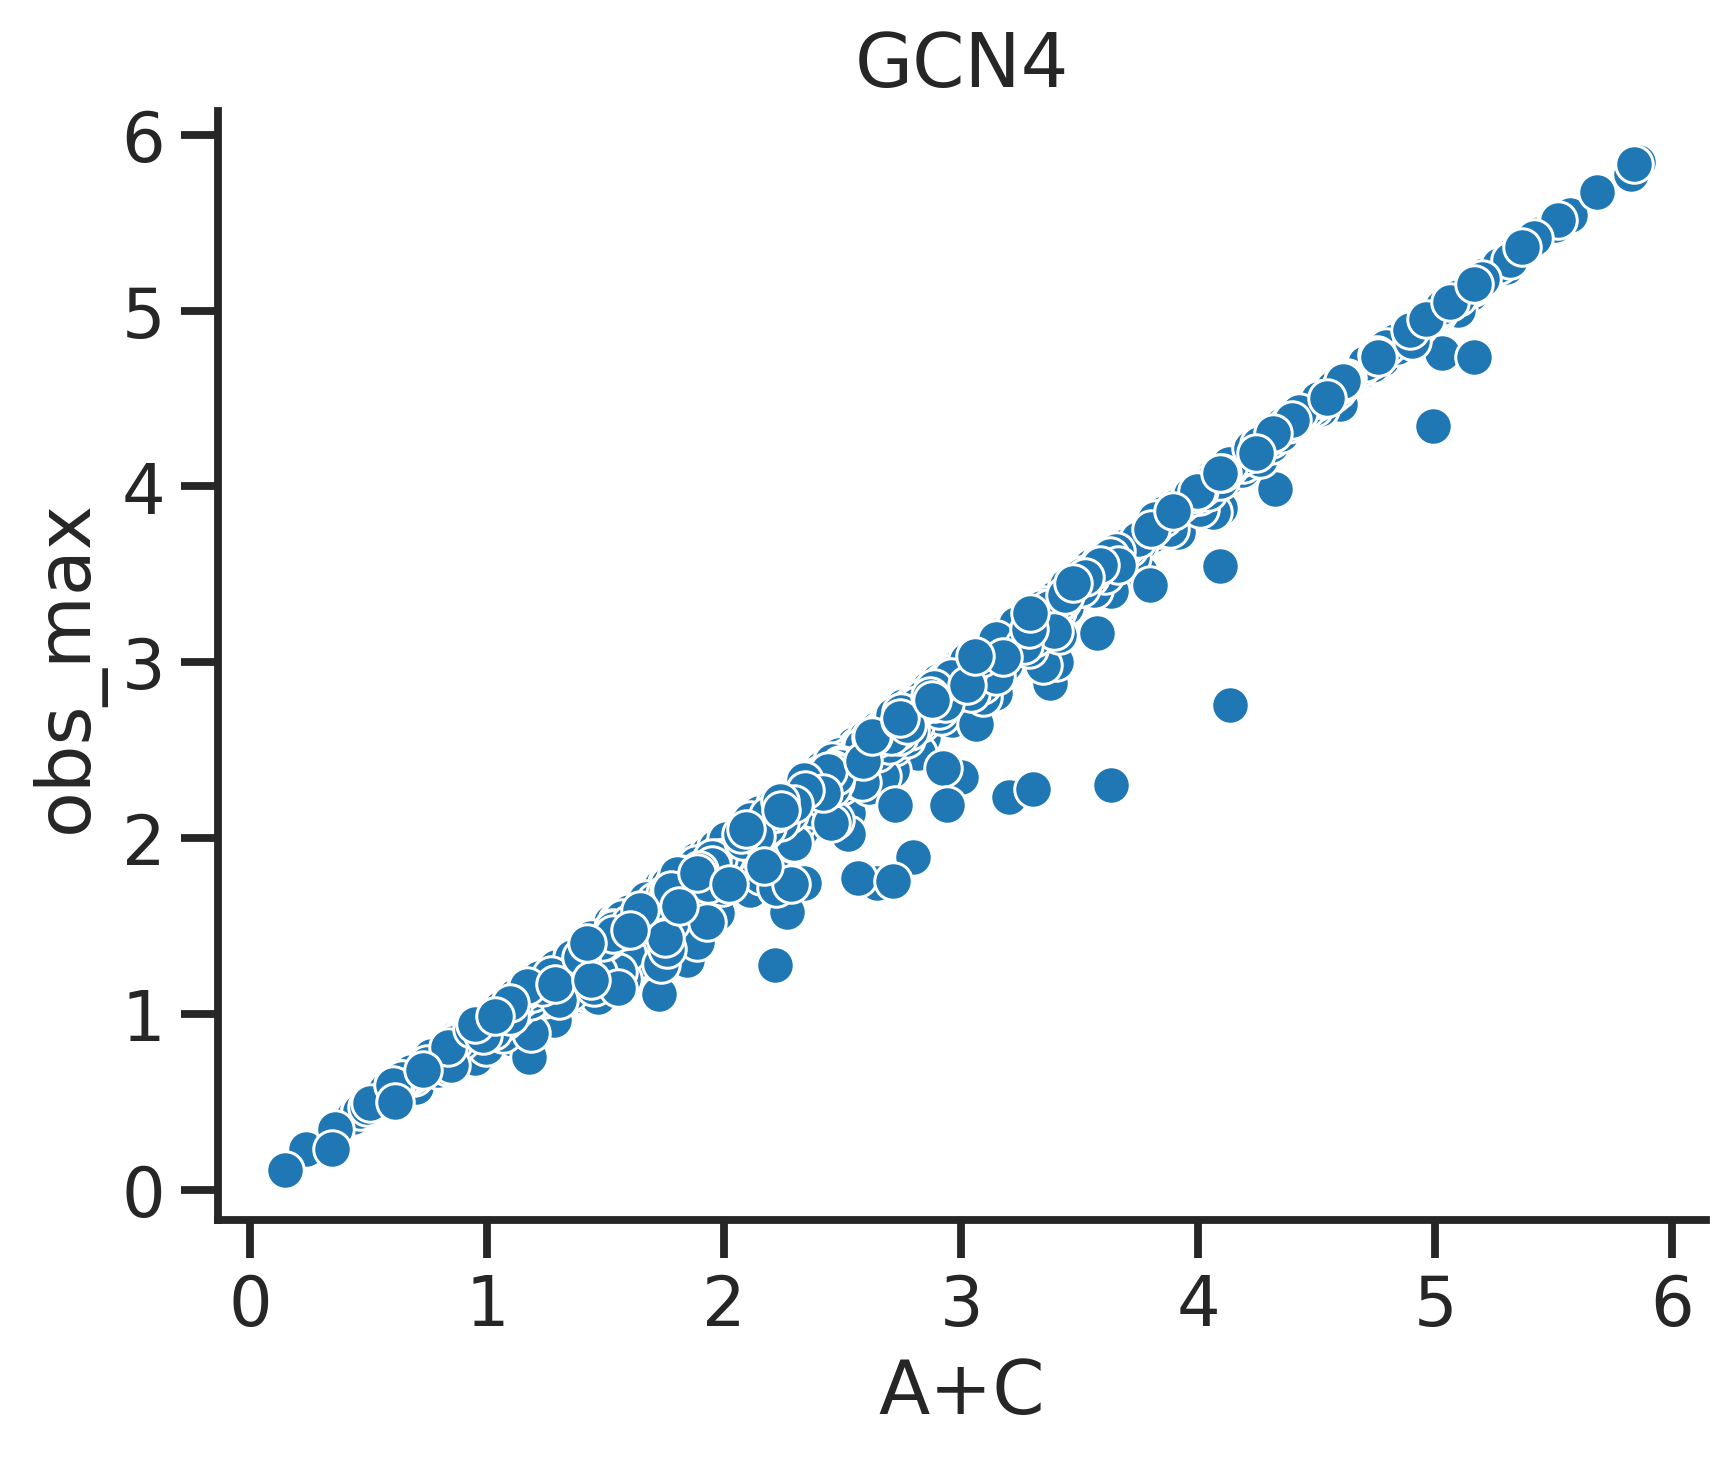

In [21]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "A+C", y = "obs_max")
plt.title("GCN4")
sns.despine()

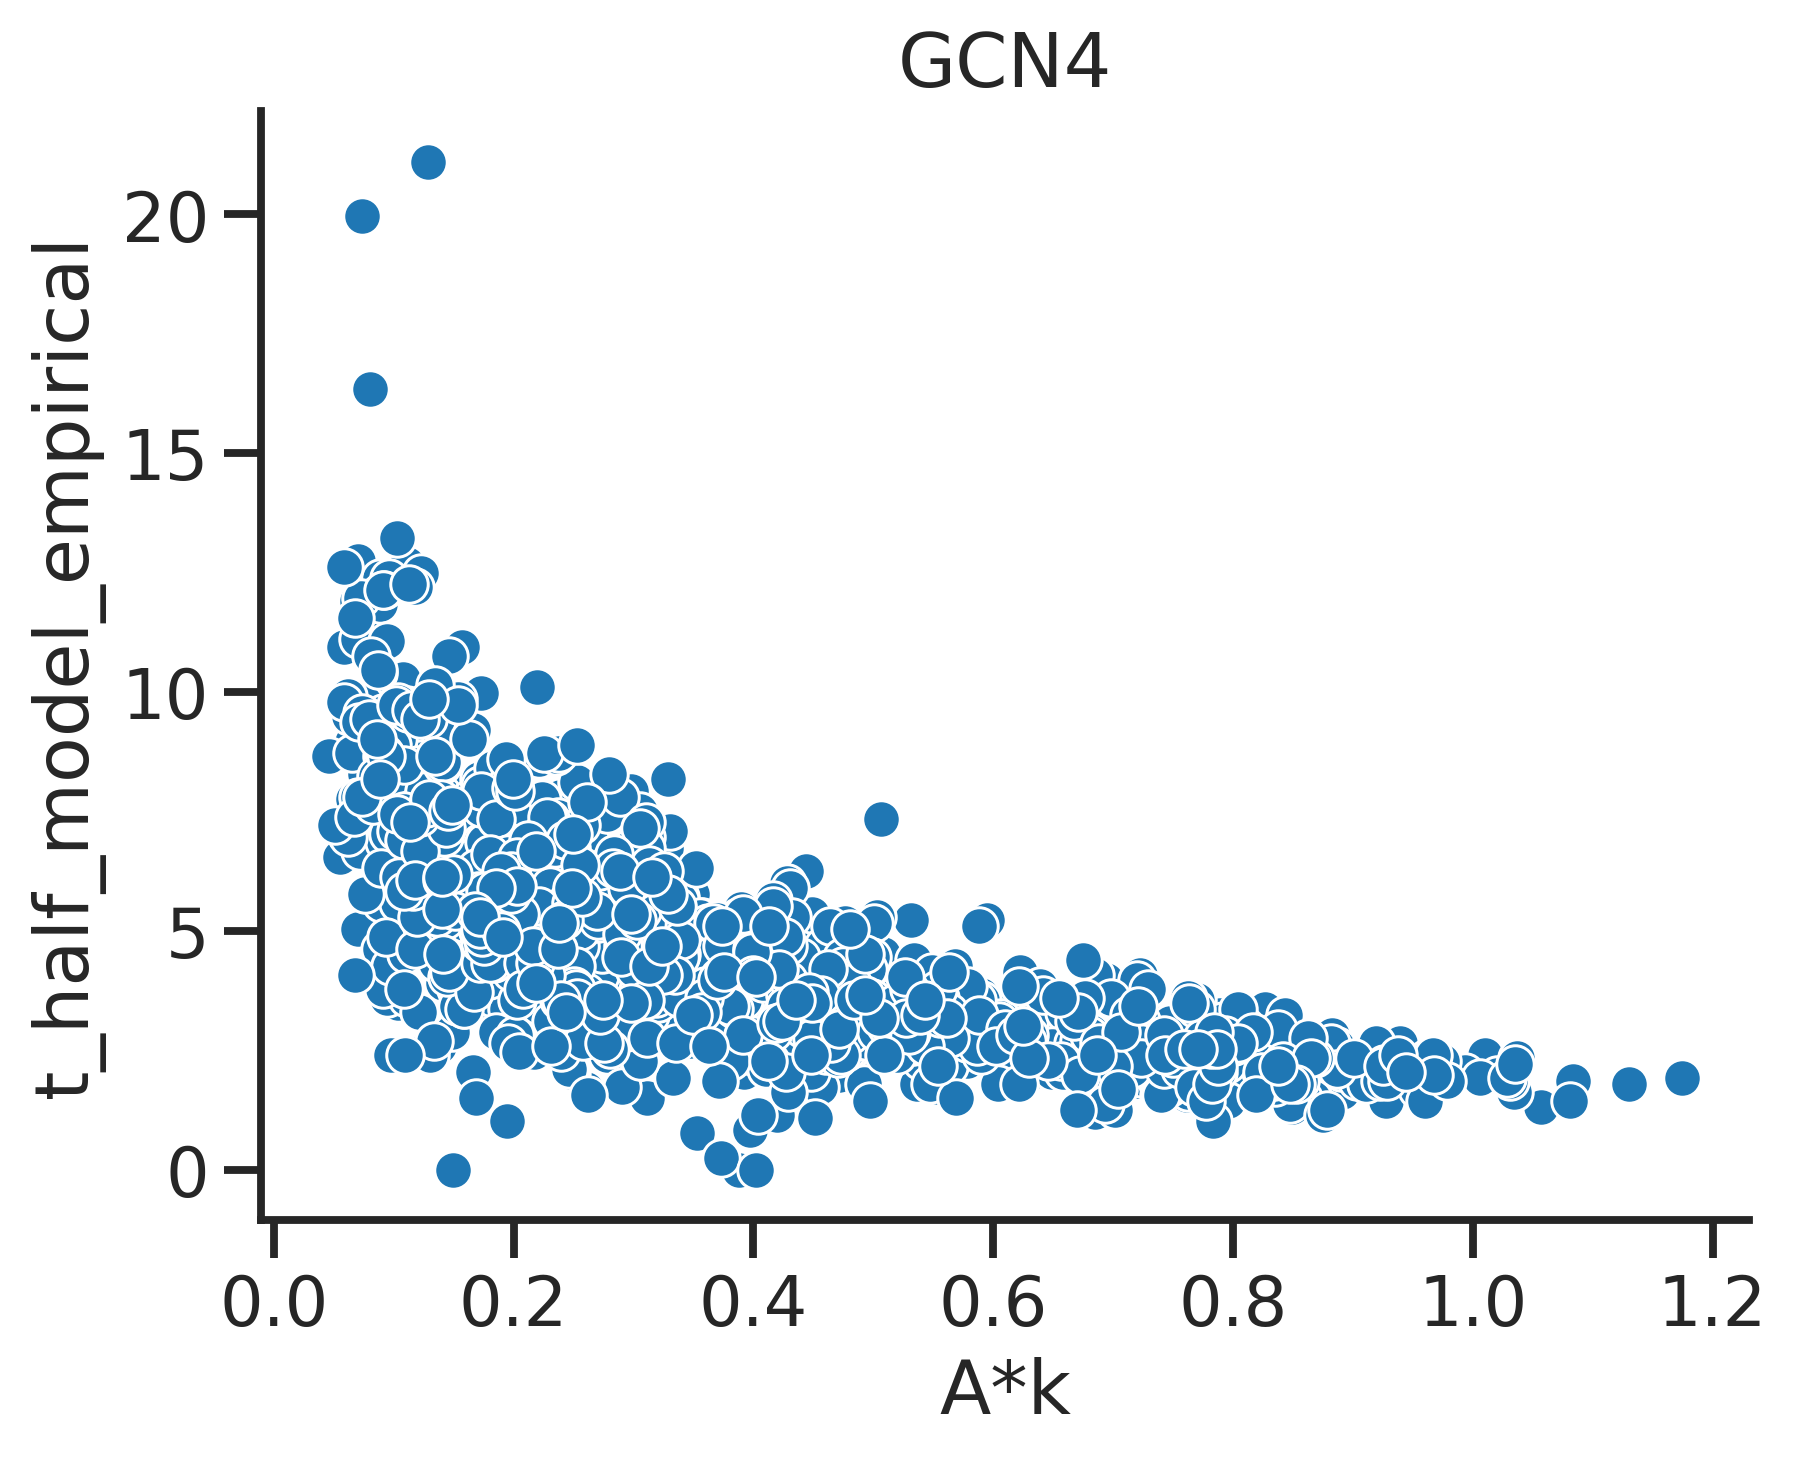

In [31]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "A*k", y = "t_half_model_empirical")
plt.title("GCN4")
sns.despine()

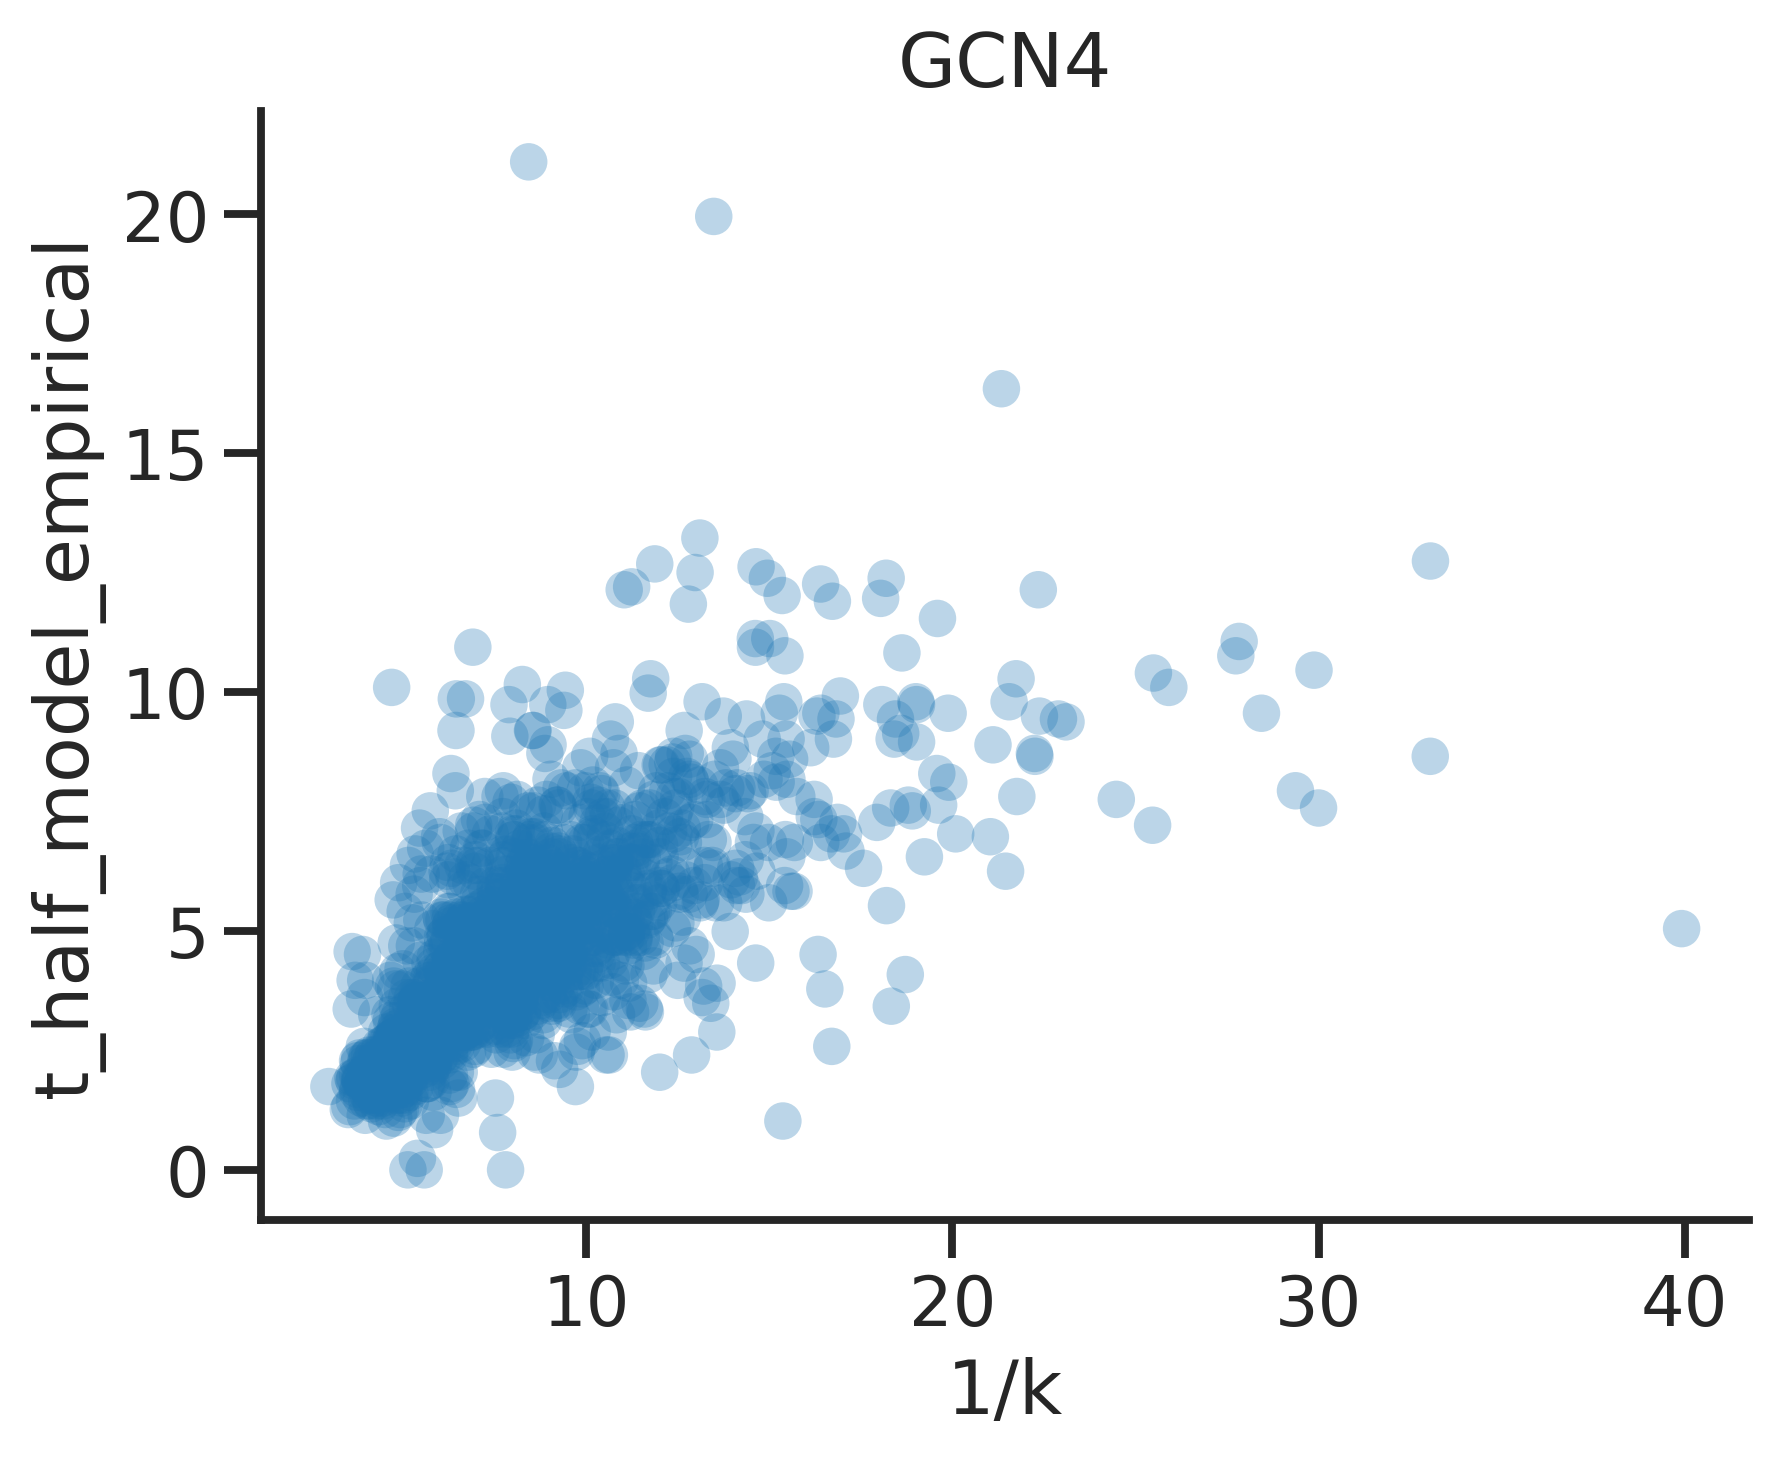

In [26]:
# Does the observed maximum correlate with the maximum from the model parameter?
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "1/k", y = "t_half_model_empirical", edgecolor = 'none', alpha = 0.3)
plt.title("GCN4")
sns.despine()

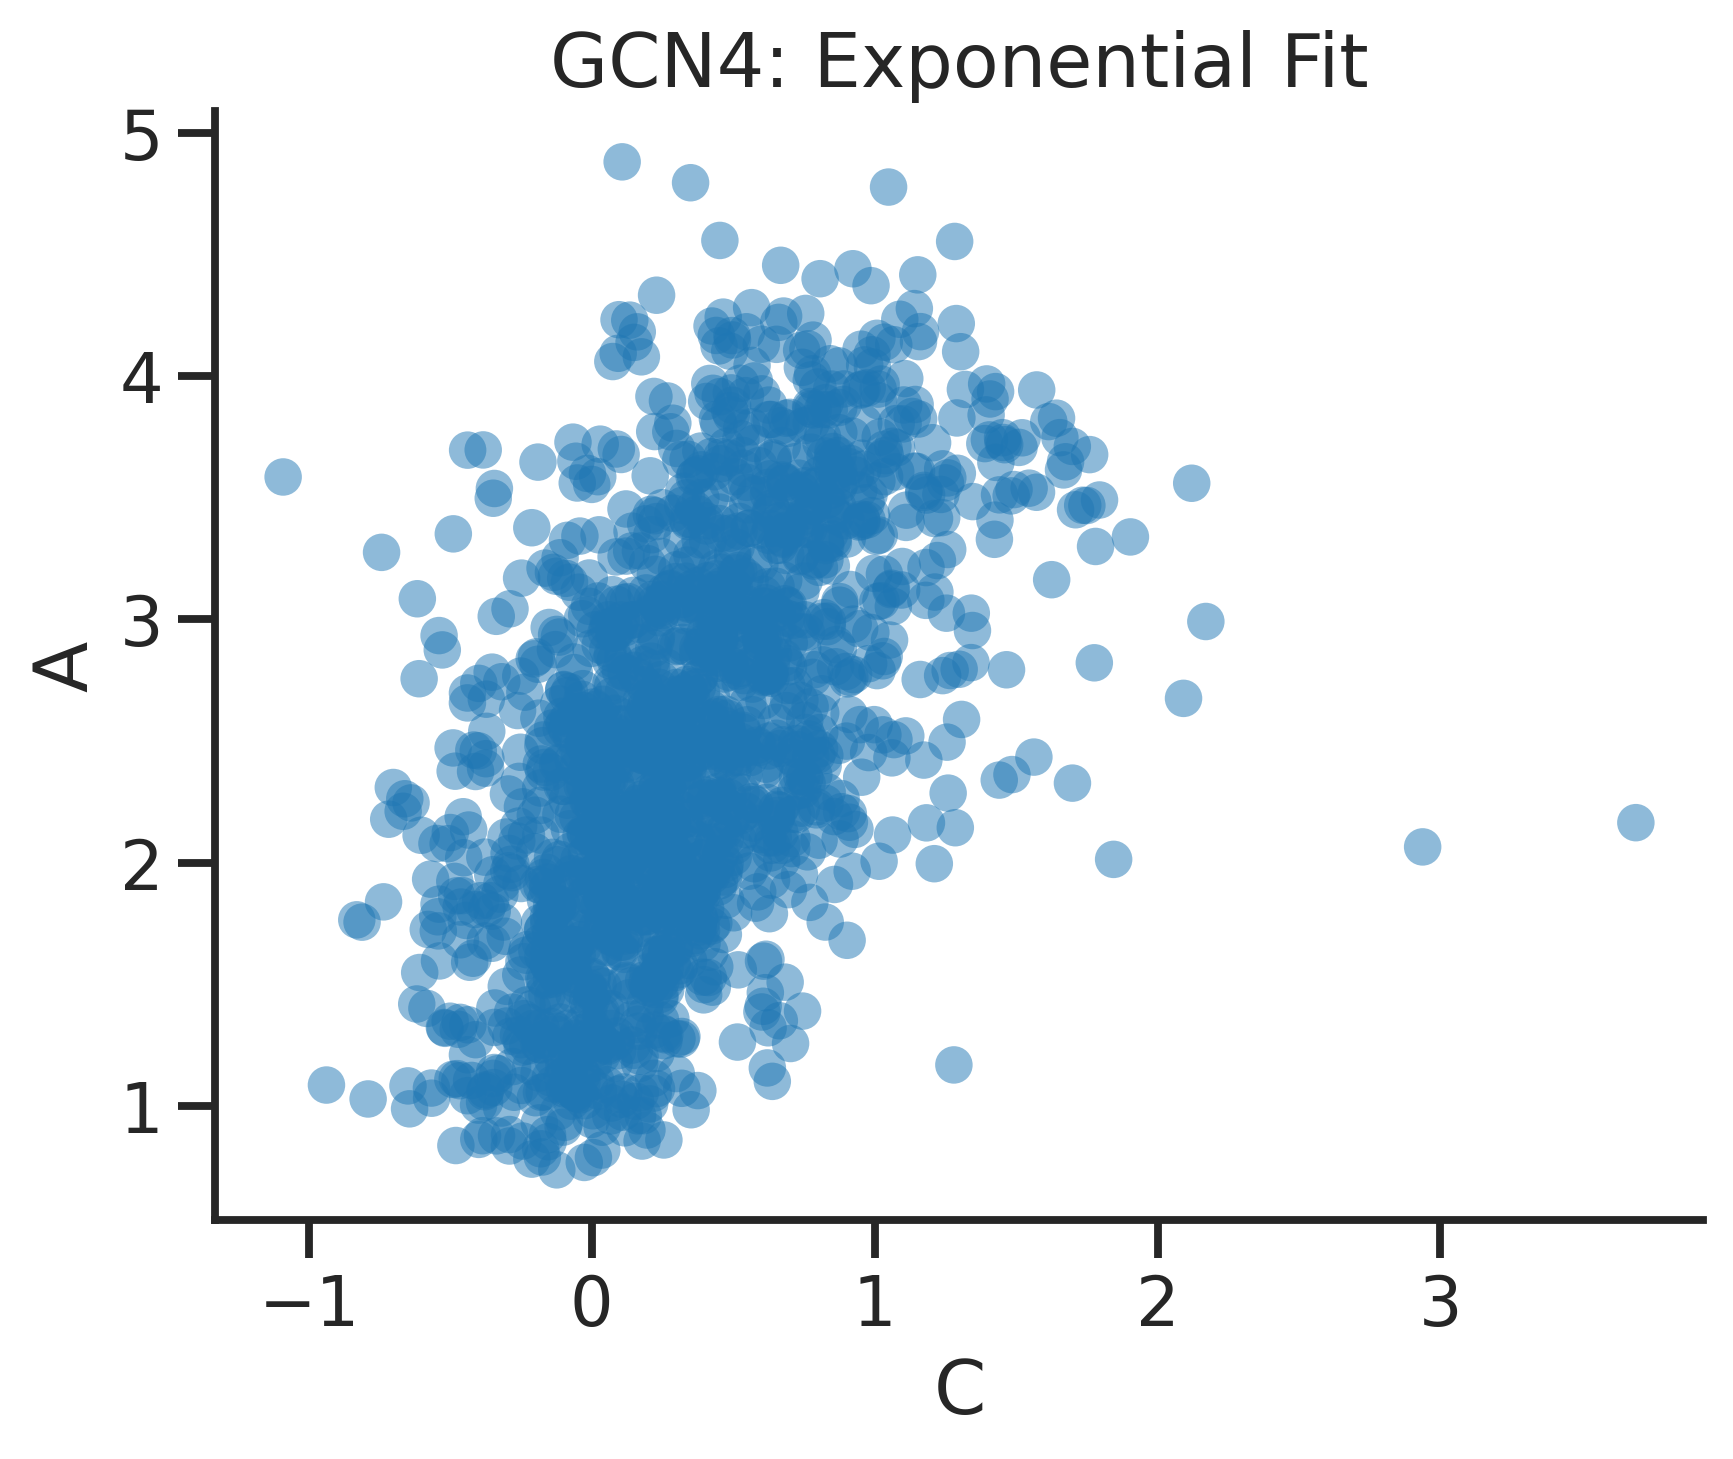

In [32]:
# The rise from baseline does not correlate with the starting activity
plt.figure(dpi = 300)
sns.scatterplot(data = ok, x = "C", y = "A", edgecolor = 'none', alpha = 0.5)
plt.title("GCN4: Exponential Fit")
sns.despine()

Pearson r = 0.555, p = 1.19e-126
Spearman rho = 0.558, p = 6.01e-128


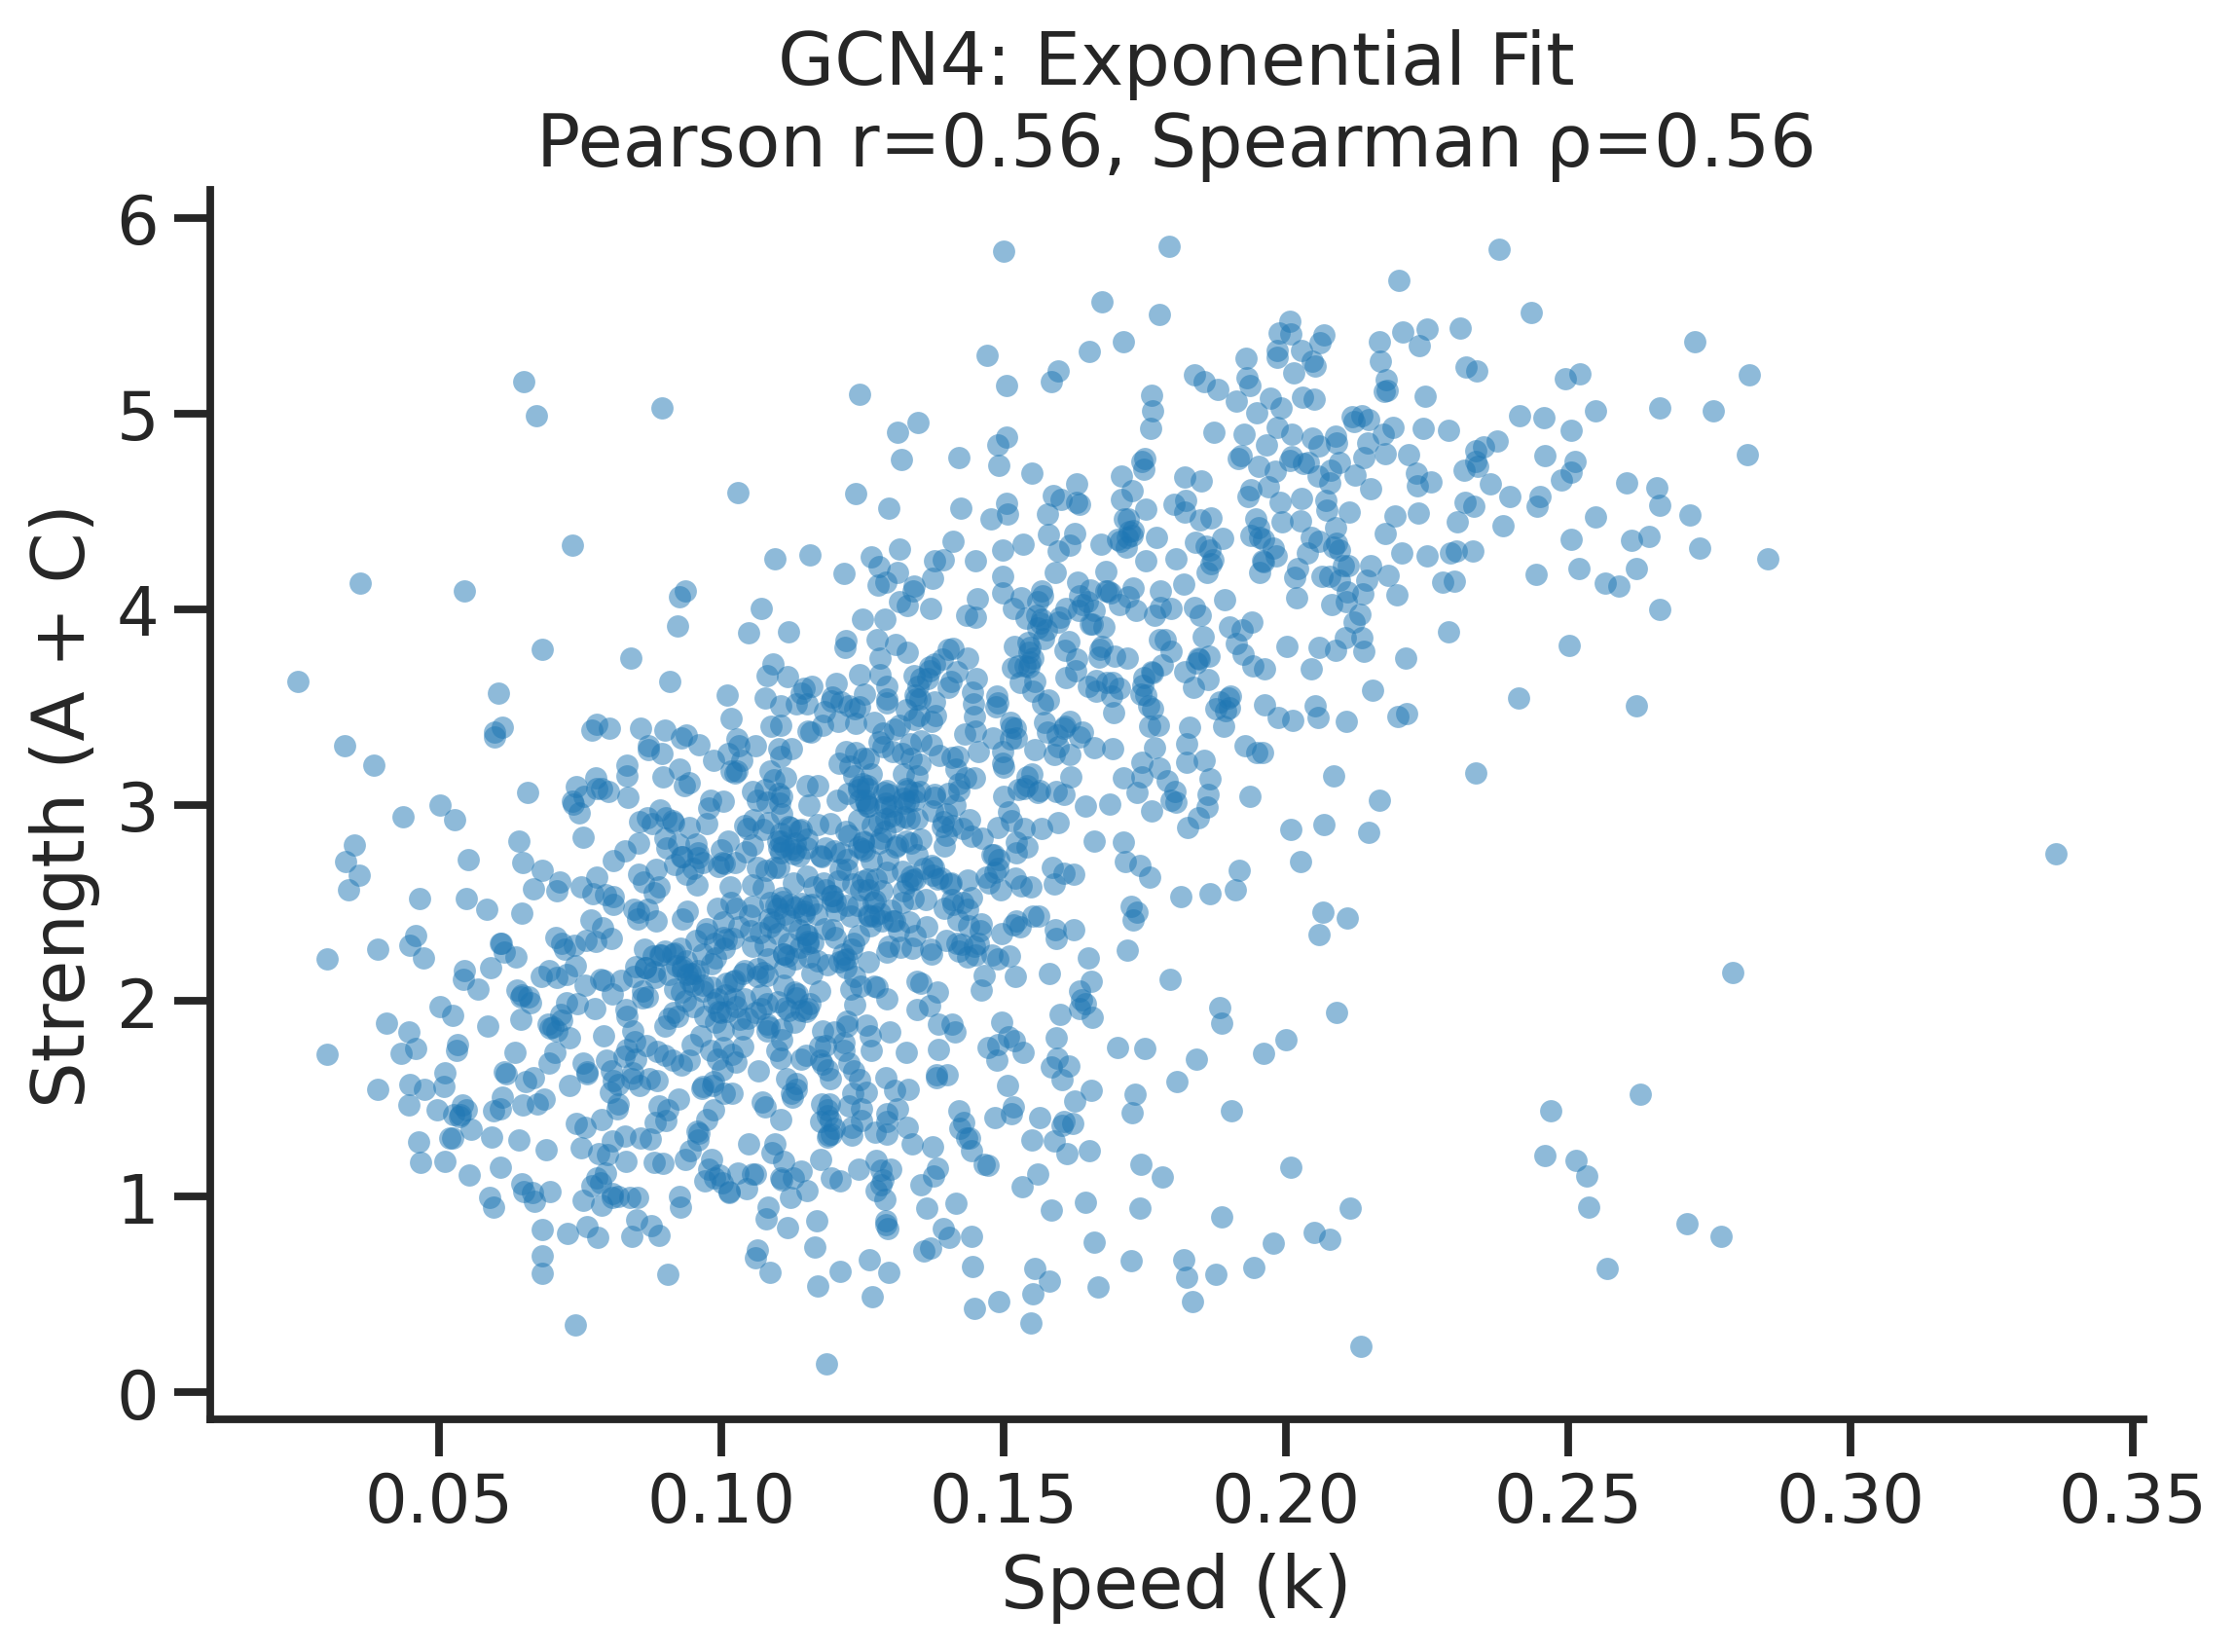

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['A+C'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['A+C'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Strength (A + C)')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.839, p = 0
Spearman rho = 0.846, p = 0


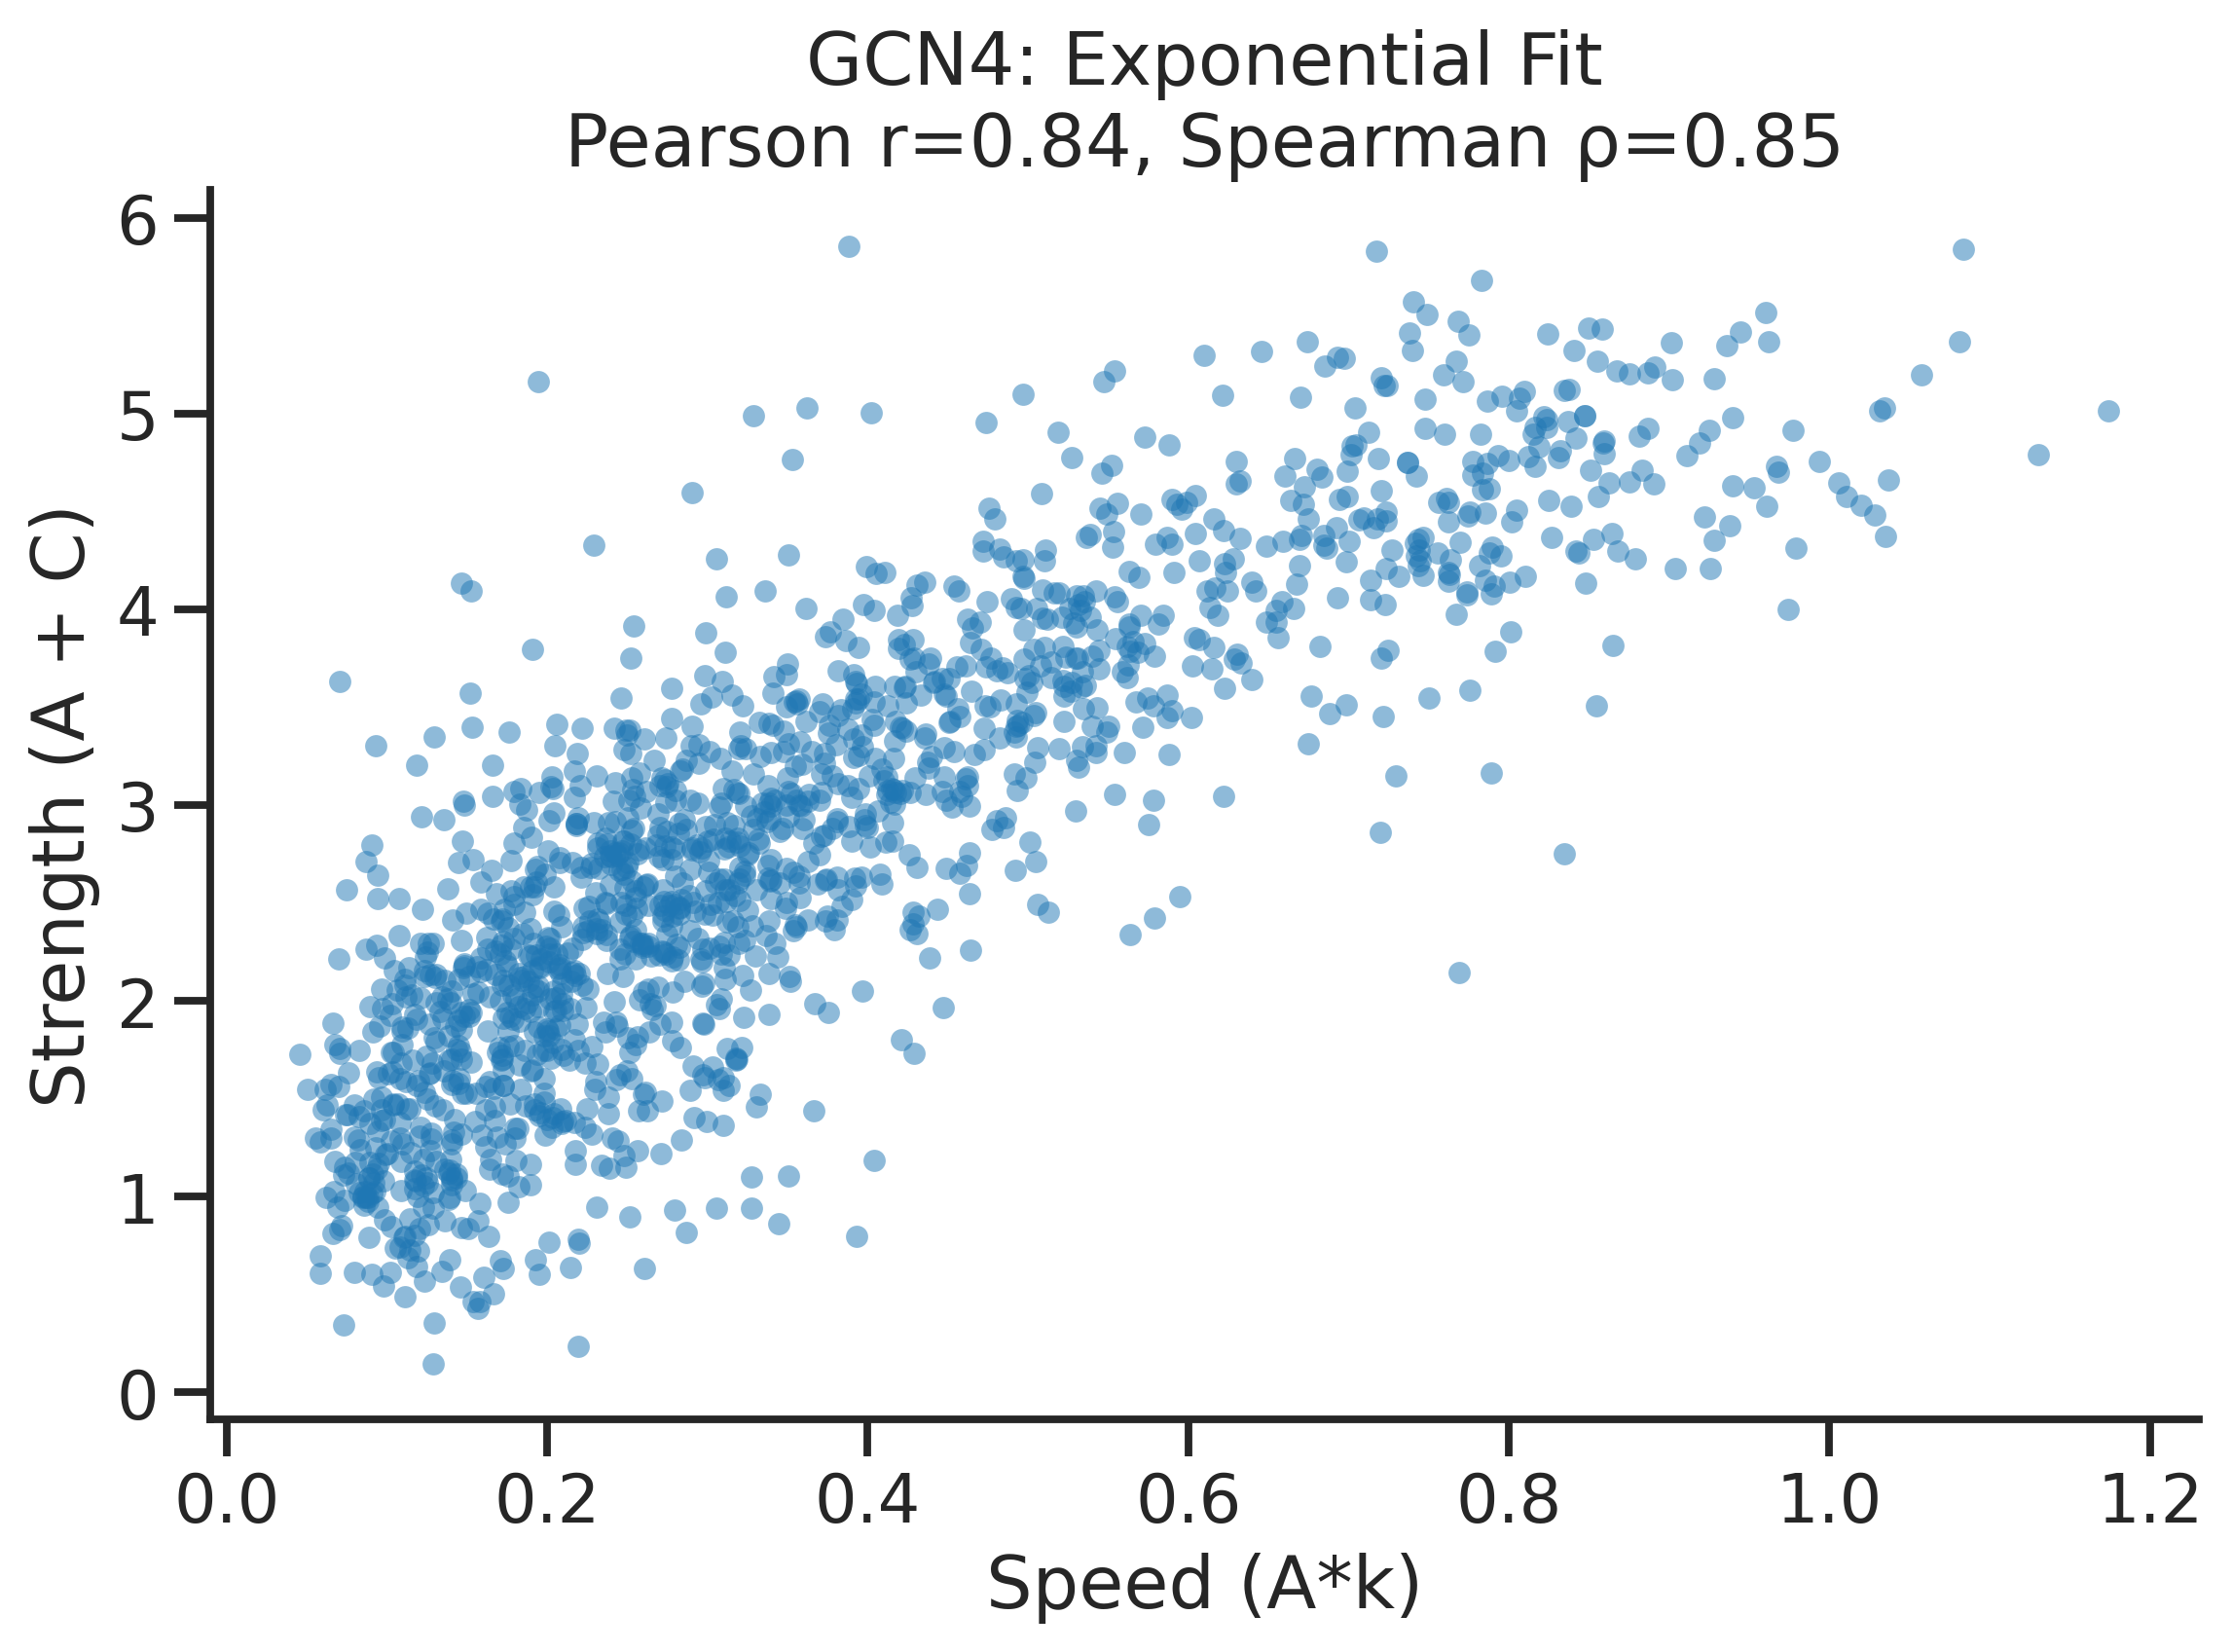

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['A*k'], ok ['A+C'])
spearman_corr, spearman_p = spearmanr(ok['A*k'], ok ['A+C'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['A*k'], ok['A+C'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (A*k)')
ax.set_ylabel('Strength (A + C)')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.870, p = 0
Spearman rho = 0.893, p = 0


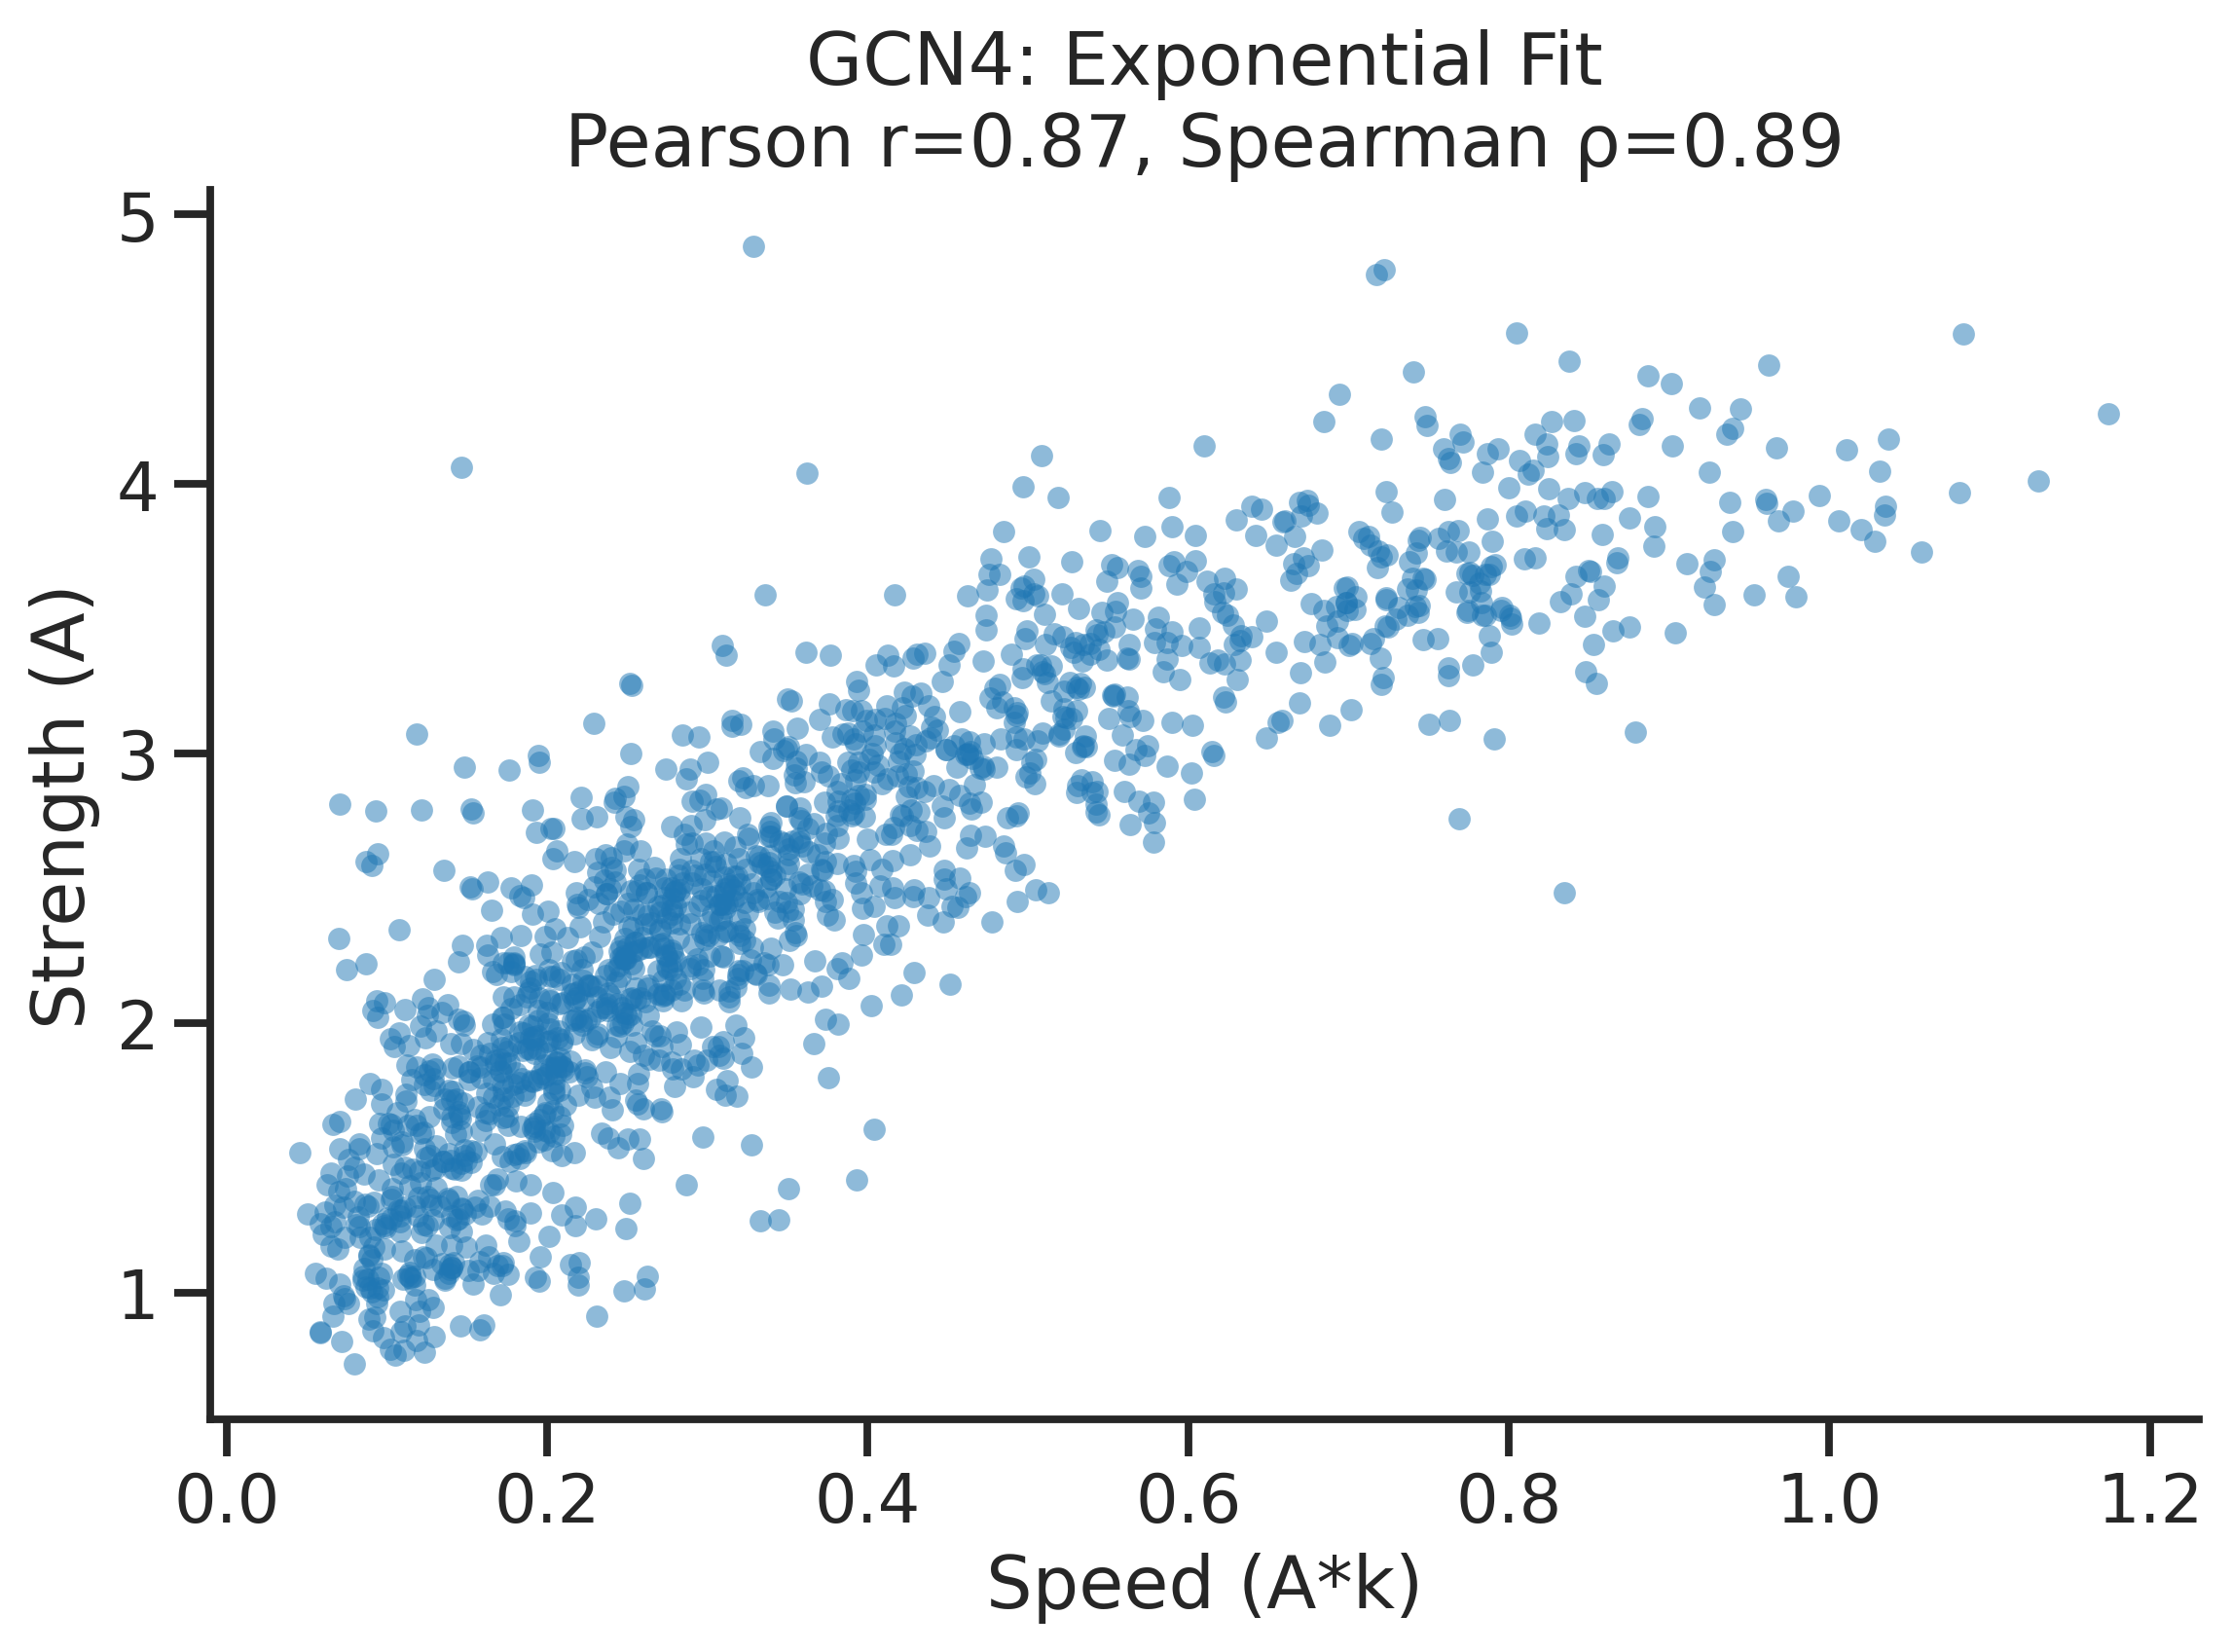

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['A*k'], ok ['A'])
spearman_corr, spearman_p = spearmanr(ok['A*k'], ok ['A'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['A*k'], ok['A'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (A*k)')
ax.set_ylabel('Strength (A)')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
#ax.set_ylim(0.5,2.7)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = -0.690, p = 5.22e-239
Spearman rho = -0.784, p = 0


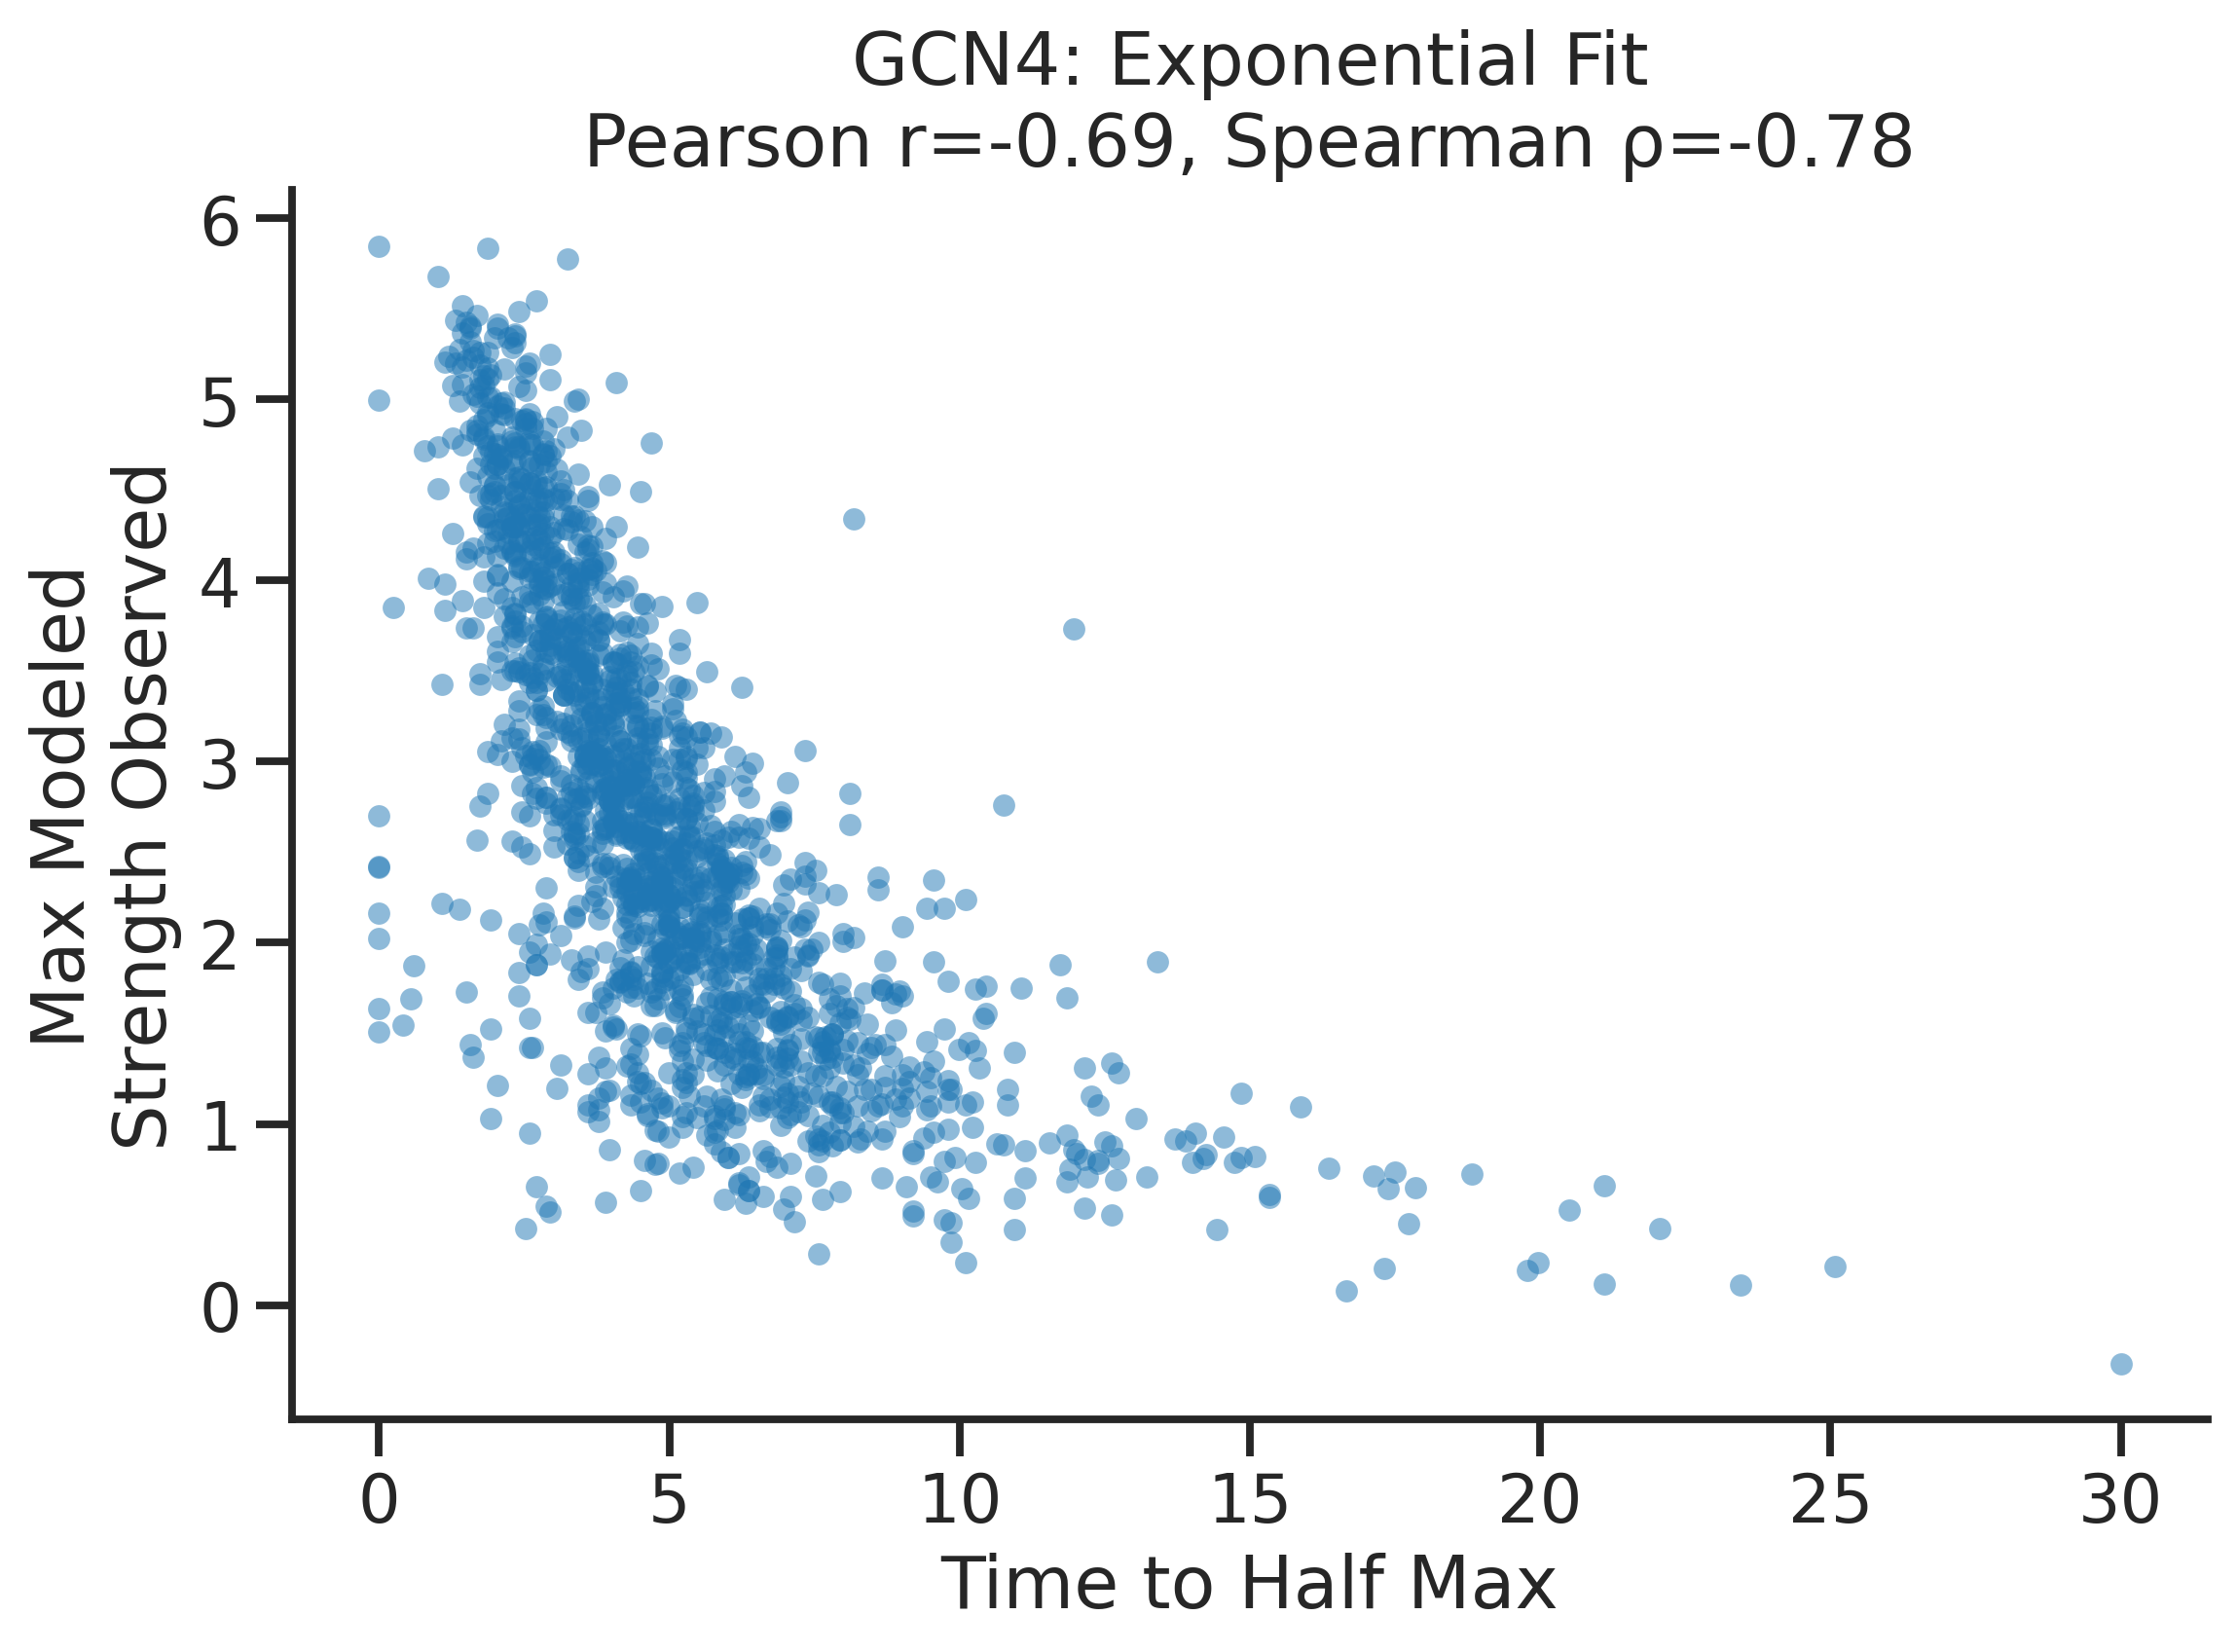

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_model_empirical'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_model_empirical'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_model_empirical'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.552, p = 4.75e-135
Spearman rho = 0.595, p = 3.23e-162


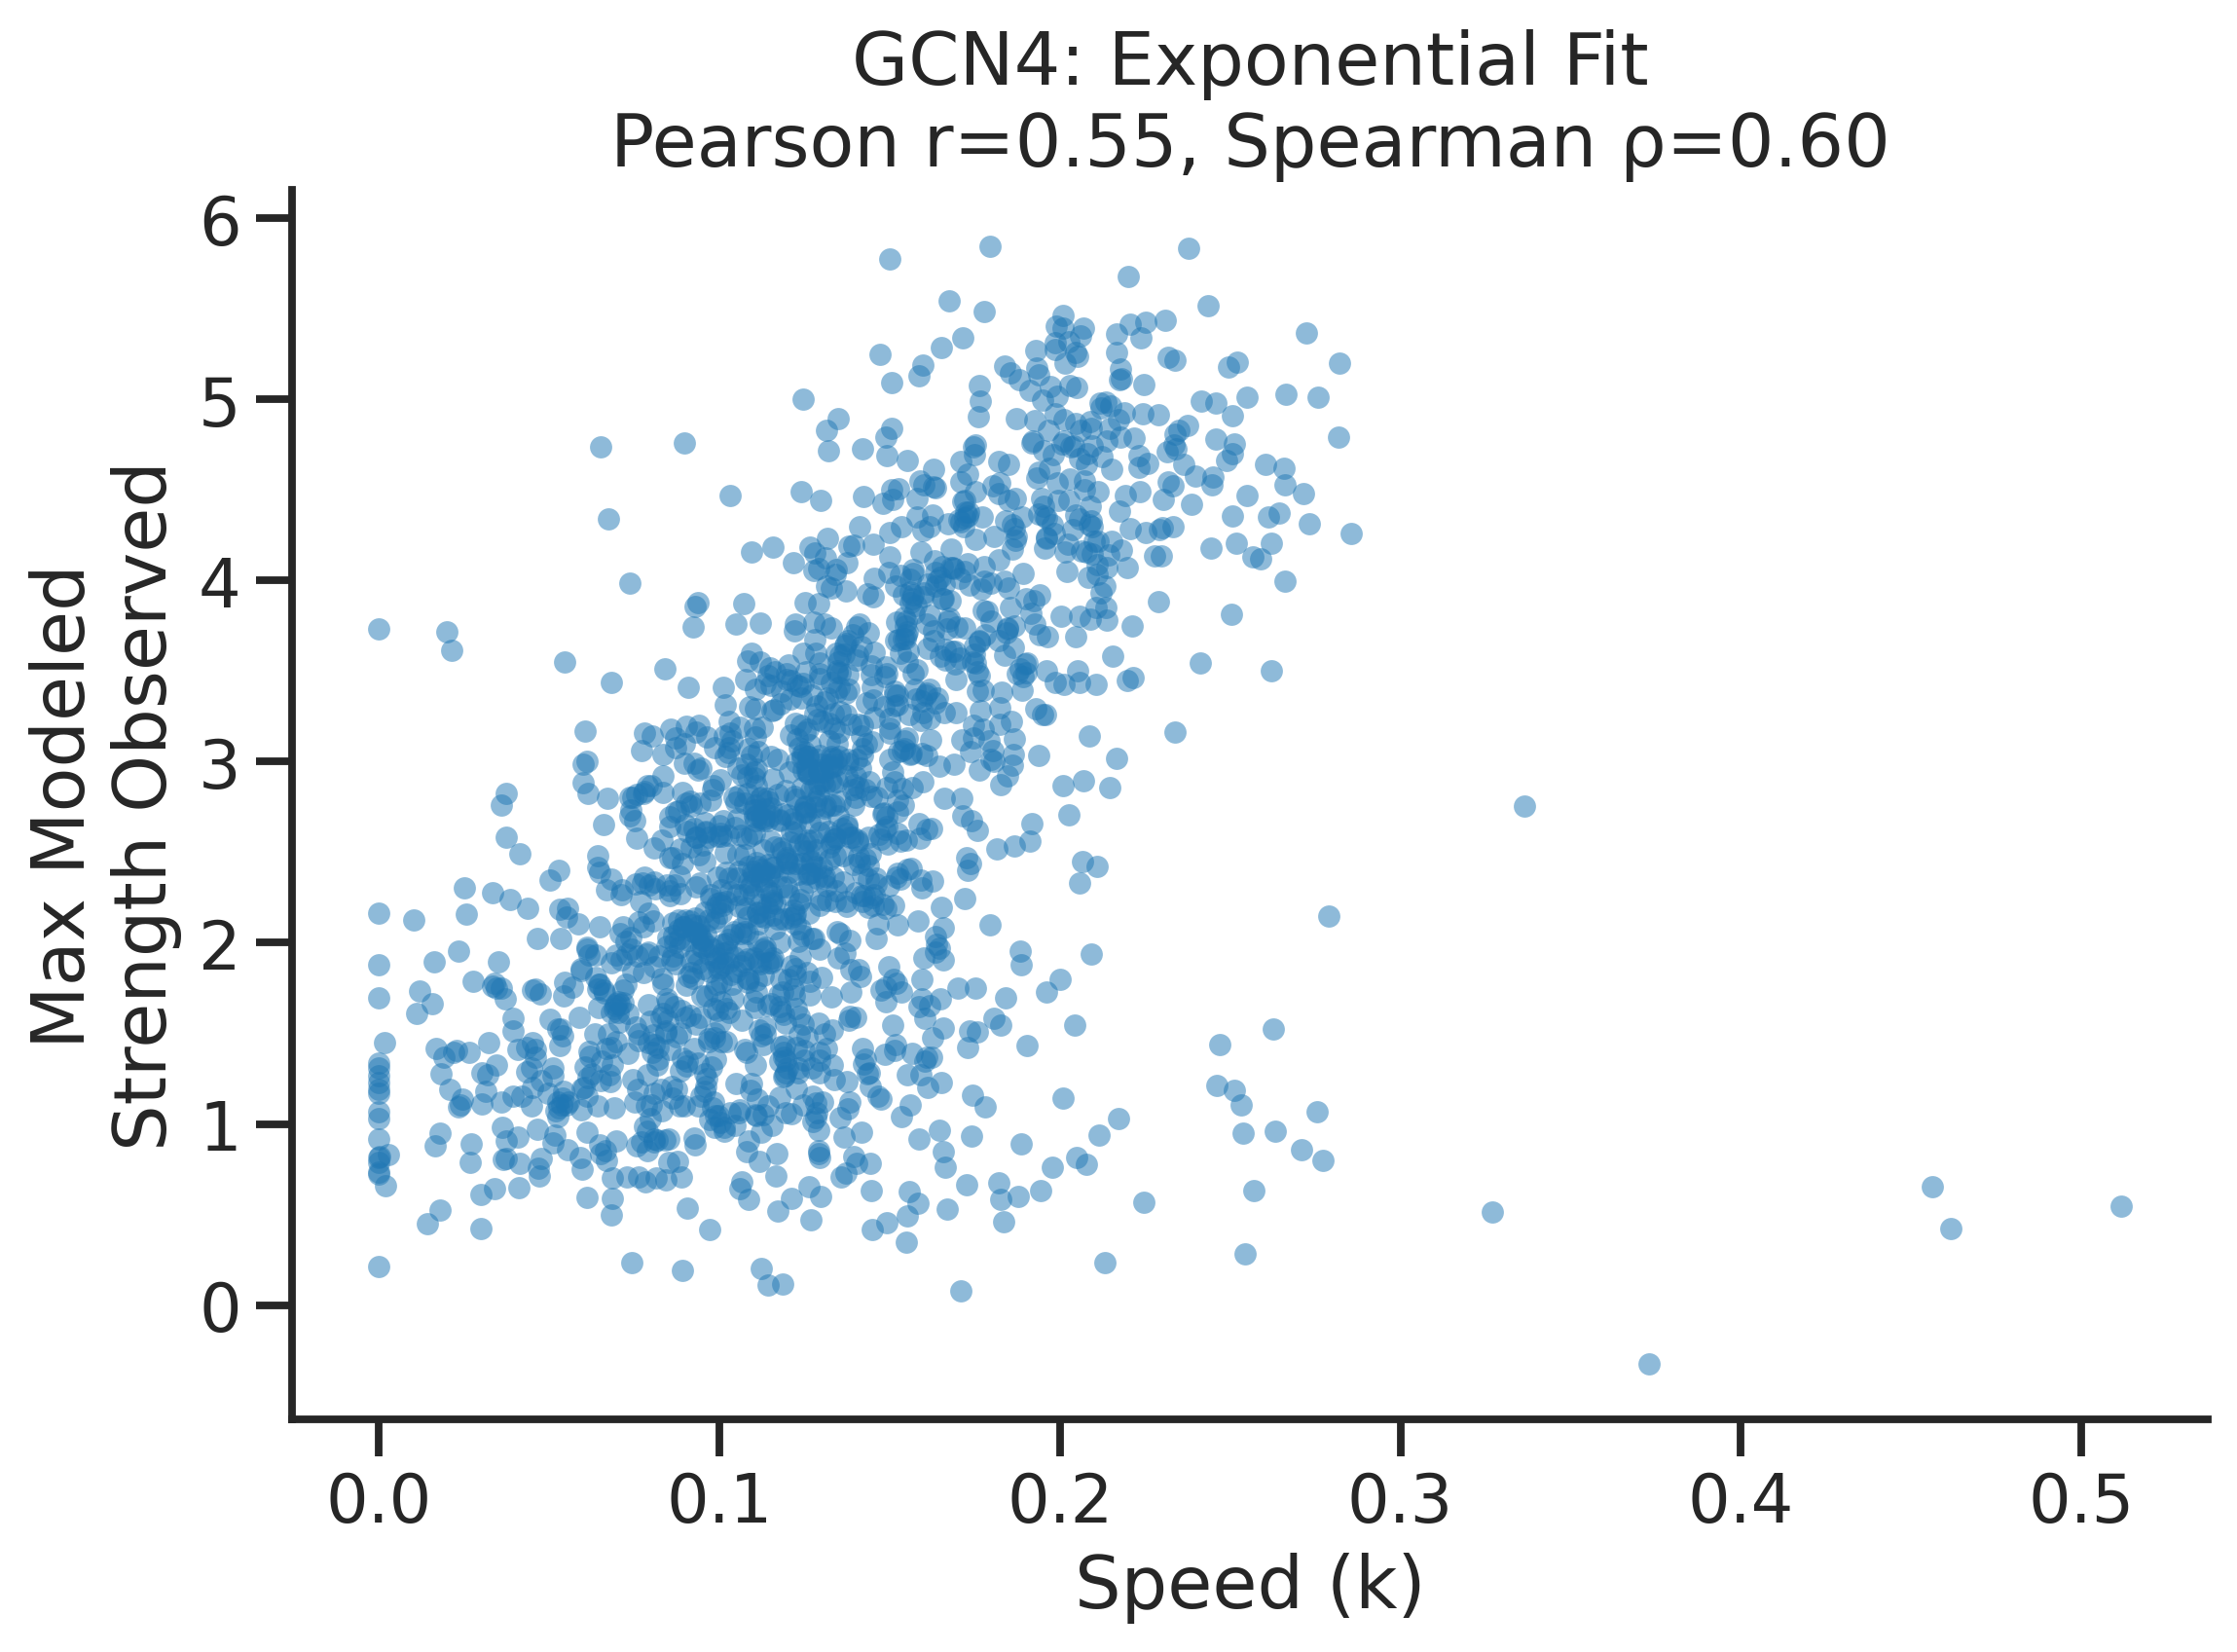

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

#ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r = 0.552, p = 4.75e-135
Spearman rho = 0.595, p = 3.23e-162


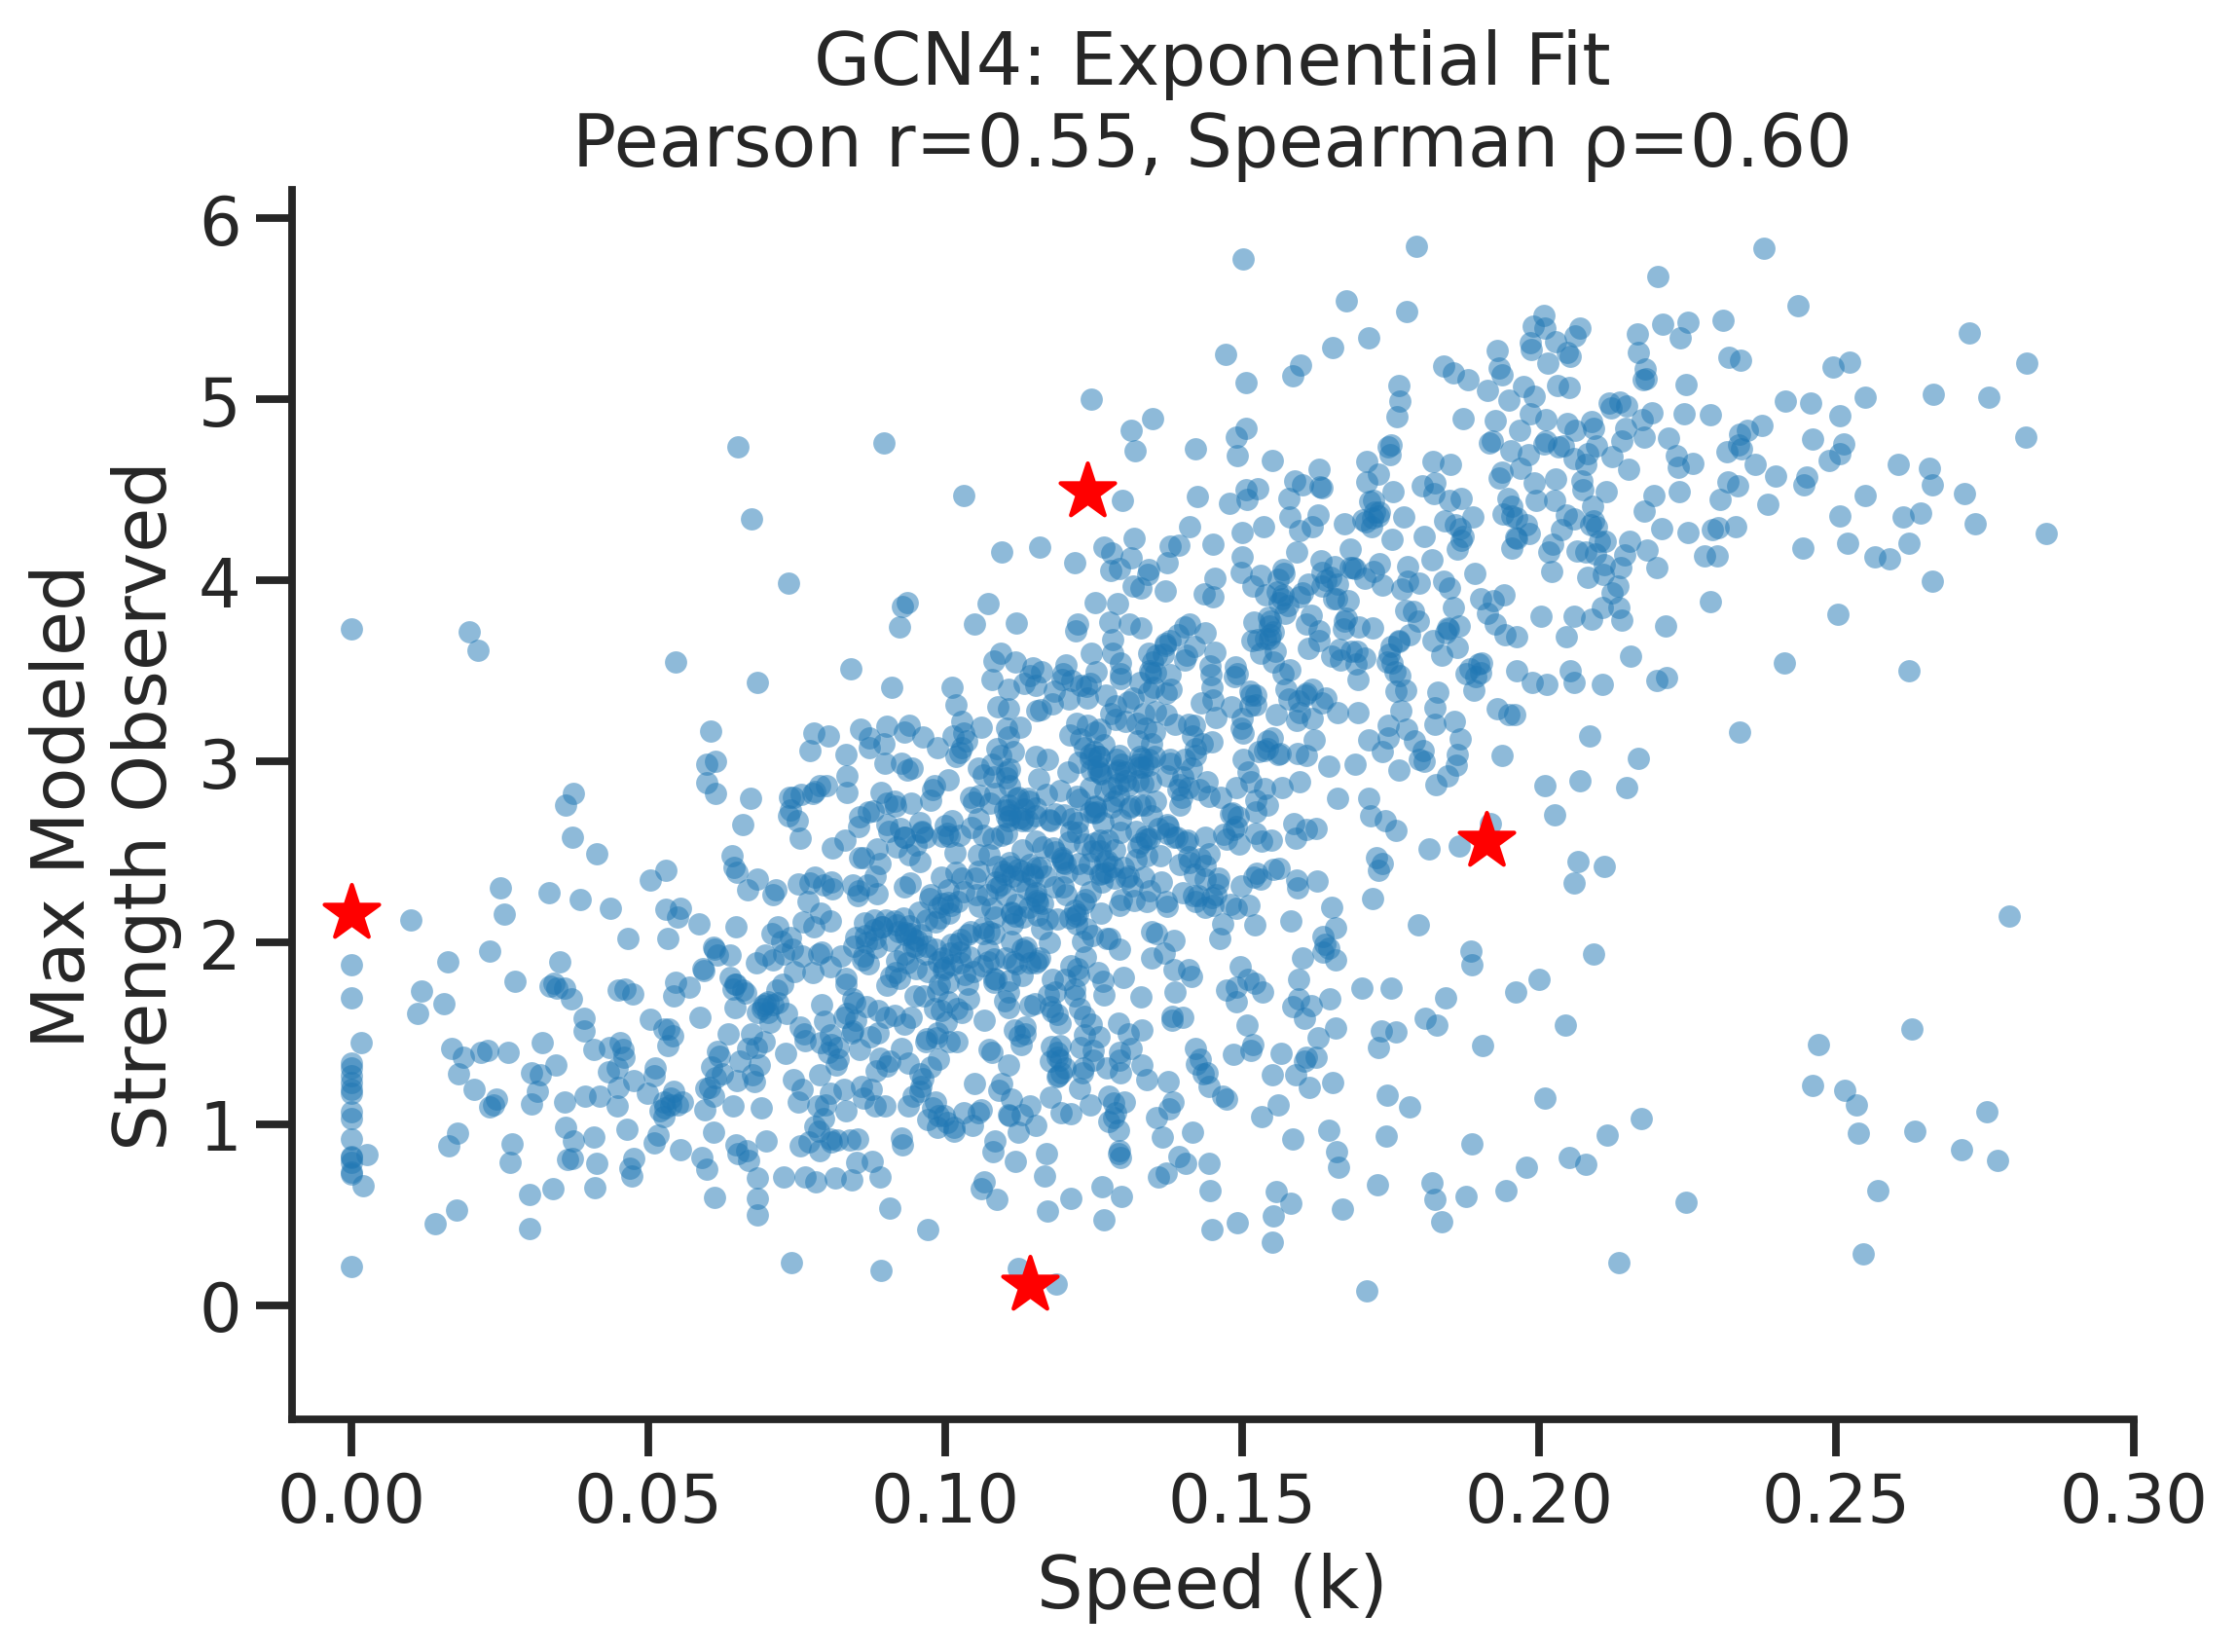

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['k'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['k'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['k'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['k'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)
ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

ax.set_xlim(-0.01, 0.3)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [16]:
 sns.color_palette('colorblind', n_colors=len(to_plot))

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

In [17]:
max_time = 30

<Figure size 1920x1440 with 0 Axes>

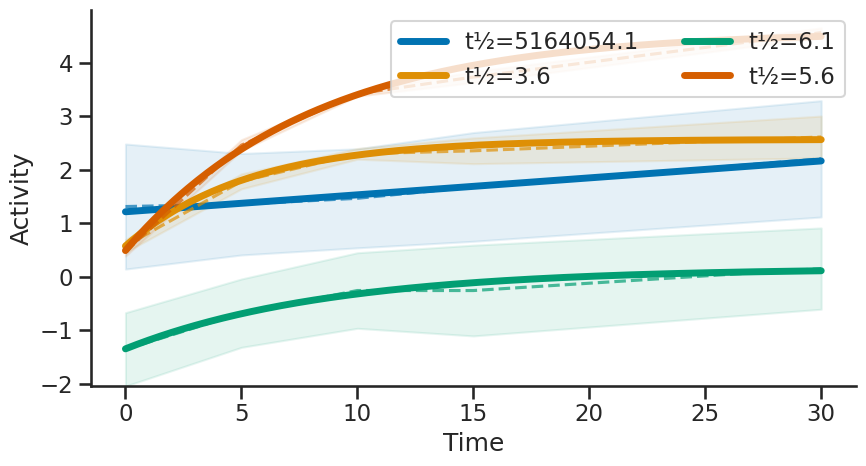

In [18]:
plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)
fig, ax = plt.subplots(figsize=(9,5))

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

for (_, row), color in zip(to_plot.iterrows(), colors):
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    ax.fill_between(t, y - sigma, y + sigma, color=color, alpha=0.1)
    ax.plot(t, y, color=color, markersize=4, alpha=0.7, linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
            color=color, linewidth=5, alpha=1,
            label=f"t½={row['t_half']:.1f}")

ax.set_xlabel('Time')
ax.set_ylabel('Activity')

# get lowest observed value across all plotted sequences
grps = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity'] - grps['error']).min()
ax.set_ylim(bottom=y_min)

# Add legend outside the plot
ax.legend(bbox_to_anchor=(1,1), loc='upper right', ncols = 2)
sns.despine()
plt.tight_layout()
plt.show()

<Figure size 1920x1440 with 0 Axes>

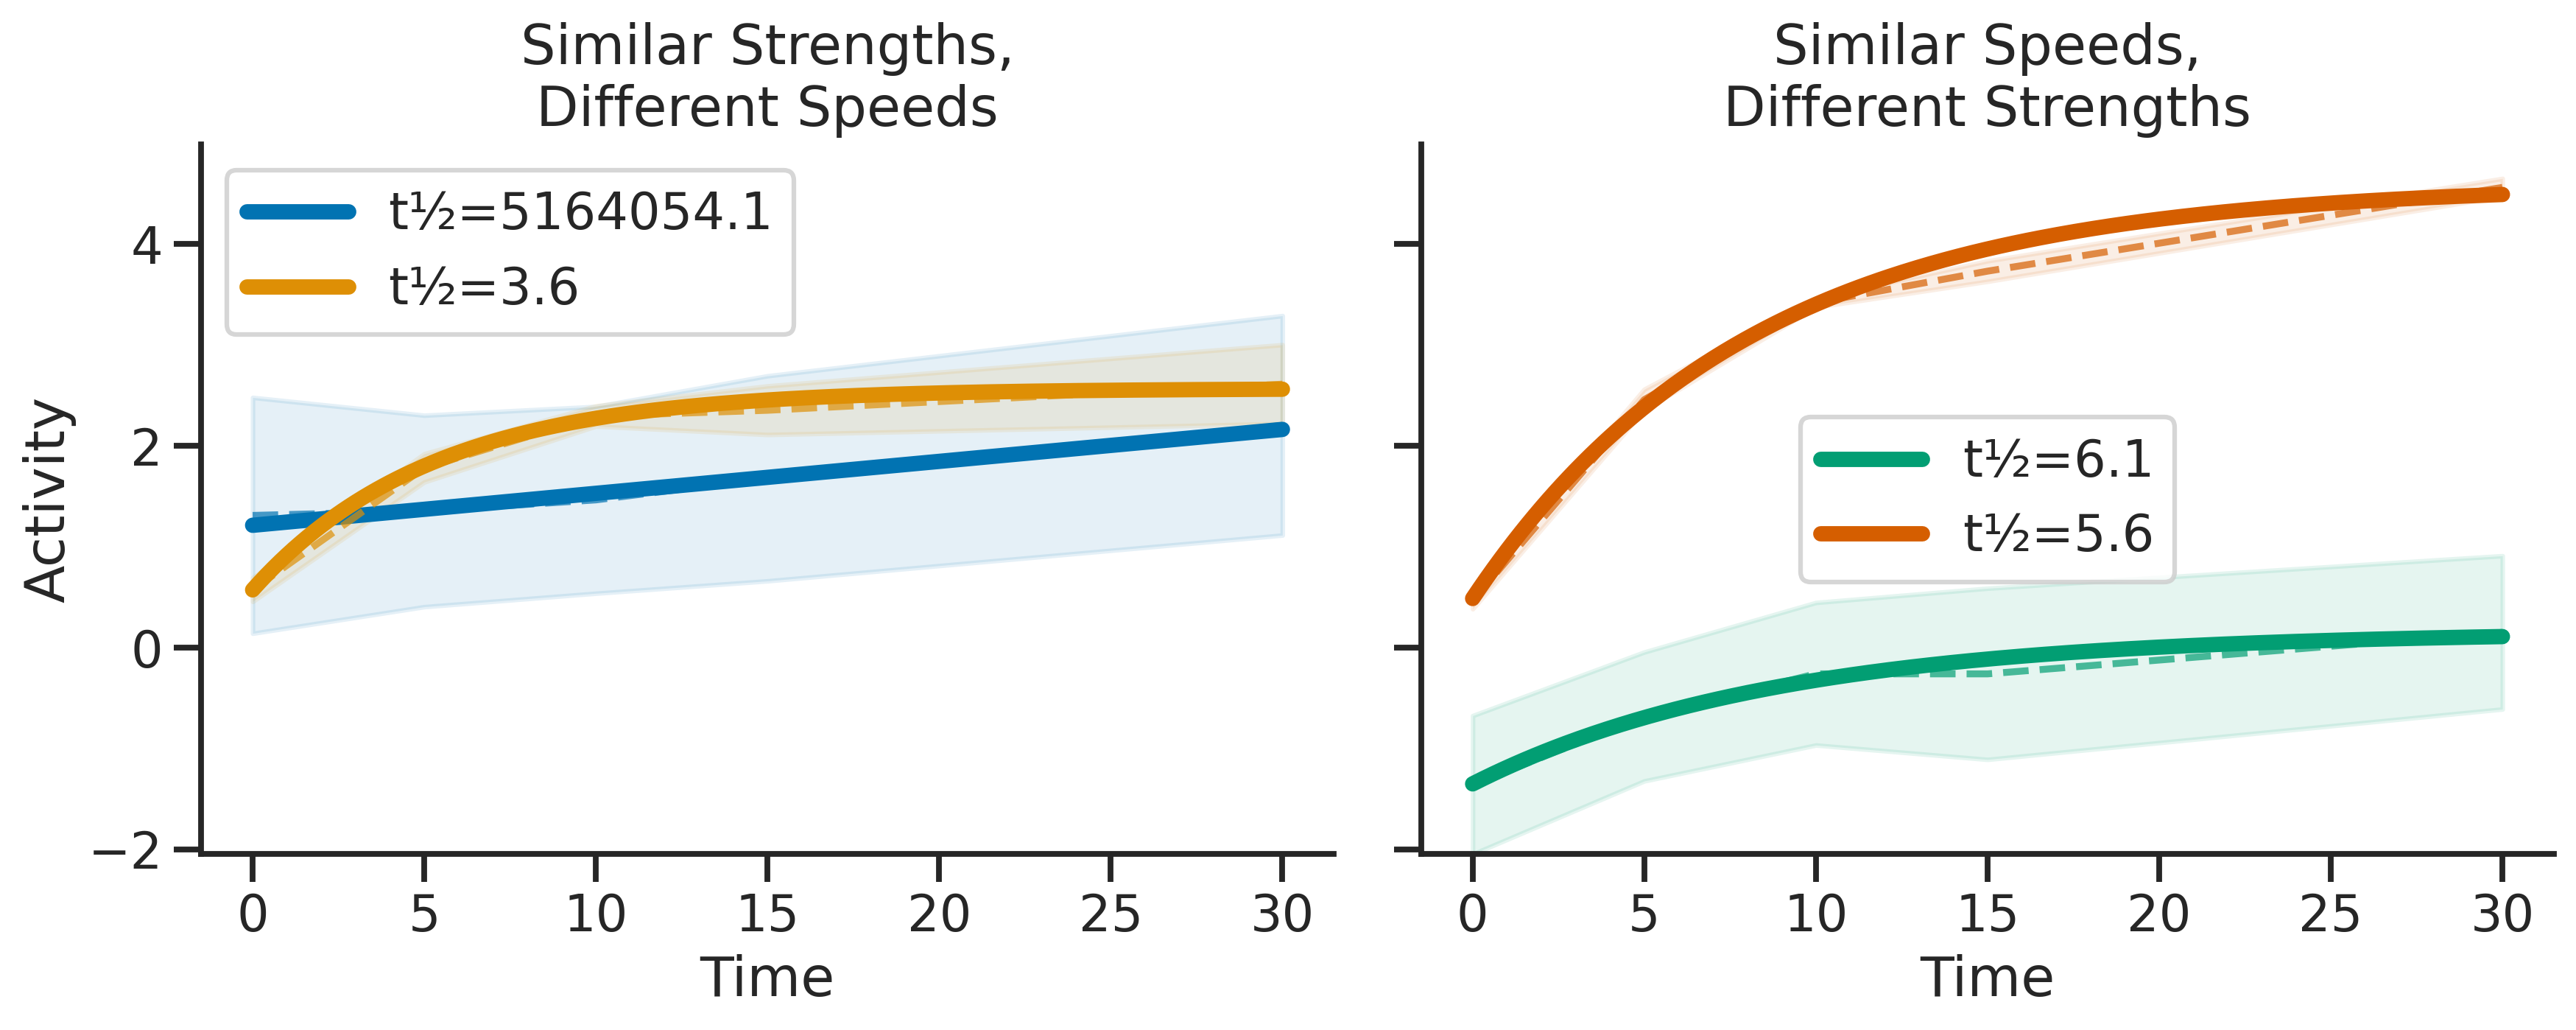

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi = 300)

# Colors for 4 sequences
colors = sns.color_palette('colorblind', n_colors=len(to_plot))

# --- first subplot: sequences 1 and 3 ---
for idx in [0, 1]:
    row = to_plot.iloc[idx]
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    axs[0].fill_between(t, y - sigma, y + sigma, color=colors[idx], alpha=0.1)
    axs[0].plot(t, y, color=colors[idx], markersize=4, alpha=0.7, linestyle='dashed')
    axs[0].plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
                color=colors[idx], linewidth=5, alpha=1,
                label=f"t½={row['t_half']:.1f}")

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].legend()
sns.despine(ax=axs[0])
axs[0].set_title("Similar Strengths,\nDifferent Speeds")

# --- second subplot: sequences 2 and 4 ---
for idx in [2, 3]:
    row = to_plot.iloc[idx]
    grp = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity'].values
    sigma = grp['error'].values

    axs[1].fill_between(t, y - sigma, y + sigma, color=colors[idx], alpha=0.1)
    axs[1].plot(t, y, color=colors[idx], markersize=4, alpha=0.7, linestyle='dashed')
    axs[1].plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
                color=colors[idx], linewidth=5, alpha=1,
                label=f"t½={row['t_half']:.1f}", zorder = 0)

axs[1].set_xlabel('Time')
axs[1].legend()
sns.despine(ax=axs[1])

# Set shared y-axis minimum
grps = active_tile_activities_count_filtered[active_tile_activities_count_filtered['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity'] - grps['error']).min()
for ax in axs:
    ax.set_ylim(bottom=y_min)
    
axs[1].set_title("Similar Speeds,\nDifferent Strengths")

plt.tight_layout()
plt.show()

# Subtracting t = 0 from everything

In [20]:
# Make a copy to avoid modifying original
activities_norm = active_tile_activities_count_filtered.copy()

# Get the time=0 activity for each ADseq
baseline = activities_norm[activities_norm["time"] == 0][["ADseq", "activity"]].set_index("ADseq")

# Subtract baseline from all time points
activities_norm = activities_norm.join(baseline, on="ADseq", rsuffix="_0")
activities_norm["activity_norm"] = activities_norm["activity"] - activities_norm["activity_0"]

# Optional: remove negative values if your exponential fit cannot handle them
activities_norm["activity_norm"] = activities_norm["activity_norm"].clip(lower=0)

# Now activities_norm["activity_norm"] is ready for exponential fitting
activities_norm = activities_norm.drop(columns = "activity_0")
activities_norm

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


In [21]:
last_activity = (
    activities_norm.sort_values("time")
      .groupby("ADseq", as_index=False)
      .tail(1)[["ADseq", "activity"]]
)
min(last_activity["activity"])

-0.2047512

In [22]:
fit_results_norm = fit_rising_exponentials(
    activities_norm,
    time_col="time",
    activity_col="activity_norm",
    error_col="error",
    min_points=5,
    subtract_baseline=False,
    verbose=True
)

fit_results_norm

Fitting: 100%|██████████| 1709/1709 [00:14<00:00, 114.96it/s]


,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,5.536385e-01,7.462020e-02,6.293211e-02,-0.002075,0.059638,9.289001e+00,7.834024e+00,1.235476,7.935872,0.960851,ok,NaN
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,8.574766e-02,1.466103e-01,1.699489e-02,0.001900,0.040876,4.727820e+00,5.480432e-01,2.170885,4.629259,0.985961,ok,NaN
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,1.236937e-01,1.594599e-01,1.938072e-02,0.017690,0.118027,4.346844e+00,5.283144e-01,1.993799,4.268537,0.995732,ok,NaN
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,1.864414e-01,1.555655e-01,2.408857e-02,0.008151,0.154746,4.455660e+00,6.899374e-01,2.505392,4.388778,0.998874,ok,NaN
4,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT,55319.313021,5.588672e-12,5.305621e-07,4.186111e-07,-0.004697,0.294459,1.306439e+06,1.030775e+06,0.875806,15.090180,0.985431,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,1.915160,2.745834e-01,5.927488e-02,2.057200e-02,-0.109011,0.140851,1.169378e+01,4.058454e+00,1.482613,9.919840,0.966389,ok,NaN
1705,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF,3.061638,3.294104e+00,1.848250e-02,2.627234e-02,-0.198979,0.119217,3.750289e+01,5.330927e+01,1.104135,15.210421,0.923934,ok,NaN
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,4.156516,2.513513e-01,1.855459e-01,2.800798e-02,0.055606,0.206244,3.735719e+00,5.639035e-01,4.196226,3.667335,0.986325,ok,NaN
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,2.711766,1.296278e-01,1.607654e-01,1.578710e-02,-0.004522,0.101114,4.311544e+00,4.233918e-01,2.685433,4.268537,0.984259,ok,NaN


In [23]:
ok_norm = fit_results_norm[
    (fit_results_norm['flag'] == 'ok') &
    (fit_results_norm['r_squared'] > 0.7) 
].copy()

print(f"Keeping {len(ok_norm)} / {len(fit_results_norm)} sequences ({100*len(ok_norm)/len(fit_results_norm):.1f}%)")

Keeping 1689 / 1709 sequences (98.8%)


In [24]:
ok_norm.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/exponential_fit_baseline_norm.csv")

In [25]:
not_ok_norm = fit_results_norm[~fit_results_norm["ADseq"].isin(ok_norm["ADseq"])]
not_ok_norm

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
113,AVINHFRGRRLWTMEEVWEKGVLDTATHIPAVFLGVLLNV,23572.883982,3.450122e-12,7.824887e-07,5.097181e-07,0.023603,0.134386,885823.938246,5.770314e+05,0.576962,14.368737,0.533699,ok,NaN
238,DSFMSAPNSAALTSLTSPSDFNDSPYGDSYDVSPNFGGND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,too_few_points,NaN
251,DSTIAPYSRHHSVFGKFAAHEAARESFWGTTGAGAPLTPL,11460.751973,1.611129e-11,1.359130e-06,1.126951e-06,0.251373,0.162247,509993.255784,4.228715e+05,0.718663,6.913828,0.396072,ok,NaN
327,ERGVVAPNQNQLQGARTRIAKSTPHWNRQTDYAHAHLRNH,0.731619,3.299838e-01,1.360325e-01,1.527542e-01,0.078415,0.307856,5.095452,5.721805e+00,0.797675,4.208417,0.531317,ok,NaN
359,FCIAPRRSSSSLNTILPFDSSSFTTDNHQQSWLPSPPPQQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,too_few_points,NaN
459,FTNRLSSPAQNPQFYASSAPSSTVALNQQNRLARPPVPLF,1.096946,7.127941e-02,1.350549e-01,3.165440e-02,0.013328,0.051492,5.132338,1.202926e+00,1.091194,4.929860,0.645054,ok,NaN
463,FVSGTVSPKDLHVDTAPPSTTFTDLSTPSFESSGYFSHDT,2.333363,2.243527e-01,1.725583e-01,2.184241e-02,0.200187,0.227810,4.016886,5.084569e-01,2.520375,3.486974,0.239365,ok,NaN
535,GSGTPQRKGSVASTGQPDNIRHYHHVPTLRNLANERSTVL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,too_few_points,NaN
599,HTPMFDELDLIMDGCKVNSSDDWVALFGDDHDIVGEEPIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,too_few_points,NaN
810,LTNLTSPSIYNESPDFTDTFEVSPNFEHGDFGNSSGDPWF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,too_few_points,NaN


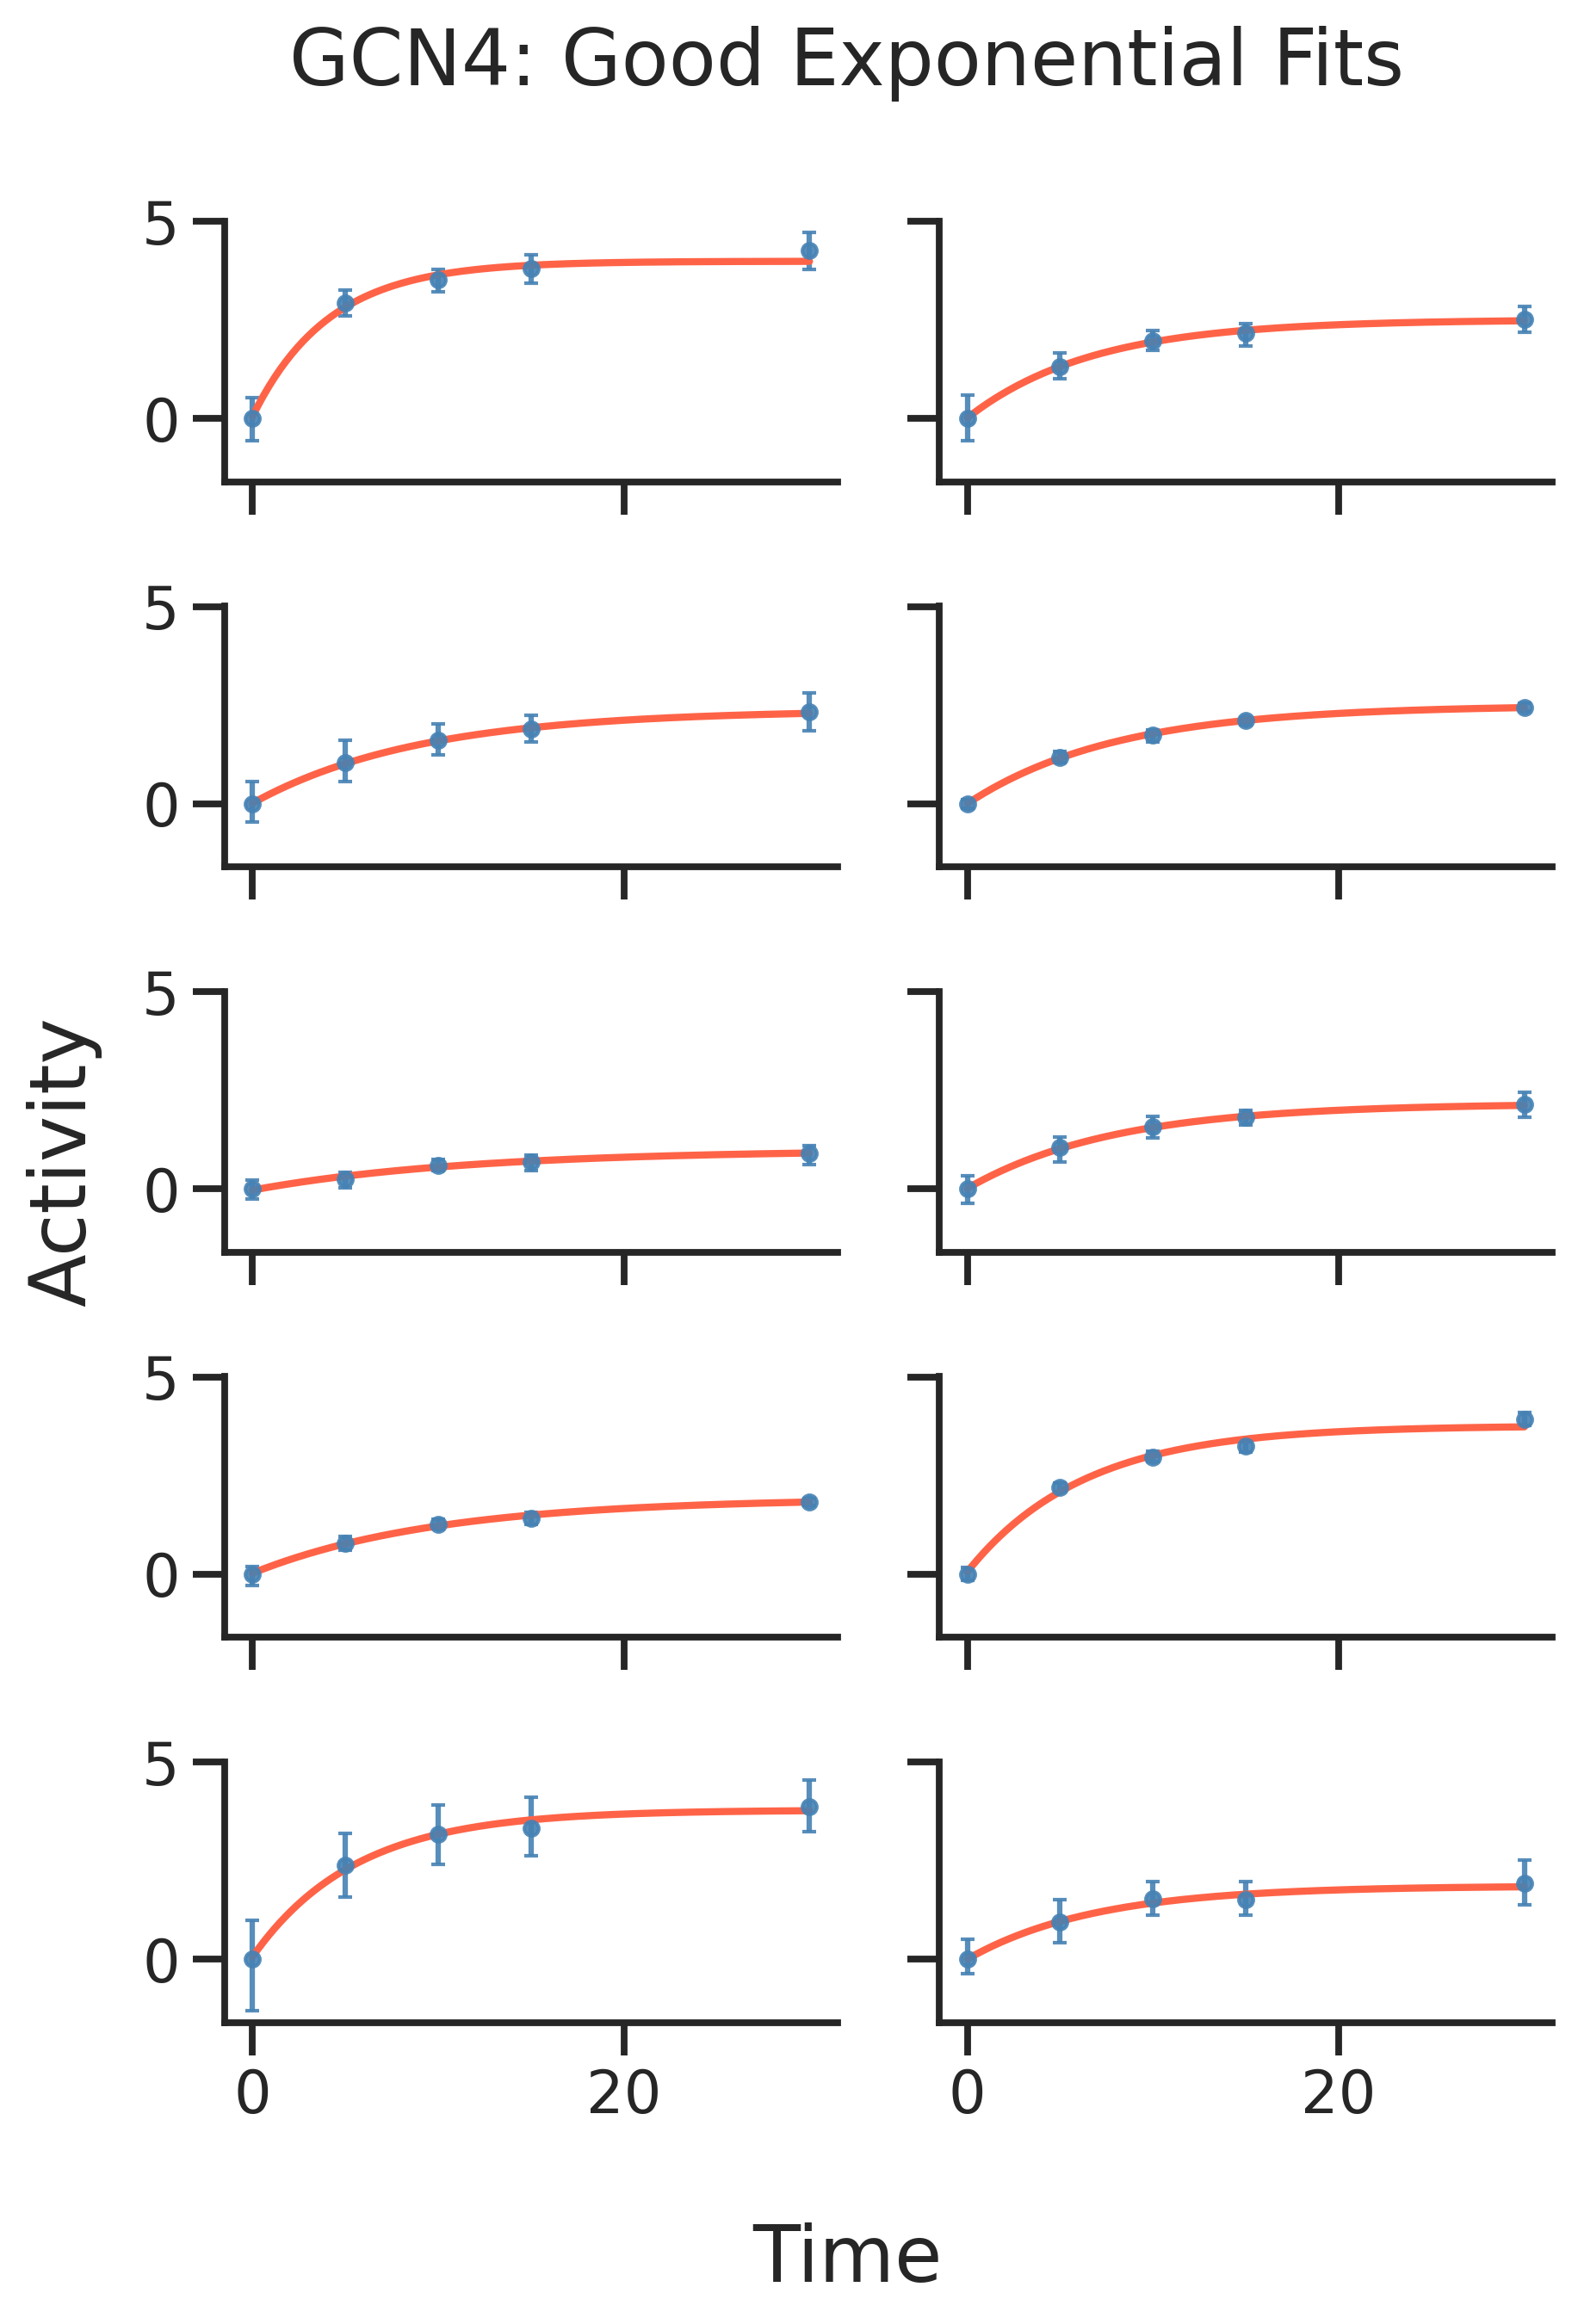

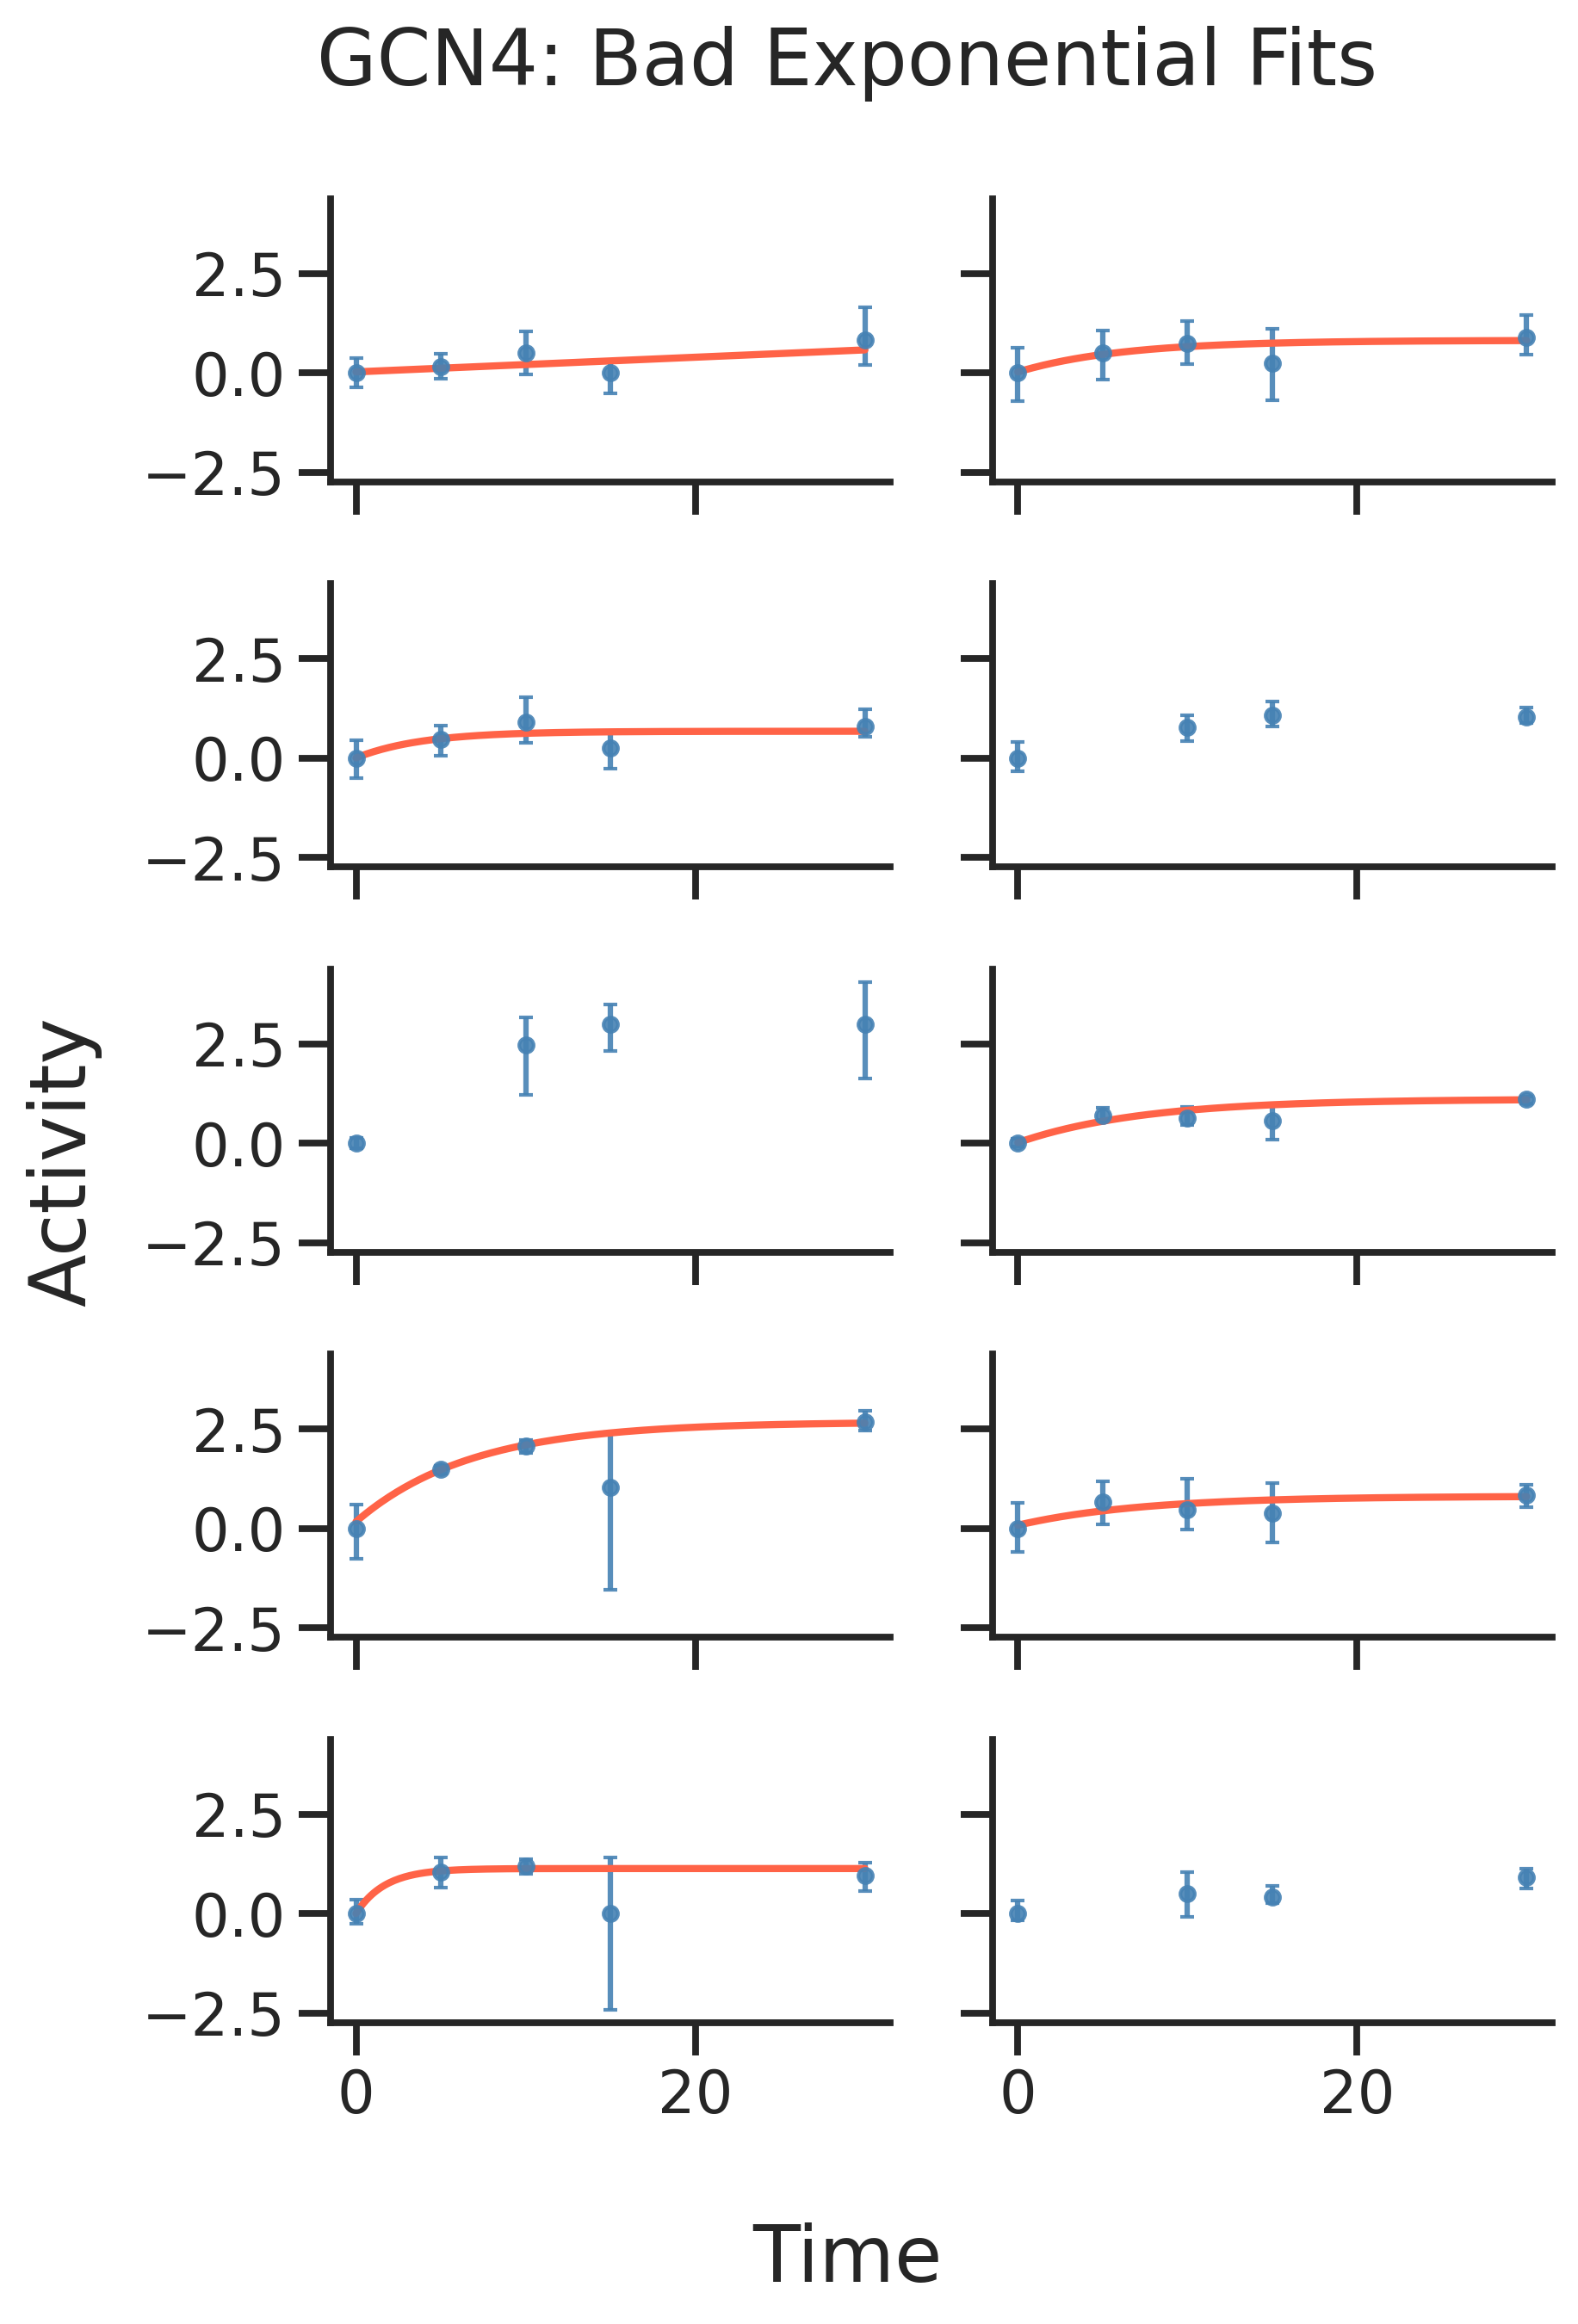

In [26]:
for df, title in zip([ok_norm, not_ok_norm], ["Good", "Bad"]):
    sample_adseqs = df.sample(16, random_state=42)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities_norm,
        fit_results=fit_results_norm,
        sample_adseqs=sample_adseqs,
        model_fn=rising_exponential,
        model_params=['A', 'k', 'C'],
        y_col='activity_norm',
        ci_low_col="ci_low_norm",
        ci_hi_col="ci_hi_norm",
        title=f'GCN4: {title} Exponential Fits'
    )

Pearson r = 0.599, p = 7.13e-165
Spearman rho = 0.652, p = 4.79e-205


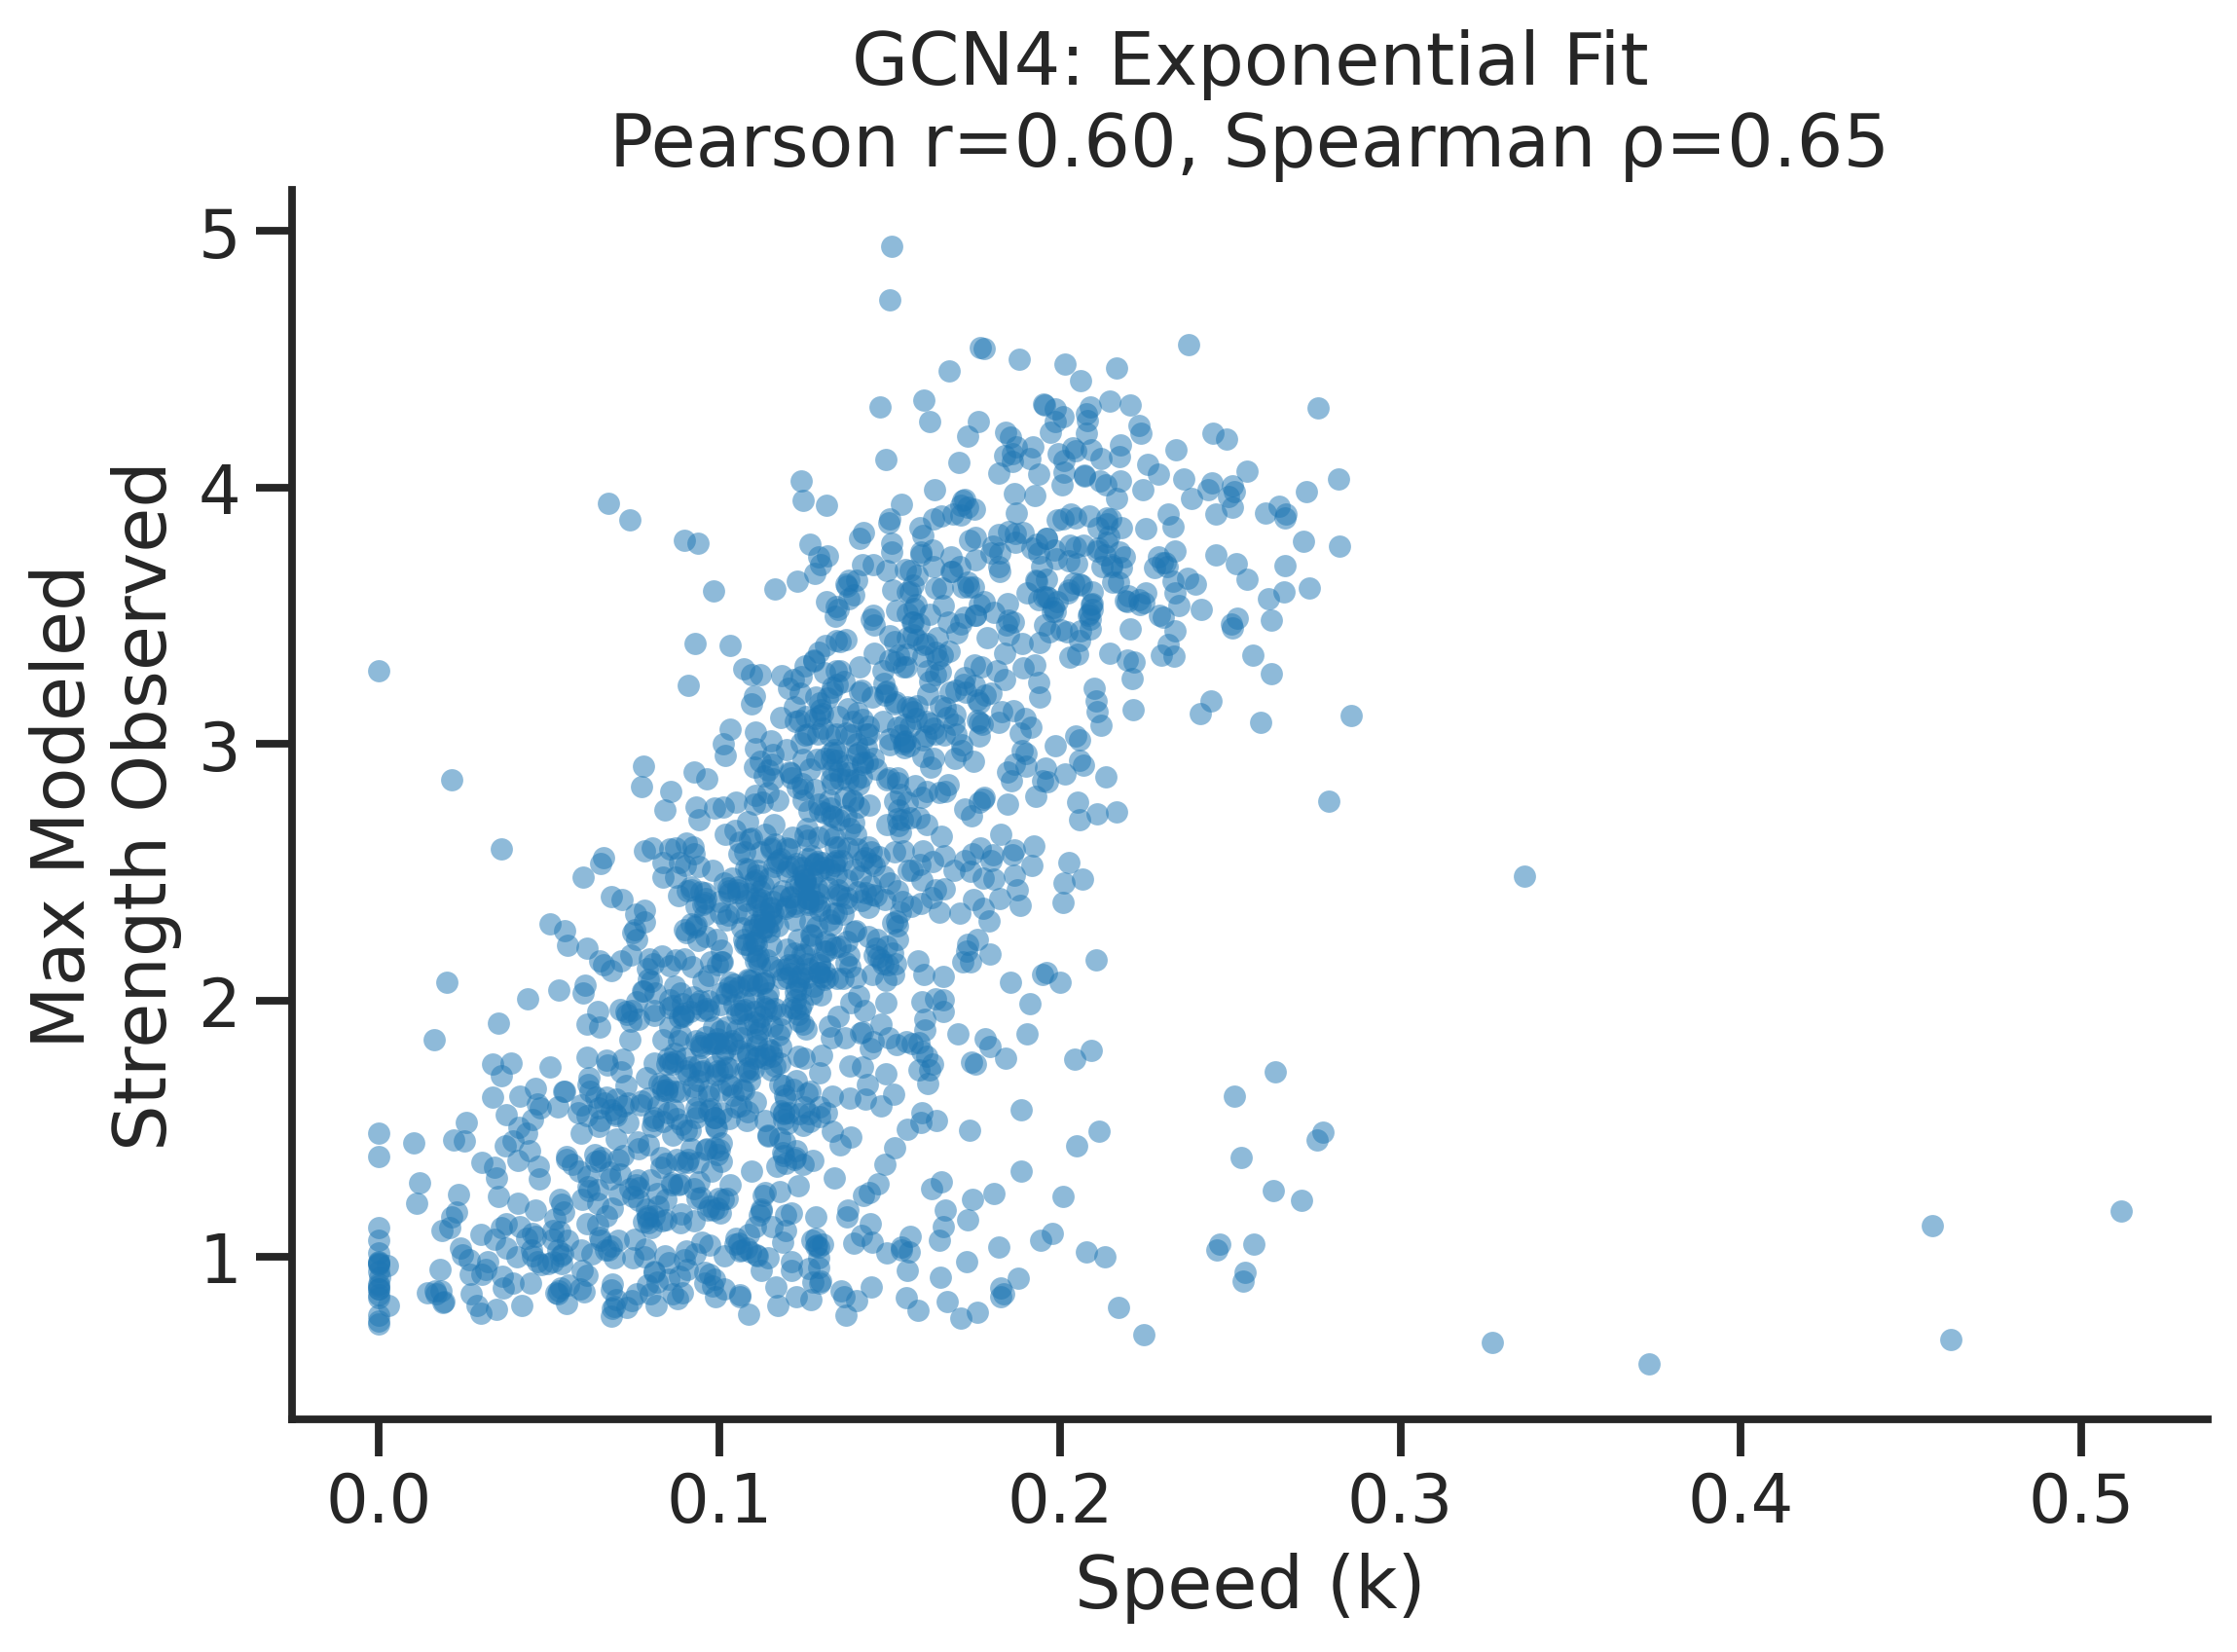

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok_norm['k'], ok_norm['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok_norm['k'], ok_norm['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(-0.01, 0.2)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [28]:
import numpy as np
import pandas as pd

# --- filter the valid range first ---
filtered = ok_norm[
    (ok_norm['k'] >= 0) & (ok['k'] <= 0.2) &
    (ok_norm['obs_max'] >= 0) & (ok_norm['obs_max'] <= 5)
].copy()

# --- 1. Similar A, different k ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.2  # ±0.3 SD around median

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) & (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('k')

# Pick two sequences with widely separated k
seq_simA_diffk = similar_A_sorted.iloc[[1, -2]]  # first and last k

# --- 2. Similar k, different A ---
k_target = filtered['k'].median()
k_tol = filtered['k'].std() * 0.2  # ±0.3 SD around median

similar_k = filtered[(filtered['k'] >= k_target - k_tol) & (filtered['k'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

# Pick two sequences with widely separated A
seq_simk_diffA = similar_k_sorted.iloc[[1, -2]]  # lowest and highest A

# --- Combine for inspection ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA])
to_plot

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax
1590,TYDLSSSVPSSVSNMGTVSPQELLLHEPYLSAPSSTALTA,2.790621,0.787266,0.043675,0.022447,-0.031720,0.124274,15.870508,8.156546,2.006128,10.581162,0.989878,ok,NaN
1406,STDSTPMFEYENLEDNMKEWTSLFDNDISVNTDDLSLADK,2.064320,0.099052,0.194858,0.018022,0.044240,0.086416,3.557193,0.328992,2.102589,3.426854,0.972037,ok,NaN
1104,PWYPLFPSDTASHELVNPSESPAQKPLKSEPMYRSSSSGS,0.876274,0.292304,0.126720,0.101489,-0.025033,0.223860,5.469894,4.380777,0.831669,5.531062,0.917238,ok,NaN
287,EFDSYEFSPNFGDLDATSTENWFPLFPESTATDQPTASVK,3.990954,0.678866,0.124499,0.045770,0.054493,0.584650,5.567514,2.046810,3.950166,5.290581,0.999314,ok,NaN


In [29]:
#to_plot.to_csv("../../../output/GCN4_speed_strength_diff_examples_for_CC.csv")

Pearson r = 0.599, p = 7.13e-165
Spearman rho = 0.652, p = 4.79e-205


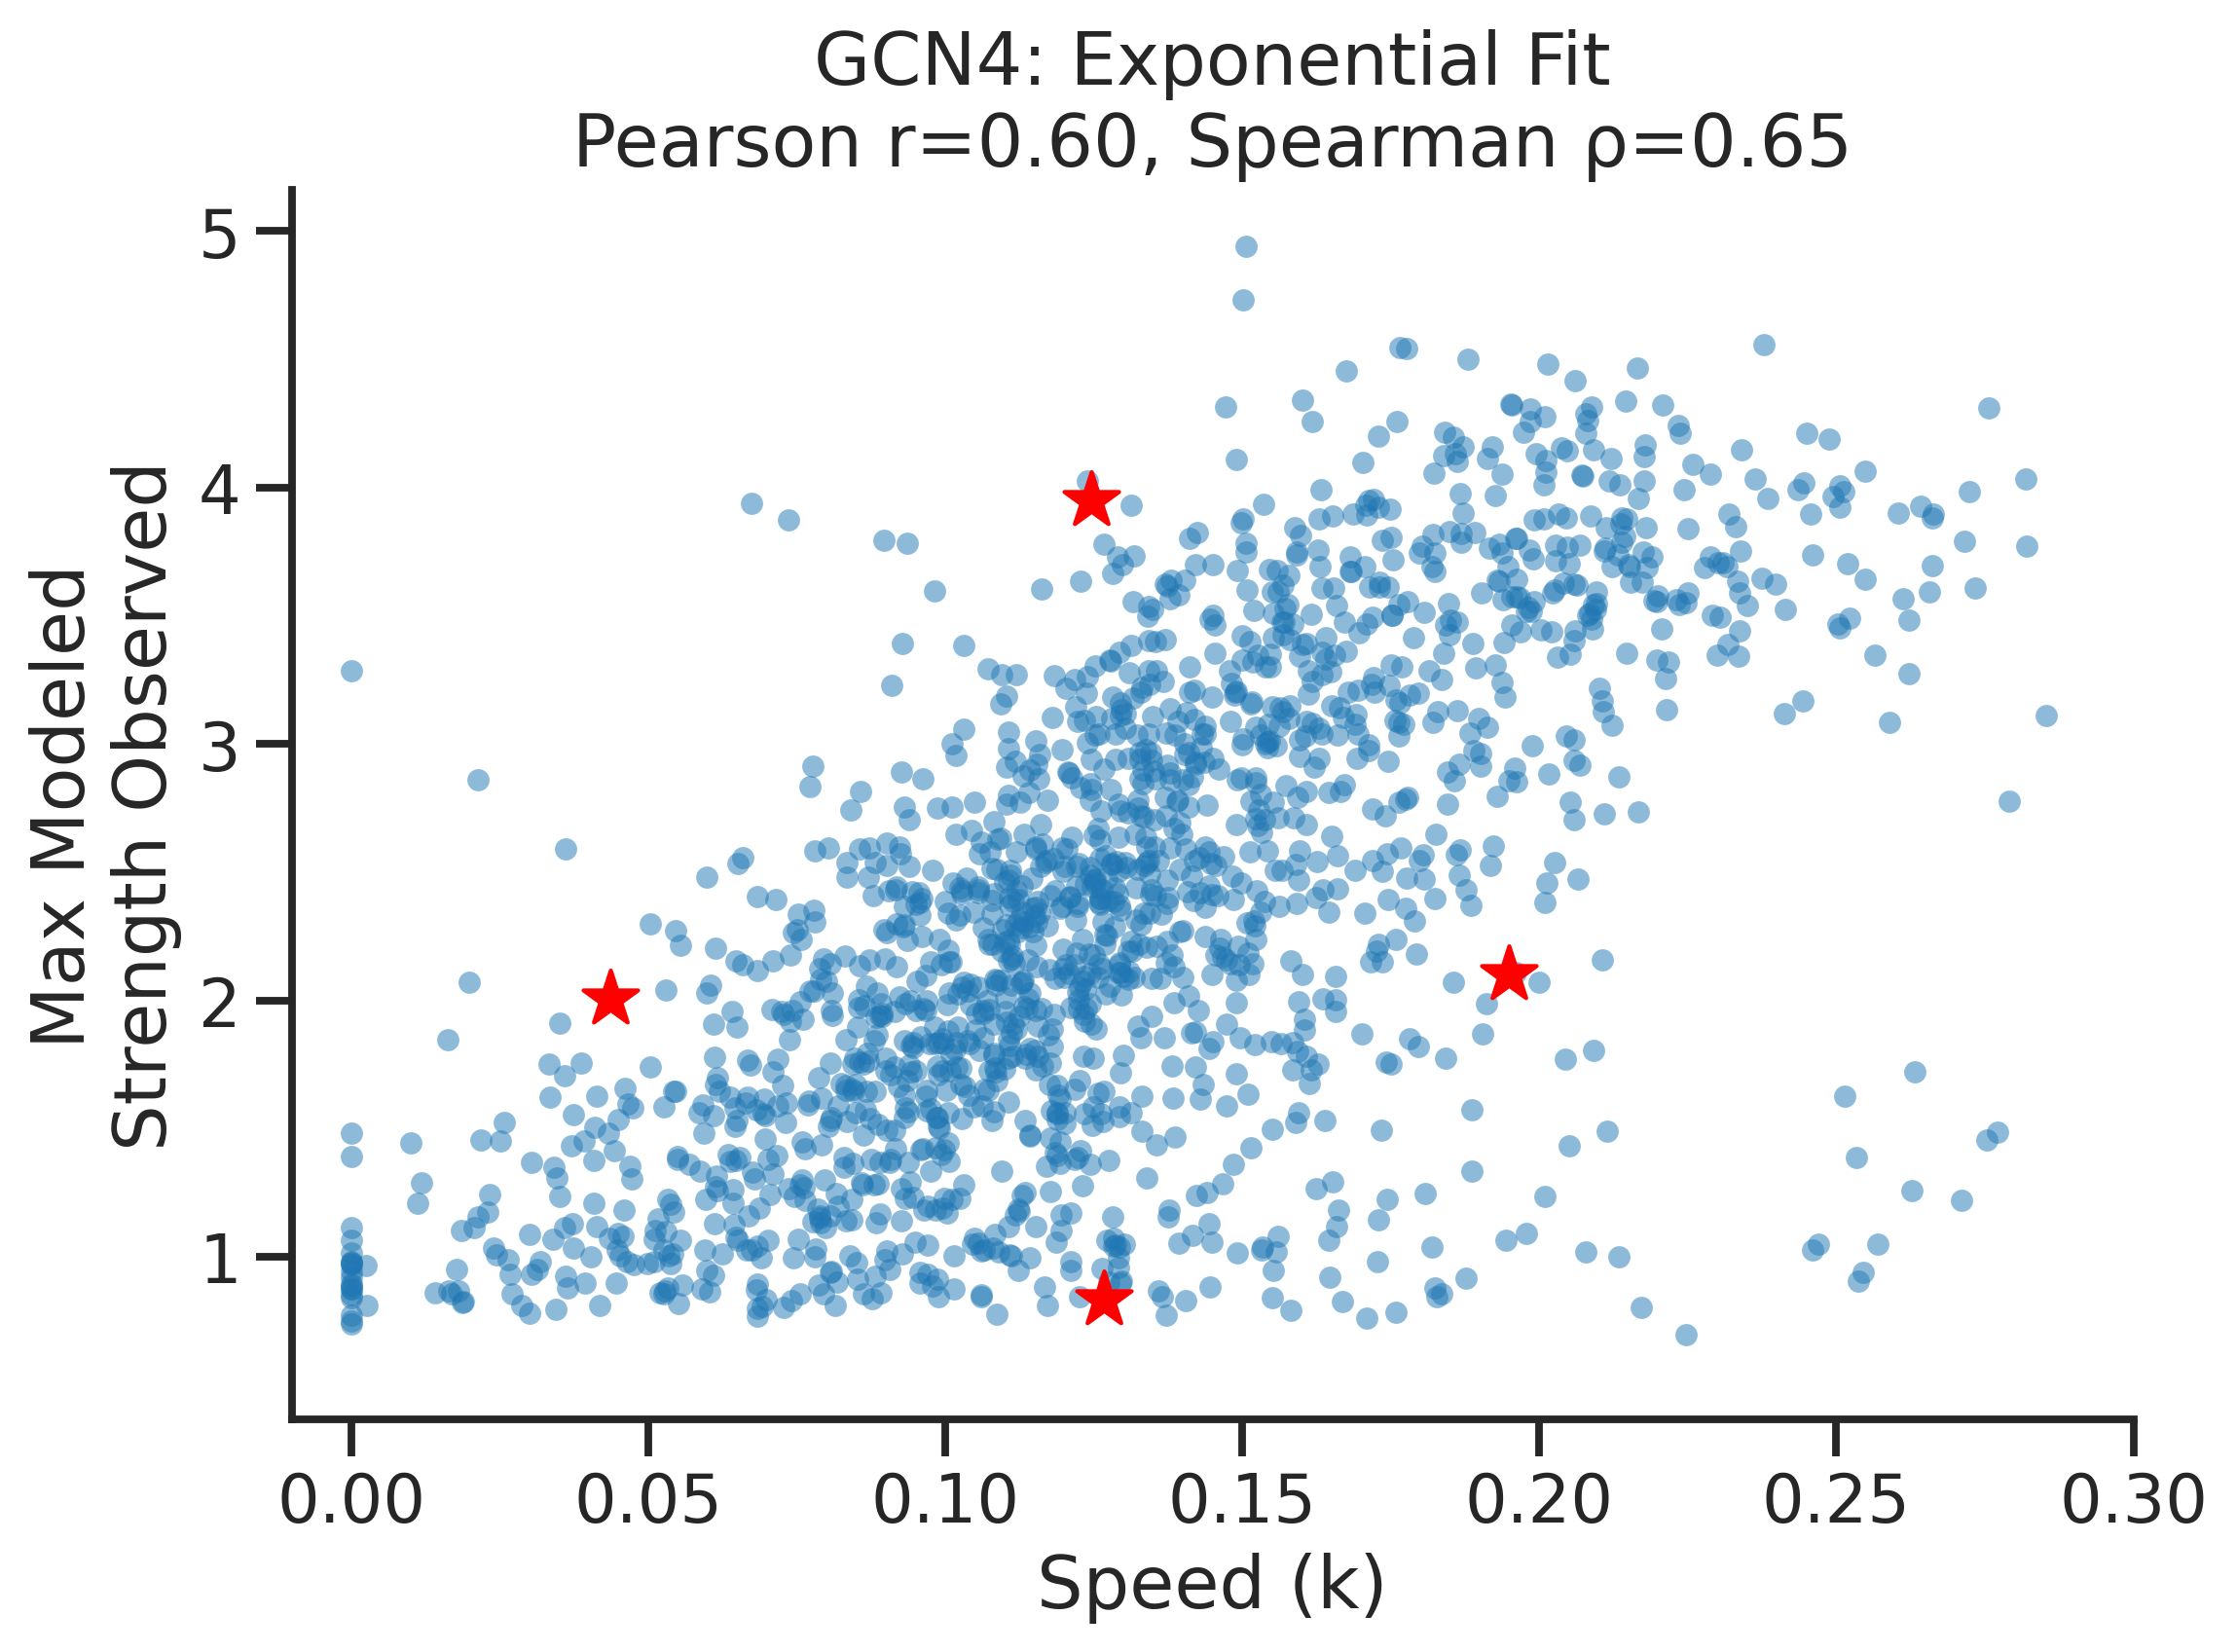

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok_norm['k'], ok_norm ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok_norm['k'], ok_norm['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['k'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)
ax.set_xlabel('Speed (k)')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Exponential Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

ax.set_xlim(-0.01, 0.3)
# ax.set_ylim(0,5)

plt.tight_layout()
sns.despine()
plt.show()

In [31]:
 sns.color_palette('colorblind', n_colors=len(to_plot))

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

<Figure size 1920x1440 with 0 Axes>

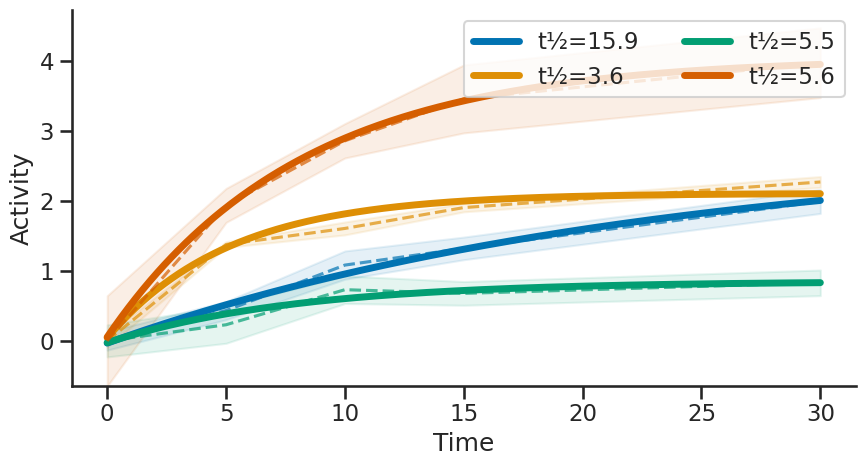

In [32]:
plt.figure(dpi=300)

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)
fig, ax = plt.subplots(figsize=(9,5))

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

for (_, row), color in zip(to_plot.iterrows(), colors):
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    ax.fill_between(t, y - sigma, y + sigma, color=color, alpha=0.1)
    ax.plot(t, y, color=color, markersize=4, alpha=0.7, linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, row['A'], row['k'], row['C']),
            color=color, linewidth=5, alpha=1,
            label=f"t½={row['t_half']:.1f}")

ax.set_xlabel('Time')
ax.set_ylabel('Activity')

# get lowest observed value across all plotted sequences
grps = activities_norm[activities_norm['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()
ax.set_ylim(bottom=y_min)

# Add legend outside the plot
ax.legend(bbox_to_anchor=(1,1), loc='upper right', ncols = 2)
sns.despine()
plt.tight_layout()
plt.show()

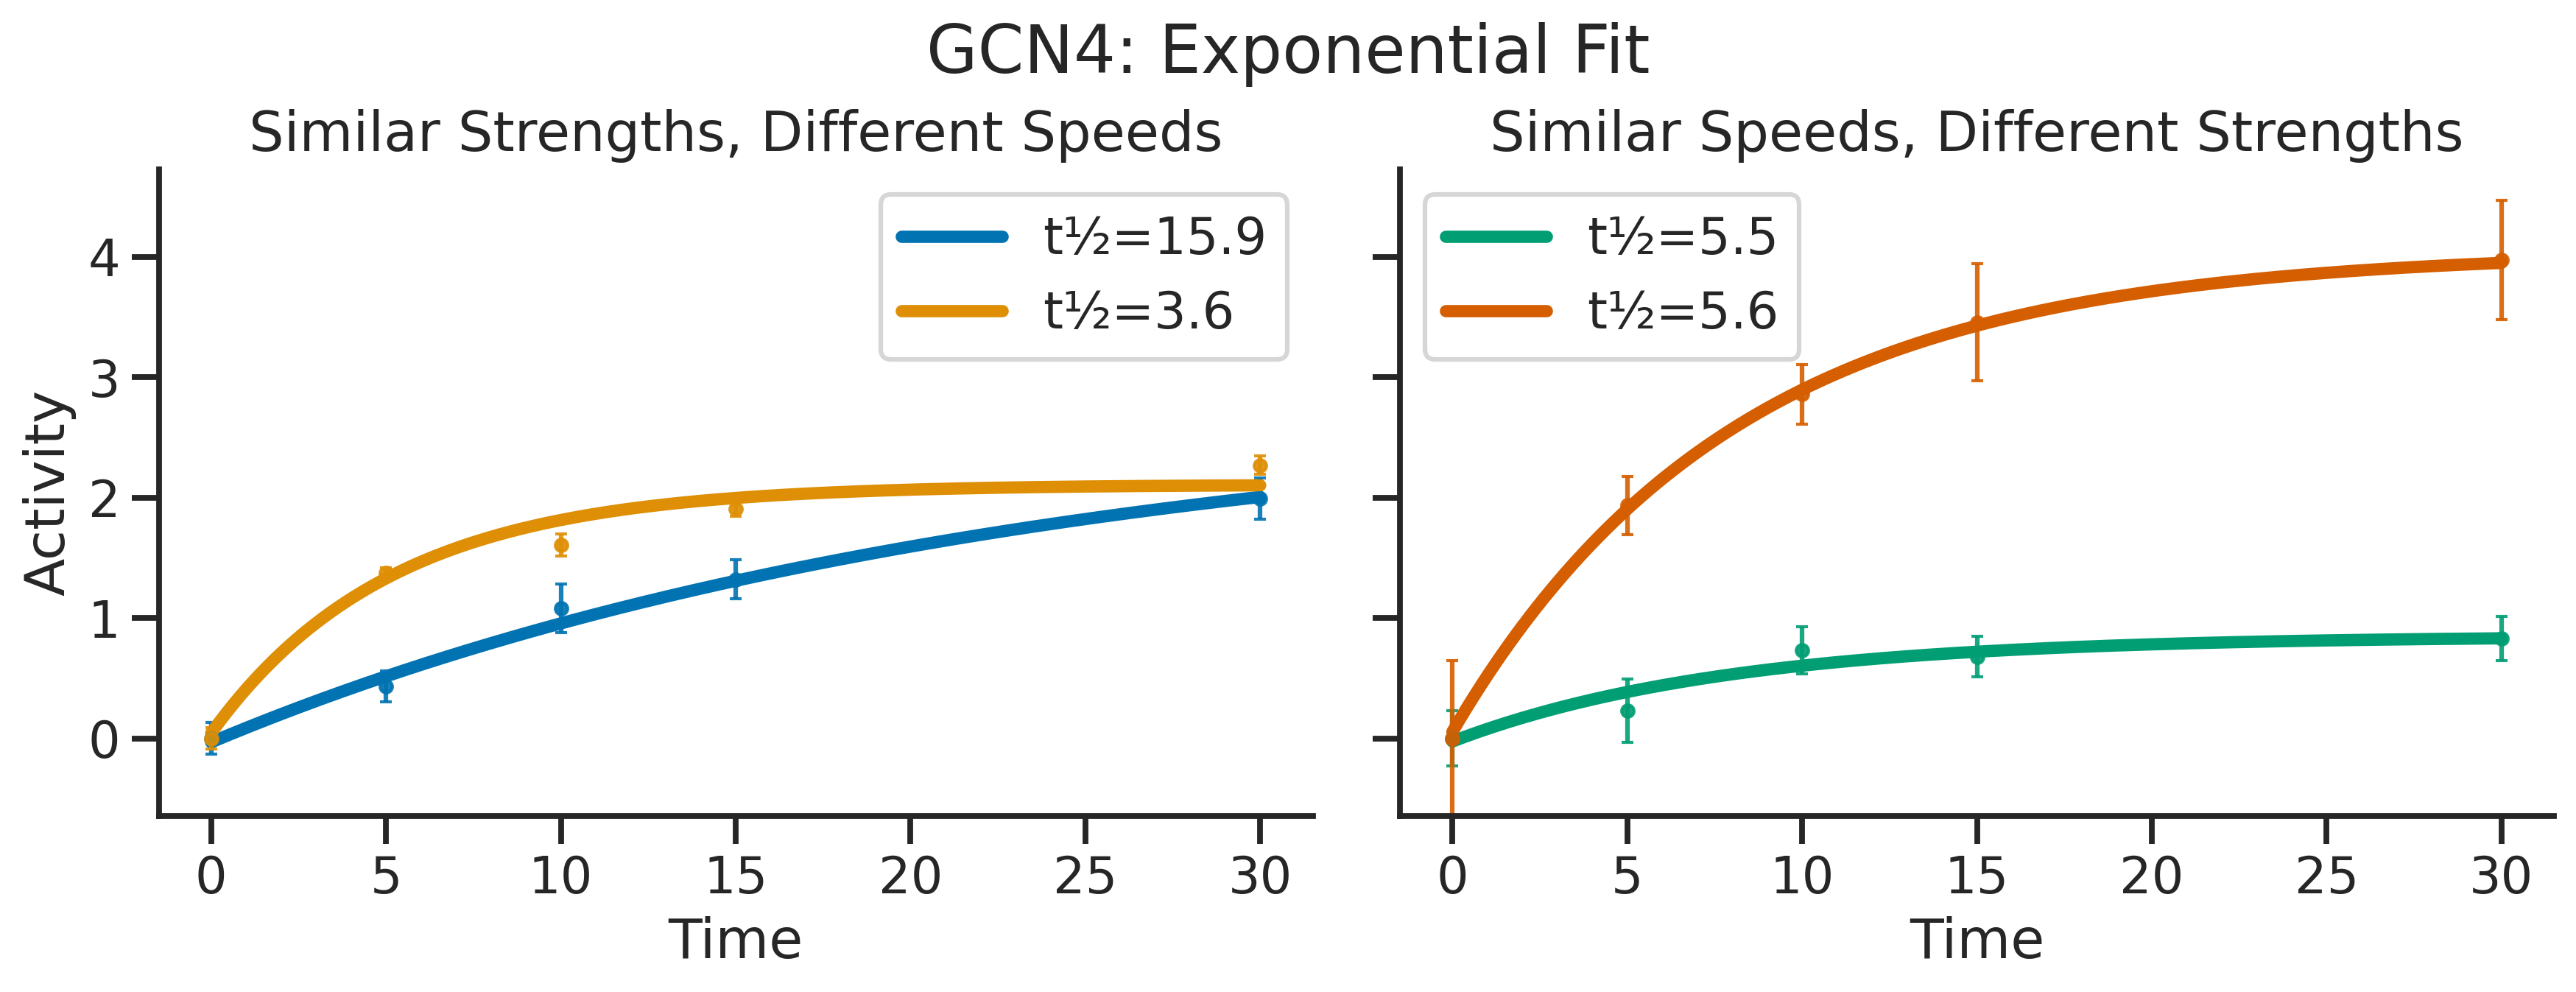

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

t_fine = np.linspace(0, max_time, 300)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

colors = sns.color_palette('colorblind', n_colors=len(to_plot))

# --- first subplot: sequences 1 and 3 ---
for idx in [0, 1]:

    row = to_plot.iloc[idx]
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[0].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=4,
        alpha=0.9
    )

    axs[0].plot(
        t_fine,
        rising_exponential(t_fine, row['A'], row['k'], row['C']),
        color=colors[idx],
        linewidth=4,
        alpha=1,
        label=f"t½={row['t_half']:.1f}"
    )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].legend()
sns.despine(ax=axs[0])
axs[0].set_title("Similar Strengths, Different Speeds")

# --- second subplot: sequences 2 and 4 ---
for idx in [2, 3]:

    row = to_plot.iloc[idx]
    grp = activities_norm[activities_norm['ADseq'] == row['ADseq']].sort_values('time')

    t = grp['time'].values
    y = grp['activity_norm'].values
    sigma = grp['error'].values

    axs[1].errorbar(
        t, y, yerr=sigma,
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=4,
        alpha=0.9
    )

    axs[1].plot(
        t_fine,
        rising_exponential(t_fine, row['A'], row['k'], row['C']),
        color=colors[idx],
        linewidth=4,
        alpha=1,
        label=f"t½={row['t_half']:.1f}"
    )

axs[1].set_xlabel('Time')
axs[1].legend()
sns.despine(ax=axs[1])

# --- shared y-axis scaling ---
grps = activities_norm[activities_norm['ADseq'].isin(to_plot['ADseq'])]
y_min = (grps['activity_norm'] - grps['error']).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

axs[1].set_title("Similar Speeds, Different Strengths")

plt.suptitle("GCN4: Exponential Fit", y=0.912)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2597873/622480145.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


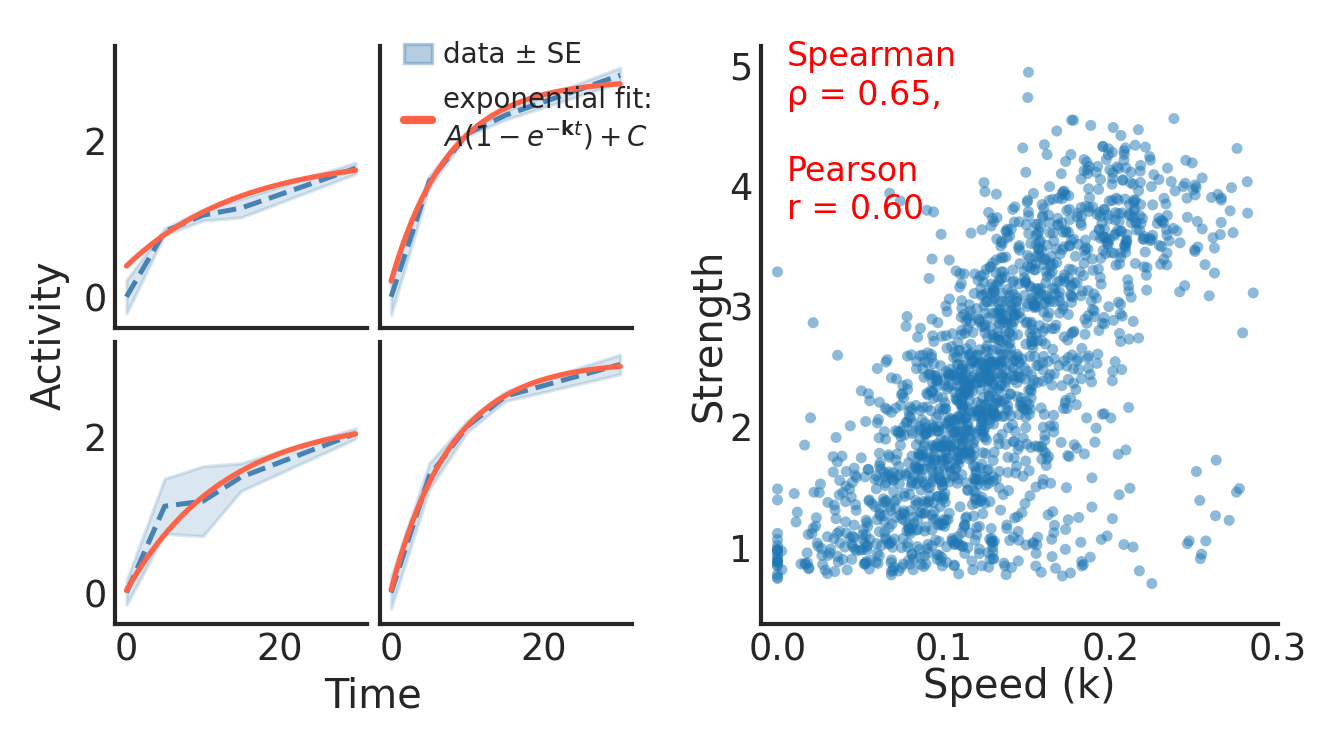

In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr

sns.set_context('paper')
sns.set_style('white')

def rising_exponential(t, A, k, C):
    return A * (1 - np.exp(-k * t)) + C

sample_adseqs = ok_norm.sample(4, random_state=92)['ADseq'].values
t_fine = np.linspace(0, activities_norm['time'].max(), 200)

pearson_corr, pearson_p   = pearsonr(ok_norm['k'], ok_norm['obs_max'])
spearman_corr, spearman_p = spearmanr(ok_norm['k'], ok_norm['obs_max'])

fig = plt.figure(figsize=(5,2.5), dpi=300)
outer_gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25, figure=fig)

inner_gs = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=outer_gs[0], wspace=0.05, hspace=0.05
)

axes_left = []
ax0 = fig.add_subplot(inner_gs[0, 0])
axes_left.append(ax0)
for r in range(2):
    for c in range(2):
        if r == 0 and c == 0:
            continue
        ax = fig.add_subplot(inner_gs[r, c], sharex=ax0, sharey=ax0)
        axes_left.append(ax)

for ax, adseq in zip(axes_left, sample_adseqs):
    grp = activities_norm[activities_norm['ADseq'] == adseq].sort_values('time')
    t     = grp['time'].values
    y     = grp['activity_norm'].values
    sigma = grp['error'].values
    row_fit = fit_results_norm[fit_results_norm['ADseq'] == adseq].iloc[0]
    A, k, C = row_fit['A'], row_fit['k'], row_fit['C']

    ax.fill_between(t, y - sigma, y + sigma, color='steelblue', alpha=0.2)
    ax.plot(t, y, color='steelblue', linestyle='dashed')
    ax.plot(t_fine, rising_exponential(t_fine, A, k, C), color='tomato', linewidth=1.25)
    
# hide inner tick labels
for ax in [axes_left[0], axes_left[1]]:
    ax.tick_params(labelbottom=False)
for ax in [axes_left[1], axes_left[3]]:
    ax.tick_params(labelleft=False)

# sup axis labels scoped to left block
left_bbox = outer_gs[0].get_position(fig)
fig.text(left_bbox.x0 + left_bbox.width / 2, left_bbox.y0 - 0.07,
         'Time', ha='center', va='top',
         fontsize=plt.rcParams['axes.labelsize'])
fig.text(left_bbox.x0 - 0.03, left_bbox.y0 + left_bbox.height / 2,
         'Activity', ha='right', va='center', rotation='vertical',
         fontsize=plt.rcParams['axes.labelsize'])

# legend
# data_patch = mpatches.Patch(color='steelblue', alpha=0.4, label='data ± SE')
# fit_line = mlines.Line2D([], [], color='tomato', linewidth=2,
#                           label='exponential fit:\n' + r'$A(1-e^{-\mathbf{k}t})+C$')
# axes_left[1].legend(handles=[data_patch, fit_line],
#                     loc='upper right', fontsize='small', bbox_to_anchor = (1.1,1.15), ncols = 2)

data_patch = mpatches.Patch(color='steelblue', alpha=0.4, label='data ± SE')
fit_line   = mlines.Line2D([], [], color='tomato', linewidth=2,
                            label='exponential fit:\n' + r'$A(1-e^{-\mathbf{k}t})+C$')

fig.legend(handles=[data_patch, fit_line],
           loc='upper right',
           bbox_to_anchor=(0.5,0.92),  # centered under 2x2
           fontsize='x-small',
           frameon=False,
           handlelength=1,
           columnspacing=0,
           handletextpad=0.4,
          labelspacing = 0.6)

# right scatter
ax_right = fig.add_subplot(outer_gs[1])
ax_right.scatter(ok_norm['k'], ok_norm['obs_max'], alpha=0.5, s=7, edgecolor='none')
ax_right.set_xlabel('Speed (k)', labelpad = -0.5)
ax_right.set_ylabel('Strength', labelpad = 0)

ax_right.text(0.05, 1.01,
              f'Spearman\nρ = {spearman_corr:.2f},\n\nPearson\nr = {pearson_corr:.2f}',
              transform=ax_right.transAxes, ha='left', va='top',
              fontsize='small', color = 'red')

# on one panel only (e.g. top-left), show the model equation
# axes_left[0].text(0.1,1,          # center of the panel
#     r'$\mathbf{A(1-e^{-kt})+C}$',
#     transform=axes_left[0].transAxes,
#     ha='left', va='top', fontsize='small', color='tomato')

# # on all panels, label k from the fit
# ax.text(0.05, 0.95, f'k = {k:.3f}',
#         transform=ax.transAxes, ha='left', va='top',
#         fontsize='x-small', color='tomato', fontweight='bold')

# tighten ticks on all left axes
for ax in axes_left:
    ax.tick_params(axis='x', pad=2, length=0)
    ax.tick_params(axis='y', pad=2, length=0)

# also on right
ax_right.tick_params(axis='x', pad=2, length=0)
ax_right.tick_params(axis='y', pad=2, length=0)
ax_right.set_xlim(-0.01, 0.3)
sns.despine(fig=fig)
plt.tight_layout(pad=0.1)
plt.show()